# 정신곽문조_v5 — Trotterized Quantum Simulation (Problem 1 & 2 & 3)


## Experiment hierarchy map

The full experiment flow is summarized below. The file is also saved as `figures/experiment_hierarchy_v5.svg`.

![Experiment hierarchy](figures/experiment_hierarchy_v5.svg)


## Submission artifact index

This lightweight submission copy keeps the experiment code, but heavy inline outputs that are already saved as external artifacts are represented by the files below.

- Hierarchy: [SVG](figures/experiment_hierarchy_v5.svg), [PDF](figures/experiment_hierarchy_v5.pdf), [PNG](figures/experiment_hierarchy_v5.png)
- Problem 1 resources/errors: `tables/p1_resource_summary_grouped_opt3.csv`, `tables/p1_all9_error_time_series.csv`, `tables/p1_error_resource_summary.csv`, `figures/p1_all9_state_infidelity_vs_time.png`, `figures/p1_all9_local_observable_errors.png`
- Problem 1(g) mitigation: `tables/p1g_noisy_simulator_qualification.csv`, `tables/p1g_round1_mpf_vs_postselection.csv`, `tables/p1g_mpf_exact_validity.csv`, `tables/p1g_four_stage_error_decomposition.csv`, `figures/p1g_noisy_simulator_qualification.png`, `figures/p1g_four_stage_error_decomposition.png`
- QPU-related artifacts: `tables/p1g_r2_qpu_resilience_vs_postselection.csv`, `tables/p1g_pdf_guide_qpu_plan.csv`, `tables/p1g_pdf_guide_qpu_backend_resources.csv`, `tables/p1_qpu_scalability_us_east_results.csv`, `figures/p1_qpu_scalability_us_east_z0_error.png`, `figures/p1_qpu_scalability_us_east_resource.png`
- Bonus 3: `tables/p3_bonus_standard_opt_levels.csv`, `tables/p3_bonus_rustiq_comparison.csv`


## Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from numpy.fft import fft, fftshift, fftfreq
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from qiskit.circuit.library import PauliEvolutionGate, UnitaryGate
from qiskit.synthesis import LieTrotter, SuzukiTrotter
import utils

N = 6
Jx, Jy, Jz, hx = 1.0, 0.7, 1.2, 0.4
BITSTRING_Q0_FIRST = "010101"                 # qubit-0-first (problem convention)
BITSTRING_QISKIT   = BITSTRING_Q0_FIRST[::-1]  # qubit-0-last (Qiskit label) = "101010"
assert BITSTRING_QISKIT == BITSTRING_Q0_FIRST[::-1]
DT_GRID, T_MAX = 0.05, 15.0
TIMES = np.arange(0.0, T_MAX + 0.5*DT_GRID, DT_GRID)
BASIS_GATES = ["cx", "u3", "u1"]
K_VALUES = [1, 2, 3]
INTERACTIONS = [("XX", Jx), ("YY", Jy), ("ZZ", Jz)]

def ring_bonds(n):
    allb = [(j, (j+1) % n) for j in range(n)]
    return allb, allb[0::2], allb[1::2]   # all, even, odd (each parity layer internally disjoint)

print("time points:", len(TIMES), "| psi0  q0-first |%s>  ->  qiskit |%s>" % (BITSTRING_Q0_FIRST, BITSTRING_QISKIT))

time points: 301 | psi0  q0-first |010101>  ->  qiskit |101010>


## Problem 1(a): construct the Hamiltonian

`SparsePauliOp`로 H를 만들고, 총 항 수·주기경계 항을 보고한다. 3개 baseline ordering은 **동일 H**(행렬은 같고 게이트 append 순서만 다름).

In [2]:
def build_heisenberg_hamiltonian(num_qubits=N, Jx=Jx, Jy=Jy, Jz=Jz, hx=hx, ordering="grouped"):
    # Returns (SparsePauliOp, term_table). All orderings give the SAME matrix; only the term sequence differs.
    allb, even, odd = ring_bonds(num_qubits)
    rows, tab = [], []
    def add(P, a, b, c, grp):
        rows.append((P, [a, b], c))
        tab.append(dict(term="%s%d%s%d" % (P[0], a, P[1], b), type=P, coeff=c,
                        qubits=(a, b), periodic=(max(a,b)==num_qubits-1 and min(a,b)==0), group=grp))
    inter = [("XX", Jx), ("YY", Jy), ("ZZ", Jz)]
    if ordering == "naive":                                    # bond-sequential
        for (a, b) in allb:
            for P, c in inter: add(P, a, b, c, "sequential")
    elif ordering == "even_then_odd":                          # Pauli-major across parities
        for P, c in inter:
            for nm, L in [("even", even), ("odd", odd)]:
                for (a, b) in L: add(P, a, b, c, "%s_%s" % (P, nm))
    elif ordering == "grouped":                                # parity-layer-major
        for nm, L in [("even", even), ("odd", odd)]:
            for P, c in inter:
                for (a, b) in L: add(P, a, b, c, "%s_%s" % (nm, P))
    else:
        raise ValueError(ordering)
    if hx != 0.0:
        for j in range(num_qubits):
            rows.append(("X", [j], hx))
            tab.append(dict(term="X%d" % j, type="X", coeff=hx, qubits=(j,), periodic=False, group="field"))
    return SparsePauliOp.from_sparse_list(rows, num_qubits=num_qubits), pd.DataFrame(tab)

_H_CACHE = {}
def get_H(n=N, ordering="grouped"):
    key = (n, ordering)
    if key not in _H_CACHE:
        _H_CACHE[key] = build_heisenberg_hamiltonian(num_qubits=n, ordering=ordering)[0]
    return _H_CACHE[key]

H_spo, term_table = build_heisenberg_hamiltonian(ordering="grouped")
n_int = int((term_table.type != "X").sum()); n_field = int((term_table.type == "X").sum())
same_H = all(np.allclose(H_spo.to_matrix(), build_heisenberg_hamiltonian(ordering=o)[0].to_matrix())
             for o in ["naive", "even_then_odd"])
print("Total Pauli terms:", len(H_spo), " = interaction", n_int, "(= 3N) + field", n_field, "(= N)")
print("Periodic-boundary terms (bond (5,0)):", list(term_table[term_table.periodic].term),
      "->", list(H_spo.paulis[[i for i in term_table[term_table.periodic].index]]))
print("Same Hamiltonian matrix across all orderings:", same_H)
display(term_table)

Total Pauli terms: 24  = interaction 18 (= 3N) + field 6 (= N)
Periodic-boundary terms (bond (5,0)): ['X5X0', 'Y5Y0', 'Z5Z0'] -> [Pauli('XIIIIX'), Pauli('YIIIIY'), Pauli('ZIIIIZ')]
Same Hamiltonian matrix across all orderings: True


,term,type,coeff,qubits,periodic,group
0,X0X1,XX,1.0,"(0, 1)",False,even_XX
1,X2X3,XX,1.0,"(2, 3)",False,even_XX
2,X4X5,XX,1.0,"(4, 5)",False,even_XX
3,Y0Y1,YY,0.7,"(0, 1)",False,even_YY
4,Y2Y3,YY,0.7,"(2, 3)",False,even_YY
5,Y4Y5,YY,0.7,"(4, 5)",False,even_YY
6,Z0Z1,ZZ,1.2,"(0, 1)",False,even_ZZ
7,Z2Z3,ZZ,1.2,"(2, 3)",False,even_ZZ
8,Z4Z5,ZZ,1.2,"(4, 5)",False,even_ZZ
9,X1X2,XX,1.0,"(1, 2)",False,odd_XX


<!-- INTERPRETATION_KO:hamiltonian -->
<div style="border-left:4px solid #4f7cac; padding:0.65rem 0 0.65rem 1rem; margin:0.75rem 0; background:#f7fbff;">
<strong>해석.</strong>
이 표는 Hamiltonian을 제대로 만든 것 자체를 검증하는 기준표이다. 상호작용 항은 periodic boundary를 포함해 $3N$개이고, $h_x$ 항이 있으면 단일 $X_j$ 항이 추가된다. 특히 서로 다른 ordering이 같은 행렬 $H$를 만든다는 점이 중요하다. 뒤에서 depth나 CX가 달라지는 것은 물리 모델을 바꾼 효과가 아니라, 같은 $e^{-iHt}$를 product-formula 회로로 펼칠 때 항을 어떤 순서로 노출했는지에 따른 컴파일/회로구조 효과이다.
</div>


### ordering의 자원 이득: 두 메커니즘 분리

guide 1(a) hint에 답한다. `grouped`의 이득은 **별개의 두 메커니즘**이다 (측정으로 분리):
- **2-coloring 병렬성 → depth** (opt와 무관, opt0부터): even/odd 층의 disjoint bond가 병렬 배치.
- **KAK 융합 → CX/gate** (opt≥2): 같은 bond의 commuting $R_{XX}R_{YY}R_{ZZ}$를 1개 2q block으로 융합.

ordering은 *compiled-resource 노출 장치*로만 서술한다(이상적 Trotter error 개선 주장 아님).

In [3]:
def _evo_only(n, ordering, t=0.5, synthesis=None):
    qc = QuantumCircuit(n)
    qc.append(PauliEvolutionGate(get_H(n, ordering), time=t, synthesis=synthesis or LieTrotter(reps=1)), range(n))
    return qc
def _res(qc, opt):
    t = transpile(qc, basis_gates=BASIS_GATES, optimization_level=opt)
    return t.depth(), t.count_ops().get("cx", 0)

rows = []
for o in ["naive", "even_then_odd", "grouped"]:
    d0, c0 = _res(_evo_only(N, o), 0); d2, c2 = _res(_evo_only(N, o), 2)
    rows.append(dict(ordering=o, opt0_depth=d0, opt0_cx=c0, opt2_depth=d2, opt2_cx=c2))
mech = pd.DataFrame(rows)
ninv = [_res(_evo_only(n, "grouped"), 0)[0] for n in (6, 12, 20, 28)]
print("Mechanism (LT k=1, N=6):")
print("  depth: naive 79 vs grouped 27 already at opt0  -> 2-coloring parallelism (KAK-independent)")
print("  CX:    grouped 36->18 at opt2; even_then_odd stays 36 -> KAK fusion (opt>=2 only)")
print("grouped opt0 depth across N=6,12,20,28:", ninv, " -> N-INVARIANT (ring is 2-colorable)")
mech

Mechanism (LT k=1, N=6):
  depth: naive 79 vs grouped 27 already at opt0  -> 2-coloring parallelism (KAK-independent)
  CX:    grouped 36->18 at opt2; even_then_odd stays 36 -> KAK fusion (opt>=2 only)
grouped opt0 depth across N=6,12,20,28: [27, 27, 27, 27]  -> N-INVARIANT (ring is 2-colorable)


,ordering,opt0_depth,opt0_cx,opt2_depth,opt2_cx
0,naive,79,36,37,18
1,even_then_odd,27,36,22,36
2,grouped,27,36,13,18


## Exact reference simulation
$N=6$이므로 정확 대각화로 $e^{-iHt}|\psi_0\rangle$를 reference로 쓴다.

In [4]:
psi0 = Statevector.from_label(BITSTRING_QISKIT)
eigvals, eigvecs = np.linalg.eigh(H_spo.to_matrix())
_c0 = eigvecs.conj().T @ psi0.data

def exact_state(t):
    return Statevector(eigvecs @ (np.exp(-1j*float(t)*eigvals) * _c0))
def expval(state, Omat):
    d = state.data; return float(np.real_if_close(d.conj() @ (Omat @ d)))
def z_label(idxs, n=N):
    return "".join("Z" if i in idxs else "I" for i in range(n))[::-1]   # qubit-0-last

Z1_mat   = SparsePauliOp.from_list([(z_label({1}), 1.0)]).to_matrix()
Z0Z1_mat = SparsePauliOp.from_list([(z_label({0, 1}), 1.0)]).to_matrix()
exact_z1   = np.array([expval(exact_state(t), Z1_mat)   for t in TIMES])
exact_z0z1 = np.array([expval(exact_state(t), Z0Z1_mat) for t in TIMES])
print("norm@7.3 =", round(np.linalg.norm(exact_state(7.3).data), 12),
      "| <Z1>(0) =", round(exact_z1[0], 4), "| <Z0Z1>(0) =", round(exact_z0z1[0], 4))

norm@7.3 = 1.0 | <Z1>(0) = -1.0 | <Z0Z1>(0) = -1.0


## Problem 1(b-c): product-formula circuits and resource counts
`PauliEvolutionGate` + LieTrotter/SuzukiTrotter(order 2,4), $k=1,2,3$. `{cx,u3,u1}`로 transpile.

In [5]:
def synthesis_settings(kvals=K_VALUES):
    s = {}
    for k in kvals:
        s["LT_k%d" % k]  = LieTrotter(reps=k)
        s["ST2_k%d" % k] = SuzukiTrotter(order=2, reps=k)
        s["ST4_k%d" % k] = SuzukiTrotter(order=4, reps=k)
    return s
SETTINGS = synthesis_settings()
SETTING_META = {n: dict(formula=("LieTrotter" if n.startswith("LT") else "SuzukiTrotter"),
                        order=(1 if n.startswith("LT") else int(n[2])), reps=int(n.split("k")[1]))
                for n in SETTINGS}

def state_prep(qc):
    for i, ch in enumerate(reversed(BITSTRING_QISKIT)):
        if ch == "1": qc.x(i)
    return qc
def evolution_circuit(t, synthesis, ordering="grouped", include_stateprep=False, num_qubits=N):
    qc = QuantumCircuit(num_qubits)
    if include_stateprep: state_prep(qc)
    qc.append(PauliEvolutionGate(get_H(num_qubits, ordering), time=float(t), synthesis=synthesis), range(num_qubits))
    return qc
def transpile_to_basis(qc, opt=0):
    return transpile(qc, basis_gates=BASIS_GATES, optimization_level=opt)
def two_qubit_depth(tqc):
    s = QuantumCircuit(tqc.num_qubits)
    for inst in tqc.data:
        if len(inst.qubits) == 2: s.append(inst)
    return s.depth()
def resource_counts(tqc):
    ops = tqc.count_ops(); tot = int(sum(ops.values())); cx = int(ops.get("cx", 0))
    return dict(depth=tqc.depth(), total_gates=tot, cx_count=cx, one_qubit_gates=tot-cx,
                two_qubit_gates=sum(1 for i in tqc.data if len(i.qubits)==2), two_qubit_depth=two_qubit_depth(tqc))
def product_formula_state(t, synthesis, ordering="grouped", num_qubits=N):
    qc = evolution_circuit(t, synthesis, ordering=ordering, include_stateprep=True, num_qubits=num_qubits)
    return Statevector.from_instruction(qc.decompose())
print("settings:", list(SETTINGS))

settings: ['LT_k1', 'ST2_k1', 'ST4_k1', 'LT_k2', 'ST2_k2', 'ST4_k2', 'LT_k3', 'ST2_k3', 'ST4_k3']


### Presentation add-on: ordering diagnostic (resource vs BCH-error mechanisms)

This block adds the diagnostics needed for presentation slides without changing the existing Hamiltonian/resource logic.

- **Resource mechanism:** even/odd 2-coloring changes depth; same-bond local 2q-block fusion changes CX count.
- **Error mechanism:** cross-bond noncommuting terms enter the leading BCH term for Lie-Trotter.

The BCH quantity below is a **Lie-Trotter leading-error proxy**, not a general ST2/ST4 error formula. It is included only to keep the KAK/resource story separate from the anti-commutator/Trotter-error story.

In [ ]:
from pathlib import Path
Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

def _pauli_terms_as_matrices(H):
    mats = []
    for p, c in zip(H.paulis, H.coeffs):
        mats.append(SparsePauliOp([p], coeffs=[complex(c)]).to_matrix())
    return mats

def _bch2_fro_norm(H):
    # Lie-Trotter leading BCH proxy: 1/2 sum_{i<j} [H_i, H_j].
    mats = _pauli_terms_as_matrices(H)
    acc = np.zeros_like(mats[0], dtype=complex)
    for i in range(len(mats)):
        for j in range(i + 1, len(mats)):
            acc += 0.5 * (mats[i] @ mats[j] - mats[j] @ mats[i])
    return float(np.linalg.norm(acc, ord="fro"))

def _anticommutes_label(a, b):
    n = 0
    for x, y in zip(a, b):
        if x != "I" and y != "I" and x != y:
            n += 1
    return (n % 2) == 1

def _anti_commuting_stats(H):
    labels = H.paulis.to_labels()
    coeffs = np.asarray(H.coeffs, dtype=complex)
    count = 0
    weighted = 0.0
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            if _anticommutes_label(labels[i], labels[j]):
                count += 1
                weighted += abs(coeffs[i] * coeffs[j])
    return count, float(weighted)

ordering_diag_rows = []
for ordering in ["naive", "even_then_odd", "grouped"]:
    H_o, _ = build_heisenberg_hamiltonian(ordering=ordering)
    d0, c0 = _res(_evo_only(N, ordering, synthesis=LieTrotter(reps=1)), 0)
    d2, c2 = _res(_evo_only(N, ordering, synthesis=LieTrotter(reps=1)), 2)
    d3, c3 = _res(_evo_only(N, ordering, synthesis=LieTrotter(reps=1)), 3)
    anti_count, anti_weight = _anti_commuting_stats(H_o)
    pf_lt = product_formula_state(0.5, LieTrotter(reps=1), ordering=ordering)
    inf_lt = float(np.clip(1 - abs(exact_state(0.5).inner(pf_lt))**2, 0, 1))
    ordering_diag_rows.append(dict(
        ordering=ordering,
        opt0_depth=d0, opt0_cx=c0,
        opt2_depth=d2, opt2_cx=c2,
        opt3_depth=d3, opt3_cx=c3,
        bch2_fro_norm=_bch2_fro_norm(H_o),
        anti_commuting_pair_count=anti_count,
        weighted_anti_commuting_sum=anti_weight,
        infid_LT_k1_t0p5=inf_lt,
    ))

ordering_diagnostic = pd.DataFrame(ordering_diag_rows)
display(ordering_diagnostic)
ordering_diagnostic.to_csv("tables/p1_ordering_diagnostic.csv", index=False)

fig, ax1 = plt.subplots(figsize=(8, 4.6))
x = np.arange(len(ordering_diagnostic))
ax1.bar(x - 0.18, ordering_diagnostic.opt0_depth, width=0.36, label="opt0 depth", color="lightsteelblue", edgecolor="k")
ax1.bar(x + 0.18, ordering_diagnostic.opt2_cx, width=0.36, label="opt2 CX", color="peachpuff", edgecolor="k")
ax1.set_xticks(x); ax1.set_xticklabels(ordering_diagnostic.ordering, rotation=15)
ax1.set_ylabel("resource count")
ax1.grid(axis="y", alpha=.25)
ax2 = ax1.twinx()
ax2.plot(x, ordering_diagnostic.infid_LT_k1_t0p5, "o-", color="crimson", label="LT k=1 infid, t=0.5")
ax2.set_yscale("log"); ax2.set_ylabel("state infidelity")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")
plt.title("Ordering diagnostic: resource exposure vs LT leading-error proxy")
plt.tight_layout(); plt.savefig("figures/p1_ordering_diagnostic.png", dpi=160); plt.show()


<!-- INTERPRETATION_KO:ordering -->
<div style="border-left:4px solid #7a9e3f; padding:0.65rem 0 0.65rem 1rem; margin:0.75rem 0; background:#fbfff6;">
<strong>해석.</strong>
ordering diagnostic의 핵심은 pptx 메모처럼 “논리오차를 줄인 것인가, 자원실현오차를 줄인 것인가”를 분리하는 데 있다. BCH proxy와 anti-commuting pair count가 ordering 사이에서 같다면, ordering만으로 이상적 Trotter 오차가 좋아졌다고 말하면 안 된다. 반대로 depth와 CX가 줄어든 것은 even/odd 2-coloring 병렬성 및 같은 bond의 $XX,YY,ZZ$ 회전이 compiler에 더 잘 노출되는 효과이다. 즉 grouped ordering의 장점은 주로 하드웨어 자원 노출 방식이며, Trotter formula의 수학적 order를 바꾼 결과가 아니다.
</div>


### Interpretation add-on: KAK fusion and anti-commuting terms are different mechanisms

Use this wording in slides:

- **KAK/local 2q-block fusion** is a compilation-resource mechanism. Same-bond $XX$, $YY$, and $ZZ$ rotations commute and can be exposed as local two-qubit blocks, reducing CX count after optimization.
- **Anti-commuting cross-bond terms** are an approximation-error mechanism. They appear in commutators that drive the leading BCH error of Lie-Trotter formulas.

Therefore KAK should not be described as reducing Trotter error, and anti-commutation should not be described as a CX-reduction mechanism.

### Problem 1(c): opt=3 resource table (대표 시간 $t=0.5$, ordering=grouped)
resource는 회전각에 무관(구조적)이므로 대표 시간 1개로 충분(§sanity S7).

In [7]:
rows = []
for ordering in ["naive", "even_then_odd", "grouped"]:
    for nm, syn in SETTINGS.items():
        tqc = transpile_to_basis(evolution_circuit(0.5, syn, ordering=ordering), opt=3)
        rows.append(dict(ordering=ordering, setting=nm, **SETTING_META[nm], **resource_counts(tqc)))
resource_opt3 = pd.DataFrame(rows)
resource_grouped = resource_opt3[resource_opt3.ordering == "grouped"].reset_index(drop=True)
resource_grouped[["setting","formula","order","reps","depth","total_gates","cx_count","one_qubit_gates","two_qubit_gates","two_qubit_depth"]]

,setting,formula,order,reps,depth,total_gates,cx_count,one_qubit_gates,two_qubit_gates,two_qubit_depth
0,LT_k1,LieTrotter,1,1,13,57,18,39,18,6
1,ST2_k1,SuzukiTrotter,2,1,19,87,27,60,27,9
2,ST4_k1,SuzukiTrotter,4,1,67,300,99,201,99,33
3,LT_k2,LieTrotter,1,2,25,113,36,77,36,12
4,ST2_k2,SuzukiTrotter,2,2,31,138,45,93,45,15
5,ST4_k2,SuzukiTrotter,4,2,127,573,189,384,189,63
6,LT_k3,LieTrotter,1,3,37,168,54,114,54,18
7,ST2_k3,SuzukiTrotter,2,3,43,195,63,132,63,21
8,ST4_k3,SuzukiTrotter,4,3,187,843,279,564,279,93


### Presentation add-on: compact opt=3 resource summary

This is the slide-ready resource table for Problem 1(b-c). It keeps the existing resource logic unchanged and only repackages `resource_grouped` into a compact table.

In [ ]:
from pathlib import Path
Path("tables").mkdir(exist_ok=True)

resource_summary_presentation = (
    resource_grouped
    .rename(columns={"cx_count": "CX", "two_qubit_depth": "2Q_depth"})
    [["setting", "formula", "order", "reps", "depth", "total_gates",
      "CX", "one_qubit_gates", "two_qubit_gates", "2Q_depth"]]
    .copy()
)
# Keep the notebook's setting order: LT/ST2/ST4 for k=1, then k=2, then k=3.
# PDF 1(c) asks for depth, total gates, CX gates, and one-qubit gates; keep 2Q count/depth as extra audit columns.
display(resource_summary_presentation)
resource_summary_presentation.to_csv("tables/p1_resource_summary_grouped_opt3.csv", index=False)


### opt-level sweep = 컴파일 ablation (Trotter error 불변)
opt level은 resource만 바꾸고 **논리 유니터리는 불변** — transpiled statevector가 opt0과 일치함을 증명(error-preserving).

opt-invariance: max|delta statevector| over ALL 9 settings x opt1-3 = 1.95e-13  (<=1e-9 => error-preserving)


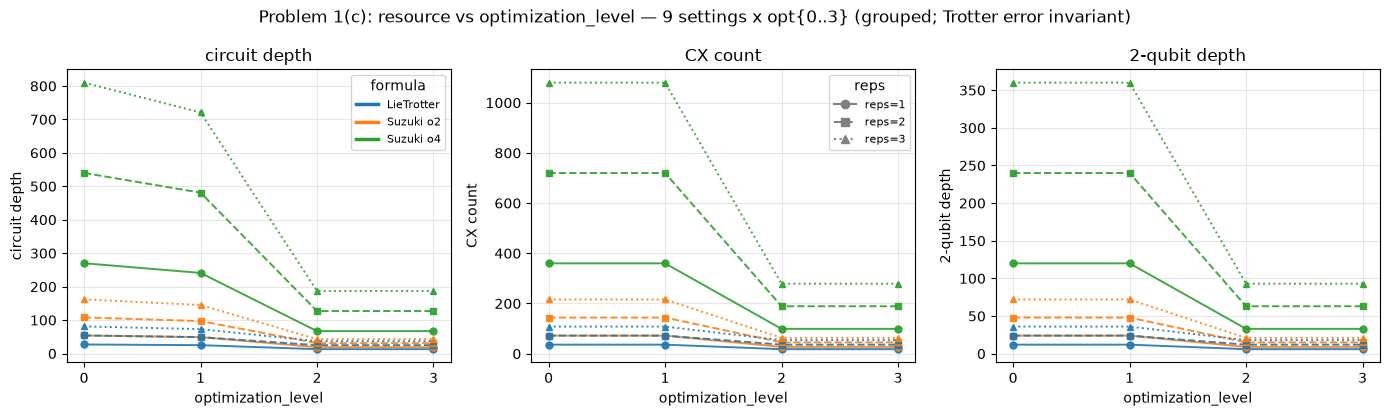

cx_count                        depth                \
opt                             0       1      2      3      0      1      2   
formula       order reps                                                       
LieTrotter    1     1        36.0    36.0   18.0   18.0   27.0   25.0   13.0   
                    2        72.0    72.0   36.0   36.0   54.0   49.0   25.0   
                    3       108.0   108.0   54.0   54.0   81.0   73.0   37.0   
SuzukiTrotter 2     1        72.0    72.0   27.0   27.0   54.0   49.0   19.0   
                    2       144.0   144.0   45.0   45.0  108.0   97.0   31.0   
                    3       216.0   216.0   63.0   63.0  162.0  145.0   43.0   
              4     1       360.0   360.0   99.0   99.0  270.0  241.0   67.0   
                    2       720.0   720.0  189.0  189.0  540.0  481.0  127.0   
                    3      1080.0  1080.0  279.0  279.0  810.0  721.0  187.0   

                                two_qubit_depth                     
opt                           3               0      1     2     3  
formula       order reps                                            
LieTrotter    1     1      13.0            12.0   12.0   6.0   6.0  
                    2      25.0            24.0   24.0  12.0  12.0  
                    3      37.0            36.0   36.0  18.0  18.0  
SuzukiTrotter 2     1      19.0            24.0   24.0   9.0   9.0  
                    2      31.0            48.0   48.0  15.0  15.0  
                    3      43.0            72.0   72.0  21.0  21.0  
              4     1      67.0           120.0  120.0  33.0  33.0  
                    2     127.0           240.0  240.0  63.0  63.0  
                    3     187.0           360.0  360.0  93.0  93.0

In [9]:
# Full opt-level sweep: all 9 settings x opt {0,1,2,3} (grouped ordering).
sweep_rows = []
for nm, syn in SETTINGS.items():
    for opt in [0, 1, 2, 3]:
        tqc = transpile_to_basis(evolution_circuit(0.5, syn, ordering="grouped"), opt=opt)
        sweep_rows.append(dict(setting=nm, **SETTING_META[nm], opt=opt, **resource_counts(tqc)))
sweep_df = pd.DataFrame(sweep_rows)

# opt-invariance proof across ALL 9 settings (compile ablation => logical unitary unchanged)
def _evo_sv_opt(syn, opt):
    qc = evolution_circuit(0.5, syn, ordering="grouped", include_stateprep=True)
    return Statevector.from_instruction(transpile_to_basis(qc.decompose(), opt=opt)).data
max_dev = 0.0
for nm, syn in SETTINGS.items():
    b = _evo_sv_opt(syn, 0)
    for opt in [1, 2, 3]:
        max_dev = max(max_dev, float(np.max(np.abs(b - _evo_sv_opt(syn, opt)))))
print("opt-invariance: max|delta statevector| over ALL 9 settings x opt1-3 = %.2e  (<=1e-9 => error-preserving)" % max_dev)

from matplotlib.lines import Line2D
order_color = {1: "tab:blue", 2: "tab:orange", 4: "tab:green"}   # LieTrotter / Suzuki-2 / Suzuki-4
reps_fmt    = {1: ("-", "o"), 2: ("--", "s"), 3: (":", "^")}
metrics = [("depth", "circuit depth"), ("cx_count", "CX count"), ("two_qubit_depth", "2-qubit depth")]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (m, lbl) in zip(axes, metrics):
    for nm, meta in SETTING_META.items():
        sub = sweep_df[sweep_df.setting == nm].sort_values("opt")
        ls, mk = reps_fmt[meta["reps"]]
        ax.plot(sub.opt, sub[m], ls=ls, marker=mk, color=order_color[meta["order"]], lw=1.4, ms=5, alpha=.9)
    ax.set_xlabel("optimization_level"); ax.set_ylabel(lbl); ax.set_title(lbl)
    ax.set_xticks([0, 1, 2, 3]); ax.grid(alpha=.3)
leg1 = [Line2D([], [], color=order_color[o], lw=2.5, label=l) for o, l in [(1, "LieTrotter"), (2, "Suzuki o2"), (4, "Suzuki o4")]]
leg2 = [Line2D([], [], color="gray", ls=reps_fmt[k][0], marker=reps_fmt[k][1], label="reps=%d" % k) for k in [1, 2, 3]]
axes[0].legend(handles=leg1, fontsize=8, title="formula", loc="upper right")
axes[1].legend(handles=leg2, fontsize=8, title="reps", loc="upper right")
plt.suptitle("Problem 1(c): resource vs optimization_level — 9 settings x opt{0..3} (grouped; Trotter error invariant)")
plt.tight_layout(); plt.show()
sweep_df.pivot_table(index=["formula", "order", "reps"], columns="opt", values=["depth", "cx_count", "two_qubit_depth"])

<!-- INTERPRETATION_KO:resource_opt -->
<div style="border-left:4px solid #8a6fbd; padding:0.65rem 0 0.65rem 1rem; margin:0.75rem 0; background:#fbf8ff;">
<strong>해석.</strong>
resource table은 order와 reps가 정확도만이 아니라 자원도 함께 키운다는 것을 보여준다. 예를 들어 grouped opt3 기준으로 $LT_{k=1}$은 depth 13, CX 18로 가장 얕지만 근사오차가 크고, $ST2_{k=3}$은 depth 43, CX 63으로 중간 비용에서 훨씬 좋은 정확도 영역에 들어간다. $ST4_{k=3}$은 정확도는 가장 강하지만 depth 187, CX 279라서 비용이 급격히 커진다. opt-level sweep은 이와 별개의 이야기다. transpilation optimization은 같은 논리 유니터리를 보존하면서 depth/CX를 줄이는 과정이므로, 여기서는 $\epsilon_{state}$를 바꾸는 knob이 아니라 실행 가능성을 바꾸는 knob으로 해석한다.
</div>


## Problem 1(d-f): state and local-observable errors
$\epsilon_{state}=1-|\langle\psi_{ex}|\psi_{PF}\rangle|^2$ (opt-불변 논리량), $\epsilon_O=|\langle O\rangle_{ex}-\langle O\rangle_{PF}|$.

In [ ]:
PLOT_SETTINGS = list(SETTINGS.keys())  # all 9 settings required by Problem 1(f): LT/ST2/ST4 x k=1,2,3
err_rows = []
for nm in PLOT_SETTINGS:
    syn = SETTINGS[nm]
    for i, t in enumerate(TIMES):
        pf = product_formula_state(t, syn, ordering="grouped")
        inf = float(np.clip(1 - abs(exact_state(t).inner(pf))**2, 0, 1))
        err_rows.append(dict(setting=nm, time=float(t), state_infidelity=inf,
                             Z1_error=abs(exact_z1[i]-expval(pf, Z1_mat)),
                             Z0Z1_error=abs(exact_z0z1[i]-expval(pf, Z0Z1_mat))))
error_table = pd.DataFrame(err_rows)
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for ax, (m, lbl) in zip(axes, [("state_infidelity","state infidelity"),("Z1_error","Z1 error"),("Z0Z1_error","Z0Z1 error")]):
    for nm in PLOT_SETTINGS:
        s = error_table[error_table.setting == nm]
        ax.semilogy(s.time, np.maximum(s[m], 1e-16), label=nm, lw=1.3)
    ax.set_ylabel(lbl); ax.grid(alpha=.3)
axes[0].legend(ncol=3, fontsize=8); axes[-1].set_xlabel("time")
axes[0].set_title("Problem 1(d-f): all-9 errors vs time (grouped)"); plt.tight_layout(); plt.show()
error_table.head()

<!-- INTERPRETATION_KO:errors_time -->
<div style="border-left:4px solid #c47f2c; padding:0.65rem 0 0.65rem 1rem; margin:0.75rem 0; background:#fffaf4;">
<strong>해석.</strong>
세 error plot은 같은 product-formula 근사를 서로 다른 관측창으로 본 것이다. state infidelity $1-|\langle\psi_{ex}|\psi_{PF}\rangle|^2$는 전체 상태벡터 오차를 보는 강한 기준이고, $|\langle Z_1\rangle_{ex}-\langle Z_1\rangle_{PF}|$ 및 $|\langle Z_0Z_1\rangle_{ex}-\langle Z_0Z_1\rangle_{PF}|$는 문제에서 요구한 local observable 기준이다. local observable error가 state infidelity와 항상 같은 순서로 움직일 필요는 없다. 어떤 상태오차는 특정 observable에는 잘 보이지 않을 수 있고, 반대로 작은 상태오차가 특정 상관함수에는 민감하게 나타날 수 있다. 그래서 발표에서는 “전체 상태 정확도”와 “문제 요구 observable 정확도”를 분리해서 말하는 것이 안전하다.
</div>


### 단시간 스케일링 검증 + $t^\ast$  (순위 1차 근거)
order-$p$: $\epsilon_{state}\sim t^{2(p+1)}/r^{2p}$. log-log 기울기를 이론과 대조. 약한 설정은 거친 격자에서 즉시 포화하므로 **전용 fine grid**로 fit(ST4는 floor 한계로 부분 검증).

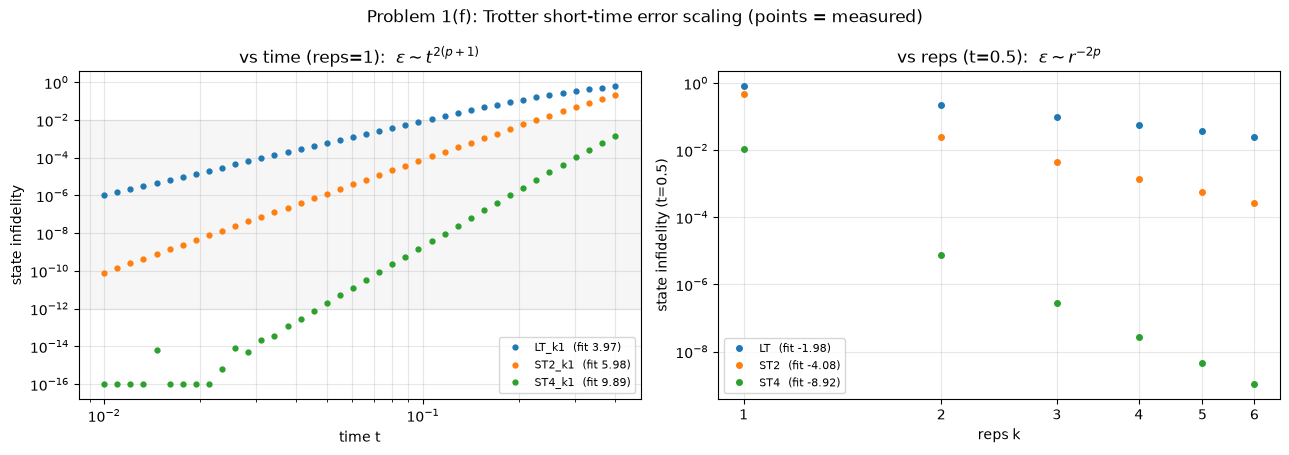

t* (first infidelity>1e-2): {'LT_k1': 0.15, 'ST2_k1': 0.25, 'ST4_k1': 0.5}


,setting,t_star,slope_vs_t,expected_t,slope_vs_reps,expected_reps
0,LT_k1,0.15,3.97,4,-1.98,-2
1,ST2_k1,0.25,5.98,6,-4.08,-4
2,ST4_k1,0.50,9.89,10,-8.92,-8


In [11]:
import matplotlib.ticker as mticker
def infid(t, syn, ordering="grouped"):
    return float(np.clip(1 - abs(exact_state(t).inner(product_formula_state(t, syn, ordering)))**2, 0, 1))
def make_syn(fam, k):
    return LieTrotter(reps=k) if fam == "LT" else SuzukiTrotter(order=int(fam[2]), reps=k)

tstar = {nm: next((round(float(t), 3) for t in TIMES if infid(t, syn) > 1e-2), None) for nm, syn in SETTINGS.items()}
fine = np.geomspace(0.01, 0.4, 40)
def slope_vs_t(syn):
    xs, ys = [], []
    for t in fine:
        e = infid(t, syn)
        if 1e-13 < e < 1e-2: xs.append(np.log10(t)); ys.append(np.log10(e))
    return round(float(np.polyfit(xs, ys, 1)[0]), 2) if len(xs) > 2 else None
def slope_vs_reps(fam, t=0.5, kmax=6):
    xs, ys = [], []
    for k in range(1, kmax + 1):
        e = infid(t, make_syn(fam, k))
        if 1e-13 < e < 1e-1: xs.append(np.log10(k)); ys.append(np.log10(e))
    return round(float(np.polyfit(xs, ys, 1)[0]), 2) if len(xs) > 2 else None

scaling = pd.DataFrame([
    dict(setting=f, t_star=tstar[f], slope_vs_t=slope_vs_t(SETTINGS[f]), expected_t=tt,
         slope_vs_reps=slope_vs_reps(fam), expected_reps=tr)
    for f, fam, tt, tr in [("LT_k1", "LT", 4, -2), ("ST2_k1", "ST2", 6, -4), ("ST4_k1", "ST4", 10, -8)]])

fams = [("LT_k1", "LT", 4, -2, "tab:blue"), ("ST2_k1", "ST2", 6, -4, "tab:orange"), ("ST4_k1", "ST4", 10, -8, "tab:green")]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6))
# left: infidelity vs time (fixed reps=1), measured points only
for nm, fam, st, _, col in fams:
    ys = np.array([infid(t, SETTINGS[nm]) for t in fine])
    axL.loglog(fine, np.maximum(ys, 1e-16), "o", ms=3.5, color=col,
               label="%s  (fit %s)" % (nm, slope_vs_t(SETTINGS[nm])))
axL.axhspan(1e-12, 1e-2, color="gray", alpha=.07)
axL.set_xlabel("time t"); axL.set_ylabel("state infidelity")
axL.set_title(r"vs time (reps=1):  $\epsilon \sim t^{2(p+1)}$")
axL.legend(fontsize=8); axL.grid(which="both", alpha=.3)
# right: infidelity vs reps (fixed t=0.5), measured points only
kk = np.arange(1, 7)
for nm, fam, _, sr, col in fams:
    ys = np.array([infid(0.5, make_syn(fam, k)) for k in kk])
    axR.loglog(kk, np.maximum(ys, 1e-16), "o", ms=4, color=col,
               label="%s  (fit %s)" % (fam, slope_vs_reps(fam)))
axR.set_xlabel("reps k"); axR.set_ylabel("state infidelity (t=0.5)")
axR.set_title(r"vs reps (t=0.5):  $\epsilon \sim r^{-2p}$")
axR.set_xticks(kk); axR.xaxis.set_major_formatter(mticker.ScalarFormatter()); axR.xaxis.set_minor_formatter(mticker.NullFormatter())
axR.legend(fontsize=8); axR.grid(which="both", alpha=.3)
plt.suptitle("Problem 1(f): Trotter short-time error scaling (points = measured)")
plt.tight_layout(); plt.show()
print("t* (first infidelity>1e-2):", {k: tstar[k] for k in ["LT_k1", "ST2_k1", "ST4_k1"]})
scaling

### Problem 1(e-f) add-on: local-observable log-log scaling

The prompt requires local-observable errors for `Z1` and `Z0Z1`. The main error plot already shows these on a semilog time axis; this add-on mirrors the short-time scaling logic used for state infidelity, but with observable-error scaling. For an order-`p` product formula, observable expectation errors generically scale like `t^(p+1)` and `reps^(-p)`, while state infidelity scales roughly as the square of the state-vector error.


In [ ]:
from pathlib import Path
Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

OBS_LOGLOG_CONFIGS = [
    ("Z1_error", Z1_mat, exact_z1, "Z1"),
    ("Z0Z1_error", Z0Z1_mat, exact_z0z1, "Z0Z1"),
]
OBS_FINE = np.geomspace(0.01, 0.4, 40)
OBS_REPS_GRID = np.arange(1, 7)

def observable_error_at_time(t, syn, Omat, ordering="grouped"):
    pf = product_formula_state(float(t), syn, ordering=ordering)
    return float(abs(expval(exact_state(float(t)), Omat) - expval(pf, Omat)))

def observable_slope_vs_t(syn, Omat):
    xs, ys = [], []
    for tv in OBS_FINE:
        e = observable_error_at_time(tv, syn, Omat)
        if 1e-13 < e < 1e-2:
            xs.append(np.log10(tv)); ys.append(np.log10(e))
    return round(float(np.polyfit(xs, ys, 1)[0]), 2) if len(xs) > 2 else None

def observable_slope_vs_reps(fam, Omat, t=0.5, kmax=6):
    xs, ys = [], []
    for k in range(1, kmax + 1):
        e = observable_error_at_time(t, make_syn(fam, k), Omat)
        if 1e-13 < e < 1e-1:
            xs.append(np.log10(k)); ys.append(np.log10(e))
    return round(float(np.polyfit(xs, ys, 1)[0]), 2) if len(xs) > 2 else None

obs_scaling_rows = []
for metric, Omat, _, obs_label in OBS_LOGLOG_CONFIGS:
    for setting, fam, expected_t, expected_reps in [
        ("LT_k1", "LT", 2, -1),
        ("ST2_k1", "ST2", 3, -2),
        ("ST4_k1", "ST4", 5, -4),
    ]:
        obs_scaling_rows.append(dict(
            observable=obs_label,
            setting=setting,
            slope_vs_t=observable_slope_vs_t(SETTINGS[setting], Omat),
            expected_t=expected_t,
            slope_vs_reps=observable_slope_vs_reps(fam, Omat),
            expected_reps=expected_reps,
        ))

observable_loglog_scaling = pd.DataFrame(obs_scaling_rows)
display(observable_loglog_scaling)
observable_loglog_scaling.to_csv("tables/p1_local_observable_loglog_scaling.csv", index=False)

obs_fams = [
    ("LT_k1", "LT", 2, -1, "tab:blue"),
    ("ST2_k1", "ST2", 3, -2, "tab:orange"),
    ("ST4_k1", "ST4", 5, -4, "tab:green"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 8.2))
for row_idx, (_, Omat, _, obs_label) in enumerate(OBS_LOGLOG_CONFIGS):
    axL, axR = axes[row_idx]
    for nm, fam, expected_t, expected_reps, col in obs_fams:
        ys_t = np.array([observable_error_at_time(tv, SETTINGS[nm], Omat) for tv in OBS_FINE])
        axL.loglog(OBS_FINE, np.maximum(ys_t, 1e-16), "o", ms=3.2, color=col,
                   label="%s (fit %s)" % (nm, observable_slope_vs_t(SETTINGS[nm], Omat)))

        ys_k = np.array([observable_error_at_time(0.5, make_syn(fam, k), Omat) for k in OBS_REPS_GRID])
        axR.loglog(OBS_REPS_GRID, np.maximum(ys_k, 1e-16), "o", ms=4, color=col,
                   label="%s (fit %s)" % (fam, observable_slope_vs_reps(fam, Omat)))

    axL.set_xlabel("time t")
    axL.set_ylabel("%s error" % obs_label)
    axL.set_title("%s vs time (reps=1)" % obs_label)
    axL.grid(which="both", alpha=.3)
    axL.legend(fontsize=7)
    axR.set_xlabel("reps k")
    axR.set_ylabel("%s error at t=0.5" % obs_label)
    axR.set_title("%s vs reps" % obs_label)
    axR.set_xticks(OBS_REPS_GRID)
    axR.xaxis.set_major_formatter(mticker.ScalarFormatter())
    axR.xaxis.set_minor_formatter(mticker.NullFormatter())
    axR.grid(which="both", alpha=.3)
    axR.legend(fontsize=7)
plt.suptitle("Problem 1(e-f): local-observable error scaling on log-log axes")
plt.tight_layout()
fig.savefig("figures/p1_local_observable_loglog_scaling.png", dpi=180, bbox_inches="tight")
plt.show()


<!-- INTERPRETATION_KO:scaling -->
<div style="border-left:4px solid #b55353; padding:0.65rem 0 0.65rem 1rem; margin:0.75rem 0; background:#fff7f7;">
<strong>해석.</strong>
log-log scaling plot은 단순 성능표가 아니라 product formula order가 실제로 perturbative regime에서 작동하는지 확인하는 엄밀성 장치이다. state infidelity는 대략 order-$p$ formula에서 $t^{2(p+1)}$ 및 $r^{-2p}$ 스케일을 기대하고, observable expectation error는 보통 그보다 한 번 덜 제곱된 $t^{p+1}$, $r^{-p}$ 스케일을 기준으로 본다. 다만 이 기울기는 작은 $t$와 충분히 작은 오차 범위에서만 의미가 있다. 긴 시간에서 error가 포화되거나 machine precision floor에 닿으면, 기울기 fit은 order 비교가 아니라 포화/수치 floor의 영향을 보게 된다.
</div>


### Presentation add-on: all-9 error table and plots

The existing error plot intentionally shows a readable subset. For presentation production, we also need all 9 `(formula, reps)` settings in a uniform table, plus a full all-9 state-infidelity plot. Observable errors are kept in the table so slides can use them without overcrowding the main plot.

In [ ]:
from pathlib import Path
Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

all9_err_rows = []
for nm, syn in SETTINGS.items():
    for i, t in enumerate(TIMES):
        pf = product_formula_state(float(t), syn, ordering="grouped")
        all9_err_rows.append(dict(
            setting=nm,
            **SETTING_META[nm],
            time=float(t),
            state_infidelity=float(np.clip(1 - abs(exact_state(float(t)).inner(pf))**2, 0, 1)),
            Z1_error=float(abs(exact_z1[i] - expval(pf, Z1_mat))),
            Z0Z1_error=float(abs(exact_z0z1[i] - expval(pf, Z0Z1_mat))),
        ))
all9_error_table = pd.DataFrame(all9_err_rows)
all9_error_table.to_csv("tables/p1_all9_error_time_series.csv", index=False)

# Slide-ready merged table: resource + representative errors + short-time summary metrics.
summary_rows = []
for nm, syn in SETTINGS.items():
    sub = all9_error_table[all9_error_table.setting == nm]
    row05 = sub.iloc[np.argmin(np.abs(sub.time.to_numpy() - 0.5))]
    win_sub = sub[sub.time <= 2.0]
    res = resource_grouped.loc[resource_grouped.setting == nm].iloc[0]
    summary_rows.append(dict(
        setting=nm,
        **SETTING_META[nm],
        depth=int(res.depth),
        CX=int(res.cx_count),
        two_qubit_depth=int(res.two_qubit_depth),
        eps_state_t0p5=float(row05.state_infidelity),
        eps_Z1_t0p5=float(row05.Z1_error),
        eps_Z0Z1_t0p5=float(row05.Z0Z1_error),
        mean_infid_t_le_2=float(win_sub.state_infidelity.mean()),
        max_infid_t_le_2=float(win_sub.state_infidelity.max()),
        t_star_1e_minus_2=tstar[nm],
    ))

p1_error_resource_summary = pd.DataFrame(summary_rows)
display(p1_error_resource_summary)
p1_error_resource_summary.to_csv("tables/p1_error_resource_summary.csv", index=False)

# All-9 state infidelity plot.
from matplotlib.lines import Line2D
order_color = {1: "tab:blue", 2: "tab:orange", 4: "tab:green"}
reps_style = {1: "-", 2: "--", 3: ":"}
fig, ax = plt.subplots(figsize=(10, 5.6))
for nm, meta in SETTING_META.items():
    sub = all9_error_table[all9_error_table.setting == nm]
    ax.semilogy(sub.time, np.maximum(sub.state_infidelity, 1e-16),
                color=order_color[meta["order"]], ls=reps_style[meta["reps"]], lw=1.5, label=nm)
ax.set_xlabel("time t")
ax.set_ylabel("state infidelity")
ax.set_title("Problem 1(d-f): all 9 state-infidelity curves (N=6, grouped)")
ax.grid(which="both", alpha=.3)
leg_formula = [Line2D([], [], color=order_color[o], lw=2.5, label=l)
               for o, l in [(1, "LT order=1"), (2, "ST2 order=2"), (4, "ST4 order=4")]]
leg_reps = [Line2D([], [], color="gray", ls=reps_style[k], lw=2, label="reps=%d" % k)
            for k in [1, 2, 3]]
ax.legend(handles=leg_formula + leg_reps, fontsize=8, ncol=2, loc="lower right")
plt.tight_layout(); plt.savefig("figures/p1_all9_state_infidelity_vs_time.png", dpi=160); plt.show()

# All-9 local-observable time plots for the PDF/guide 1(e-f) observables.
fig, axes = plt.subplots(2, 1, figsize=(10, 7.4), sharex=True)
for ax, metric, ylabel in zip(axes, ["Z1_error", "Z0Z1_error"], ["Z1 error", "Z0Z1 error"]):
    for nm, meta in SETTING_META.items():
        sub = all9_error_table[all9_error_table.setting == nm]
        ax.semilogy(sub.time, np.maximum(sub[metric], 1e-16),
                    color=order_color[meta["order"]], ls=reps_style[meta["reps"]], lw=1.35, label=nm)
    ax.set_ylabel(ylabel)
    ax.grid(which="both", alpha=.3)
axes[-1].set_xlabel("time t")
axes[0].set_title("Problem 1(e-f): all-9 local-observable errors (Z1, Z0Z1)")
axes[0].legend(handles=leg_formula + leg_reps, fontsize=8, ncol=2, loc="lower right")
plt.tight_layout(); plt.savefig("figures/p1_all9_local_observable_errors.png", dpi=160); plt.show()


### Presentation add-on: compact reps-scaling plot at fixed time

This repeats the existing scaling evidence in a slide-friendly form. Interpret it only in the short-time/controlled-step regime, not as a guarantee of monotone long-time ranking.

In [ ]:
fig, ax = plt.subplots(figsize=(7.4, 5))
kk = np.arange(1, 7)
fam_specs = [("LT", 1, -2, "tab:blue"), ("ST2", 2, -4, "tab:orange"), ("ST4", 4, -8, "tab:green")]
for fam, order, expected_slope, col in fam_specs:
    ys = np.array([infid(0.5, make_syn(fam, k)) for k in kk])
    ax.loglog(kk, np.maximum(ys, 1e-16), "o-", color=col, label="%s fit=%s" % (fam, slope_vs_reps(fam)))
ax.set_xlabel("reps k")
ax.set_ylabel("state infidelity at t=0.5")
ax.set_title(r"Reps scaling: $\epsilon \sim k^{-2p}$ in the perturbative regime")
ax.set_xticks(kk); ax.xaxis.set_major_formatter(mticker.ScalarFormatter()); ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.grid(which="both", alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/p1_reps_scaling_t0p5.png", dpi=160); plt.show()


### Problem 1(c/h): accuracy-resource Pareto + 토의
x = opt3 compiled depth(HW 비용), y = mean $\epsilon_{state}$($t\le2.0$, 논리량). **순위 1차 근거는 위 기울기·$t^\ast$**; 윈도우 평균은 포화 지배라 보조로만(역전 가능).

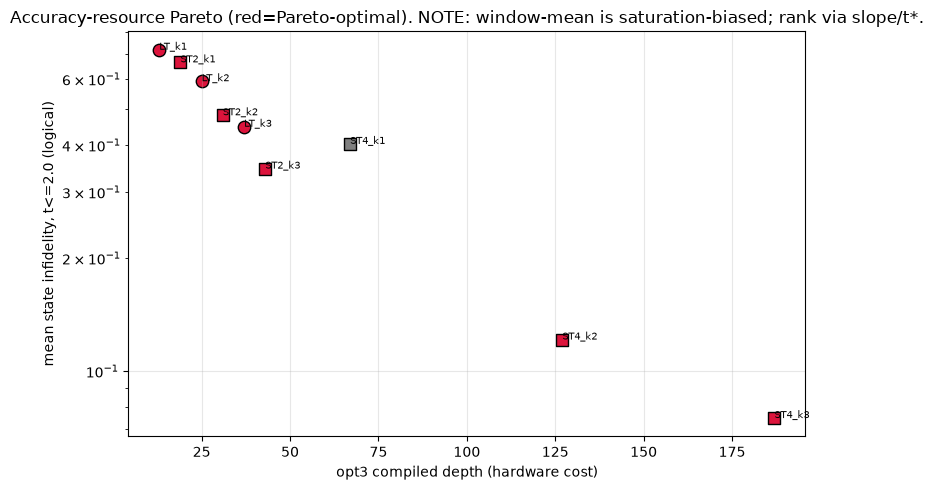

Pareto-optimal settings: ['LT_k1', 'ST2_k1', 'LT_k2', 'ST2_k2', 'ST4_k2', 'LT_k3', 'ST2_k3', 'ST4_k3']


,setting,formula,order,reps,mean_infid,depth,t_star,pareto,scalar_E
0,LT_k1,LieTrotter,1,1,0.717413,13,0.15,True,9.326373
1,ST2_k1,SuzukiTrotter,2,1,0.663986,19,0.25,True,12.615729
2,ST4_k3,SuzukiTrotter,4,3,0.074961,187,1.45,True,14.017786
3,LT_k2,LieTrotter,1,2,0.591515,25,0.15,True,14.787883
4,ST2_k3,SuzukiTrotter,2,3,0.346052,43,0.65,True,14.880249
5,ST2_k2,SuzukiTrotter,2,2,0.480008,31,0.40,True,14.880258
6,ST4_k2,SuzukiTrotter,4,2,0.121310,127,0.95,True,15.406421
7,LT_k3,LieTrotter,1,3,0.447402,37,0.20,True,16.553867
8,ST4_k1,SuzukiTrotter,4,1,0.402686,67,0.50,False,26.979987


In [15]:
win = TIMES[TIMES <= 2.0]
pareto = []
for nm, syn in SETTINGS.items():
    mi = float(np.mean([infid(t, syn) for t in win]))
    dep = int(resource_grouped.loc[resource_grouped.setting == nm, "depth"].iloc[0])
    pareto.append(dict(setting=nm, **SETTING_META[nm], mean_infid=mi, depth=dep, t_star=tstar[nm]))
pareto = pd.DataFrame(pareto)
def is_pareto(r, df):
    dom = (df.depth <= r.depth) & (df.mean_infid <= r.mean_infid) & ((df.depth < r.depth) | (df.mean_infid < r.mean_infid))
    return not dom.any()
pareto["pareto"] = [is_pareto(r, pareto) for _, r in pareto.iterrows()]
pareto["scalar_E"] = pareto.mean_infid * pareto.depth
fig, ax = plt.subplots(figsize=(8, 5)); mk = {"LieTrotter":"o","SuzukiTrotter":"s"}
for _, r in pareto.iterrows():
    ax.scatter(r.depth, max(r.mean_infid, 1e-6), marker=mk[r.formula], s=80, edgecolor="k",
               color=("crimson" if r.pareto else "gray"))
    ax.annotate(r.setting, (r.depth, max(r.mean_infid, 1e-6)), fontsize=7)
ax.set_yscale("log"); ax.set_xlabel("opt3 compiled depth (hardware cost)")
ax.set_ylabel("mean state infidelity, t<=2.0 (logical)")
ax.set_title("Accuracy-resource Pareto (red=Pareto-optimal). NOTE: window-mean is saturation-biased; rank via slope/t*.")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()
print("Pareto-optimal settings:", list(pareto[pareto.pareto].setting))
pareto.sort_values("scalar_E").reset_index(drop=True)

### Presentation add-on: formal Pareto table (`dominated_by`)

The trade-off plot should not be judged by eye. A setting is dominated if another setting has no larger depth, no larger error, and is strictly better in at least one of those two quantities. We compute this both at `t=0.5` and for the secondary window-mean metric over `t <= 2.0`.

In [ ]:
from pathlib import Path
Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

def pareto_with_dominators(df, x_col, y_col):
    rows = []
    for _, r in df.iterrows():
        dominators = []
        for _, q in df.iterrows():
            if q.setting == r.setting:
                continue
            better_or_equal = (q[x_col] <= r[x_col]) and (q[y_col] <= r[y_col])
            strict = (q[x_col] < r[x_col]) or (q[y_col] < r[y_col])
            if better_or_equal and strict:
                dominators.append(q.setting)
        rows.append(dict(setting=r.setting, pareto=(len(dominators) == 0),
                         dominated_by=", ".join(dominators) if dominators else ""))
    return pd.DataFrame(rows)

base = p1_error_resource_summary.copy()
p_t05 = pareto_with_dominators(base, "depth", "eps_state_t0p5")
p_mean = pareto_with_dominators(base, "depth", "mean_infid_t_le_2")

p1_pareto_summary = (
    base[["setting", "formula", "order", "reps", "depth", "CX", "eps_state_t0p5", "mean_infid_t_le_2"]]
    .merge(p_t05.rename(columns={"pareto": "pareto_t0p5", "dominated_by": "dominated_by_t0p5"}), on="setting")
    .merge(p_mean.rename(columns={"pareto": "pareto_mean_t_le_2", "dominated_by": "dominated_by_mean_t_le_2"}), on="setting")
)
display(p1_pareto_summary)
p1_pareto_summary.to_csv("tables/p1_pareto_summary.csv", index=False)

def _plot_pareto(df, y_col, pareto_col, title, fname):
    fig, ax = plt.subplots(figsize=(8.2, 5.2))
    for _, r in df.iterrows():
        color = "crimson" if r[pareto_col] else "gray"
        marker = {1: "s", 2: "o", 4: "^"}[int(r.order)]
        y = max(float(r[y_col]), 1e-16)
        ax.scatter(r.depth, y, s=95, marker=marker, color=color, edgecolor="k", zorder=3)
        ax.annotate(r.setting, (r.depth, y), fontsize=8, xytext=(4, 3), textcoords="offset points")
    frontier = df[df[pareto_col]].sort_values("depth")
    ax.plot(frontier.depth, np.maximum(frontier[y_col].astype(float), 1e-16), "--", color="crimson", lw=1.2, alpha=.7)
    ax.set_yscale("log")
    ax.set_xlabel("opt3 compiled depth")
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.grid(which="both", alpha=.3)
    plt.tight_layout(); plt.savefig(fname, dpi=160); plt.show()

_plot_pareto(p1_pareto_summary, "eps_state_t0p5", "pareto_t0p5",
             "Formal Pareto frontier at t=0.5 (red = non-dominated)",
             "figures/p1_pareto_t0p5_depth_infid.png")
_plot_pareto(p1_pareto_summary, "mean_infid_t_le_2", "pareto_mean_t_le_2",
             "Formal Pareto frontier using mean infidelity over t<=2 (secondary metric)",
             "figures/p1_pareto_mean_depth_infid.png")


### Presentation add-on: same-reps and comparable-depth decision tables

These two tables answer the discussion prompt without using the non-rigorous `order * reps` heuristic. Same-reps comparisons use fixed `k`; comparable-depth comparisons use coarse depth bins and should be read as a hardware-cost discussion, not a mathematical theorem.

In [17]:
same_reps_rank_rows = []
for k, sub in p1_error_resource_summary.groupby("reps"):
    s = sub.sort_values("eps_state_t0p5")
    same_reps_rank_rows.append(dict(
        reps=int(k),
        ranked_settings=" > ".join(s.setting.tolist()),
        best=s.setting.iloc[0],
        best_eps_state_t0p5=float(s.eps_state_t0p5.iloc[0]),
    ))
same_reps_rank = pd.DataFrame(same_reps_rank_rows)
display(same_reps_rank)
same_reps_rank.to_csv("tables/p1_same_reps_rank_t0p5.csv", index=False)

_tmp_depth = p1_error_resource_summary.copy()
_tmp_depth["depth_bin"] = pd.cut(_tmp_depth.depth, bins=[0, 25, 50, np.inf], labels=["low_depth", "medium_depth", "high_depth"])
similar_depth_rank = (
    _tmp_depth.sort_values(["depth_bin", "eps_state_t0p5"])
    .groupby("depth_bin", observed=False)
    .head(3)
    [["depth_bin", "setting", "order", "reps", "depth", "CX", "eps_state_t0p5"]]
    .reset_index(drop=True)
)
display(similar_depth_rank)
similar_depth_rank.to_csv("tables/p1_similar_depth_rank_t0p5.csv", index=False)


,reps,ranked_settings,best,best_eps_state_t0p5
0,1,ST4_k1 > ST2_k1 > LT_k1,ST4_k1,1.090536e-02
1,2,ST4_k2 > ST2_k2 > LT_k2,ST4_k2,7.749437e-06
2,3,ST4_k3 > ST2_k3 > LT_k3,ST4_k3,2.788735e-07


,depth_bin,setting,order,reps,depth,CX,eps_state_t0p5
0,low_depth,LT_k2,1,2,25,36,2.194967e-01
1,low_depth,ST2_k1,2,1,19,27,4.797731e-01
2,low_depth,LT_k1,1,1,13,18,8.015722e-01
3,medium_depth,ST2_k3,2,3,43,63,4.471092e-03
4,medium_depth,ST2_k2,2,2,31,45,2.392291e-02
5,medium_depth,LT_k3,1,3,37,54,9.933475e-02
6,high_depth,ST4_k3,4,3,187,279,2.788735e-07
7,high_depth,ST4_k2,4,2,127,189,7.749437e-06
8,high_depth,ST4_k1,4,1,67,99,1.090536e-02


<!-- INTERPRETATION_KO:pareto -->
<div style="border-left:4px solid #4f8f8f; padding:0.65rem 0 0.65rem 1rem; margin:0.75rem 0; background:#f5ffff;">
<strong>해석.</strong>
accuracy-resource 표와 Pareto plot의 결론은 “높은 order가 항상 실험적으로 최선”이 아니라 “같은 정확도를 더 얕게 사는 지점이 있는가”이다. 같은 reps끼리 비교하면 대체로 $ST4 > ST2 > LT$ 순서로 정확도가 좋아지지만, depth까지 함께 보면 이야기가 달라진다. 예컨대 $ST2_{k=3}$은 $ST4_{k=1}$보다 얕은 회로로 더 좋은 state infidelity를 보이므로, $ST4_{k=1}$은 Pareto 관점에서 설득력이 약하다. 발표용 메시지는 $ST4_{k=3}$이 최고정확도 후보, $ST2_{k=3}$이 정확도-자원 균형 후보, $LT$ 계열은 얕지만 논리오차가 큰 baseline이라는 식으로 정리하면 된다.
</div>


### N=6 vs N=12 accuracy-resource trade-off (t=0.5, opt=3, grouped)
Problem 1(b,c,d,f)를 **t=0.5 단일 시점, opt=3, ordering=grouped**로 N=6과 N=12에 각각 돌려 trade-off를 비교한다.
- N=6: 기본 모델 ($J_x{=}1,J_y{=}0.7,J_z{=}1.2,h_x{=}0.4$, $|010101\rangle$)
- N=12: 1(g) QPU 모델 ($J_x{=}J_y{=}1,J_z{=}1.2,h_x{=}0$, $|10\cdots0\rangle$)

x = opt3 compiled depth(회로 구조상 N-불변), y = $t{=}0.5$ 상태 infidelity. marker=formula order, color=reps.

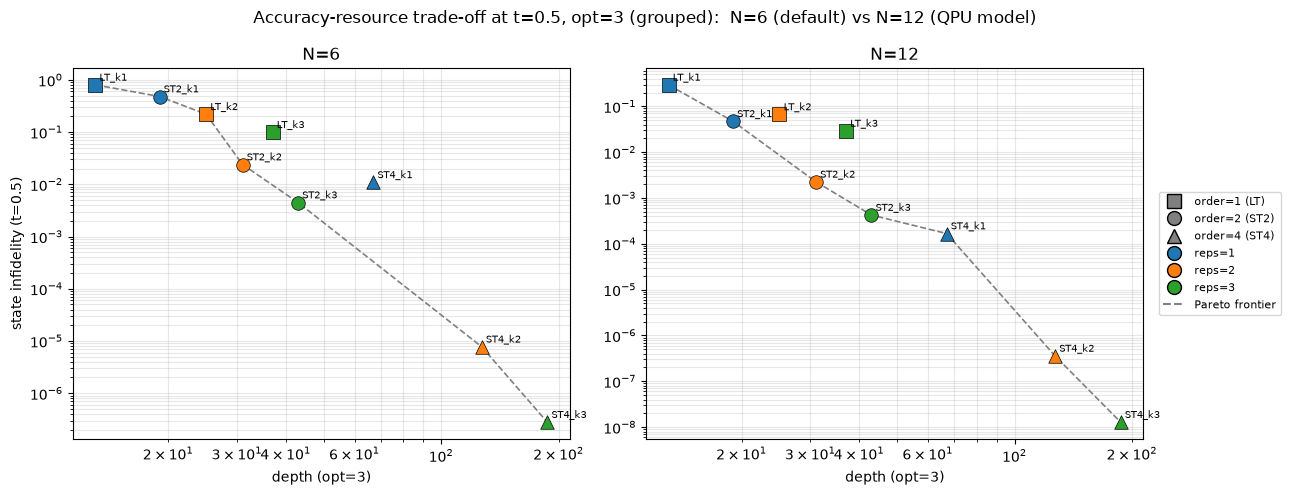

depth           infidelity              
system                     N=12    N=6          N=12           N=6
formula       order reps                                          
LieTrotter    1     1      13.0   13.0  2.950607e-01  8.015722e-01
                    2      25.0   25.0  6.672981e-02  2.194967e-01
                    3      37.0   37.0  2.911604e-02  9.933475e-02
SuzukiTrotter 2     1      19.0   19.0  4.724796e-02  4.797731e-01
                    2      31.0   31.0  2.256066e-03  2.392291e-02
                    3      43.0   43.0  4.254136e-04  4.471092e-03
              4     1      67.0   67.0  1.677587e-04  1.090536e-02
                    2     127.0  127.0  3.572192e-07  7.749437e-06
                    3     187.0  187.0  1.279231e-08  2.788735e-07

In [18]:
# Trade-off at fixed t=0.5, opt=3, ordering=grouped, for N=6 and N=12.
# x = opt3 compiled depth (evolution-only); y = state infidelity at t=0.5 (single point).
configs = [
    ("N=6",  6,  dict(Jx=1.0, Jy=0.7, Jz=1.2, hx=0.4), "010101"),       # default model, Neel
    ("N=12", 12, dict(Jx=1.0, Jy=1.0, Jz=1.2, hx=0.0), "1" + "0"*11),    # 1(g) QPU model, single excitation
]
rows = []
for label, n, model, bit in configs:
    H = build_heisenberg_hamiltonian(num_qubits=n, ordering="grouped", **model)[0]
    evals, evecs = np.linalg.eigh(H.to_matrix())
    psi0v = Statevector.from_label(bit[::-1]).data         # bit is qubit-0-first; reverse for Qiskit label
    coeff = evecs.conj().T @ psi0v
    exact05 = evecs @ (np.exp(-1j*0.5*evals) * coeff)       # exact e^{-iH*0.5}|psi0>
    for nm, syn in SETTINGS.items():
        qc = QuantumCircuit(n)
        for i, ch in enumerate(bit):
            if ch == "1": qc.x(i)
        qc.append(PauliEvolutionGate(H, time=0.5, synthesis=syn), range(n))
        pf = Statevector.from_instruction(qc.decompose()).data
        inf = float(np.clip(1 - abs(np.vdot(exact05, pf))**2, 0, 1))
        qe = QuantumCircuit(n); qe.append(PauliEvolutionGate(H, time=0.5, synthesis=syn), range(n))
        depth = transpile(qe, basis_gates=BASIS_GATES, optimization_level=3, seed_transpiler=42).depth()
        rows.append(dict(system=label, setting=nm, **SETTING_META[nm], depth=depth, infidelity=inf))
tradeoff05 = pd.DataFrame(rows)

from matplotlib.lines import Line2D
order_marker = {1: "s", 2: "o", 4: "^"}              # formula order -> marker
reps_color   = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}   # reps -> color
def _pareto(sub):
    out, best = [], np.inf
    for _, r in sub.sort_values("depth").iterrows():
        if r.infidelity < best - 1e-15:
            out.append((r.depth, r.infidelity)); best = r.infidelity
    return np.array(out)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, sysname in zip(axes, ["N=6", "N=12"]):
    sub = tradeoff05[tradeoff05.system == sysname]
    for _, r in sub.iterrows():
        y = max(r.infidelity, 1e-12)
        ax.scatter(r.depth, y, marker=order_marker[r.order], color=reps_color[r.reps],
                   s=95, edgecolor="k", lw=.5, zorder=3)
        ax.annotate(r.setting, (r.depth, y), fontsize=7, xytext=(3, 3), textcoords="offset points")
    fr = _pareto(sub)
    ax.plot(fr[:, 0], np.maximum(fr[:, 1], 1e-12), "--", color="gray", lw=1.2, zorder=2)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("depth (opt=3)"); ax.set_title(sysname); ax.grid(which="both", alpha=.3)
axes[0].set_ylabel("state infidelity (t=0.5)")
mleg = [Line2D([], [], marker=order_marker[o], color="w", markerfacecolor="gray", markeredgecolor="k",
                ms=10, label=l) for o, l in [(1, "order=1 (LT)"), (2, "order=2 (ST2)"), (4, "order=4 (ST4)")]]
cleg = [Line2D([], [], marker="o", color="w", markerfacecolor=reps_color[k], markeredgecolor="k",
                ms=10, label="reps=%d" % k) for k in [1, 2, 3]]
pleg = [Line2D([], [], ls="--", color="gray", label="Pareto frontier")]
axes[1].legend(handles=mleg + cleg + pleg, fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.suptitle("Accuracy-resource trade-off at t=0.5, opt=3 (grouped):  N=6 (default) vs N=12 (QPU model)")
plt.tight_layout(); plt.show()
tradeoff05.pivot_table(index=["formula", "order", "reps"], columns="system", values=["depth", "infidelity"])

### Circuit resource scaling vs system size N (grouped, opt=3, t=0.5)

9개 synthesis 설정의 **CX 수·depth를 N=12~52로 스케일링**한 표. 1(g) scale-up의 2Q-예산 break 논리(예: ST2_k3는 N=44에서 2q=462>400, ST2_k2는 N=60에서야 초과)를 뒷받침한다. grouped라 **depth는 N-불변**, CX만 ∝N 증가.

In [19]:
N_SCALE = [12, 20, 28, 36, 44, 52]
t_scale = 0.5
scale_rows = []
for nm, syn in SETTINGS.items():
    row = {"model": nm}
    for nq in N_SCALE:
        tqc = transpile_to_basis(evolution_circuit(t_scale, syn, ordering="grouped", num_qubits=nq), opt=3)
        row["cx_%d" % nq] = tqc.count_ops().get("cx", 0)
        row["depth_%d" % nq] = tqc.depth()
    scale_rows.append(row)
df_scale = pd.DataFrame(scale_rows).set_index("model")
df_cx    = df_scale[["cx_%d" % n for n in N_SCALE]].copy();    df_cx.columns    = ["N=%d" % n for n in N_SCALE]
df_depth = df_scale[["depth_%d" % n for n in N_SCALE]].copy(); df_depth.columns = ["N=%d" % n for n in N_SCALE]
print("[CX gate count]  ordering=grouped, opt=3, t=0.5")
display(df_cx)
print("[circuit depth]  ordering=grouped, opt=3, t=0.5  (grouped depth is N-invariant)")
display(df_depth)

[CX gate count]  ordering=grouped, opt=3, t=0.5


,N=12,N=20,N=28,N=36,N=44,N=52
model,,,,,,
LT_k1,36,60,84,108,132,156
ST2_k1,54,90,126,162,198,234
ST4_k1,198,330,462,594,726,858
LT_k2,72,120,168,216,264,312
ST2_k2,90,150,210,270,330,390
ST4_k2,378,630,882,1134,1386,1638
LT_k3,108,180,252,324,396,468
ST2_k3,126,210,294,378,462,546
ST4_k3,558,930,1302,1674,2046,2418


[circuit depth]  ordering=grouped, opt=3, t=0.5  (grouped depth is N-invariant)


,N=12,N=20,N=28,N=36,N=44,N=52
model,,,,,,
LT_k1,13,13,13,13,13,13
ST2_k1,19,19,19,19,19,19
ST4_k1,67,67,67,67,67,67
LT_k2,25,25,25,25,25,25
ST2_k2,31,31,31,31,31,31
ST4_k2,127,127,127,127,127,127
LT_k3,37,37,37,37,37,37
ST2_k3,43,43,43,43,43,43
ST4_k3,187,187,187,187,187,187


### Presentation add-on: N-scaling summary with hardware caveat

The existing N-scaling table is a logical grouped-circuit resource scan in the prompt basis. It supports the statement that grouped logical depth is N-independent while CX count grows linearly in N. This does **not** by itself prove the same depth on real Heron hardware, where routing/layout can add overhead.

In [20]:
from pathlib import Path
Path("tables").mkdir(exist_ok=True)

n_scaling_summary_rows = []
for nm in SETTINGS:
    cx_vals = np.array([df_cx.loc[nm, "N=%d" % n] for n in N_SCALE], dtype=float)
    depth_vals = np.array([df_depth.loc[nm, "N=%d" % n] for n in N_SCALE], dtype=float)
    first_break = next((int(n) for cx, n in zip(cx_vals, N_SCALE) if cx >= 400), None)
    n_scaling_summary_rows.append(dict(
        setting=nm,
        depth_min=int(depth_vals.min()),
        depth_max=int(depth_vals.max()),
        depth_constant=bool(depth_vals.min() == depth_vals.max()),
        CX_per_N_mean=float(np.mean(cx_vals / np.array(N_SCALE))),
        first_N_CX_ge_400=first_break,
        note="logical grouped basis transpilation; real hardware requires ring/layout check",
    ))

n_scaling_summary = pd.DataFrame(n_scaling_summary_rows)
display(n_scaling_summary)
n_scaling_summary.to_csv("tables/p1_n_scaling_summary.csv", index=False)


,setting,depth_min,depth_max,depth_constant,CX_per_N_mean,first_N_CX_ge_400,note
0,LT_k1,13,13,True,3.0,NaN,logical grouped basis transpilation; real hard...
1,ST2_k1,19,19,True,4.5,NaN,logical grouped basis transpilation; real hard...
2,ST4_k1,67,67,True,16.5,28.0,logical grouped basis transpilation; real hard...
3,LT_k2,25,25,True,6.0,NaN,logical grouped basis transpilation; real hard...
4,ST2_k2,31,31,True,7.5,NaN,logical grouped basis transpilation; real hard...
5,ST4_k2,127,127,True,31.5,20.0,logical grouped basis transpilation; real hard...
6,LT_k3,37,37,True,9.0,52.0,logical grouped basis transpilation; real hard...
7,ST2_k3,43,43,True,10.5,44.0,logical grouped basis transpilation; real hard...
8,ST4_k3,187,187,True,46.5,12.0,logical grouped basis transpilation; real hard...


<!-- INTERPRETATION_KO:n_scaling -->
<div style="border-left:4px solid #5b7f95; padding:0.65rem 0 0.65rem 1rem; margin:0.75rem 0; background:#f6fbfd;">
<strong>해석.</strong>
N-scaling 표는 grouped 회로의 구조적 장점과 한계를 동시에 보여준다. ideal grouped basis에서는 disjoint bond layer가 병렬화되기 때문에 depth가 $N$에 거의 의존하지 않고, 대신 CX 수가 대략 $N$에 비례해 증가한다. 따라서 큰 시스템에서 병목은 “시간방향 depth”보다 “총 2-qubit gate budget”이 된다. 단, 이 표는 논리적 grouped 회로를 기준으로 한 resource scan이므로 실제 장치에서는 coupling map과 layout/routing overhead가 추가될 수 있다. 그래서 이 결과는 backend 실행 결과가 아니라, 어떤 formula/reps 조합이 하드웨어 예산에 들어갈 가능성이 높은지 판단하는 사전 필터로 읽어야 한다.
</div>


## Problem 1(g) / PDF 1(h): IBM backend observable targets
For the official prompt outputs, use $N=12$, $J_x=J_y=1$, $J_z=1.2$, $h_x=0$, initial state $|10\cdots0\rangle$, and $t=1.0$.

Required observables: $\langle Z_1\rangle$ and $\langle Z_0Z_1\rangle$.


In [21]:
N12 = 12
def build_H12(ordering="grouped"):
    allb = [(j, (j+1) % N12) for j in range(N12)]; even, odd = allb[0::2], allb[1::2]; rows = []
    for _, L in [("even", even), ("odd", odd)]:
        for P, c in [("XX", 1.0), ("YY", 1.0), ("ZZ", 1.2)]:
            for (a, b) in L: rows.append((P, [a, b], c))
    return SparsePauliOp.from_sparse_list(rows, num_qubits=N12)

def single_one_probabilities(time, num_qubits=N12, j_x=1.0, j_y=1.0, j_z=1.2, h_x=0.0,
                             initial_excitation=0, periodic=True):
    if not np.isclose(j_x, j_y) or not np.isclose(h_x, 0.0):
        raise ValueError("single-excitation reduction requires j_x == j_y and h_x == 0")
    edges = [(i, (i + 1) % num_qubits) for i in range(num_qubits)] if periodic else [(i, i + 1) for i in range(num_qubits - 1)]
    h_eff = np.zeros((num_qubits, num_qubits), dtype=complex)
    for i, j in edges:
        hopping = j_x + j_y
        h_eff[i, j] += hopping
        h_eff[j, i] += hopping
        h_eff[np.diag_indices(num_qubits)] += j_z
        h_eff[i, i] -= 2.0 * j_z
        h_eff[j, j] -= 2.0 * j_z
    psi0_eff = np.zeros(num_qubits, dtype=complex)
    psi0_eff[initial_excitation] = 1.0
    evals, evecs = np.linalg.eigh(h_eff)
    amps = evecs @ (np.exp(-1j * float(time) * evals) * (evecs.conj().T @ psi0_eff))
    return np.abs(amps) ** 2

def p1g_exact_observables(time, num_qubits=N12):
    probs = single_one_probabilities(float(time), num_qubits=num_qubits)
    p0 = float(probs[0])
    p1 = float(probs[1])
    return dict(
        Z0=1.0 - 2.0 * p0,
        Z1=1.0 - 2.0 * p1,
        Z0Z1=1.0 - 2.0 * (p0 + p1),
    )

T1G = 1.0
qc12 = QuantumCircuit(N12); qc12.x(0)                          # |10...0>: qubit 0 excited
qc12.append(PauliEvolutionGate(build_H12(), time=T1G, synthesis=SuzukiTrotter(order=2, reps=2)), range(N12))

sv12 = Statevector.from_instruction(qc12.decompose())
Z0_12 = SparsePauliOp.from_list([(z_label({0}, n=N12), 1.0)]).to_matrix()
Z1_12 = SparsePauliOp.from_list([(z_label({1}, n=N12), 1.0)]).to_matrix()
Z0Z1_12 = SparsePauliOp.from_list([(z_label({0, 1}, n=N12), 1.0)]).to_matrix()
P1G_OBS_MATS_12 = {"Z0": Z0_12, "Z1": Z1_12, "Z0Z1": Z0Z1_12}

p1g_exact_pair = p1g_exact_observables(T1G)
z0_pf = expval(sv12, Z0_12)
z1_pf = expval(sv12, Z1_12)
z0z1_pf = expval(sv12, Z0Z1_12)
z0_exact_1g = p1g_exact_pair["Z0"]
z1_exact_1g = p1g_exact_pair["Z1"]
z0z1_exact_1g = p1g_exact_pair["Z0Z1"]
Nhat = ((N12*SparsePauliOp.from_list([("I"*N12, 1.0)])
         - sum(SparsePauliOp.from_list([("I"*(N12-1-i)+"Z"+"I"*i, 1.0)]) for i in range(N12)))*0.5).to_matrix()
leak = abs(expval(sv12, Nhat) - 1.0)
print("exact <Z0> = %.4f | PF <Z0> = %.4f | |diff| = %.4f   [guide 1(g) official observable]" % (z0_exact_1g, z0_pf, abs(z0_pf - z0_exact_1g)))
print("exact <Z1> = %.4f | PF <Z1> = %.4f | |diff| = %.4f" % (z1_exact_1g, z1_pf, abs(z1_pf - z1_exact_1g)))
print("exact <Z0Z1> = %.4f | PF <Z0Z1> = %.4f | |diff| = %.4f" % (z0z1_exact_1g, z0z1_pf, abs(z0z1_pf - z0z1_exact_1g)))
print("symmetry leakage |<N>-1| = %.2e   (~0: grouped preserves number; same-bond XX,YY commute)" % leak)


exact <Z0> = 0.6846 | PF <Z0> = 0.7846 | |diff| = 0.1000   [guide 1(g) official observable]
exact <Z1> = 0.9913 | PF <Z1> = 0.9936 | |diff| = 0.0024
exact <Z0Z1> = 0.6758 | PF <Z0Z1> = 0.7782 | |diff| = 0.1024
symmetry leakage |<N>-1| = 1.35e-14   (~0: grouped preserves number; same-bond XX,YY commute)


### Hard-constraint 판정 + 생존확률 앵커 (별첨 Heron 문서)
Hint 3 예산을 통과해야 실행. 실기 transpile은 `seed_transpiler` 고정(라우팅 결정성).

In [22]:
# Heron coupling map / native basis. Prefer FakeTorino (Heron r1); fall back to an ideal
# cycle-embedding (basis-only transpile, no routing) if qiskit_ibm_runtime is unavailable.
try:
    from qiskit_ibm_runtime.fake_provider import FakeTorino
    backend = FakeTorino()
    tqc12 = transpile(qc12, backend=backend, optimization_level=3, seed_transpiler=42)
    HW_NOTE = "FakeTorino (Heron r1) coupling map"
except ModuleNotFoundError:
    backend = None
    tqc12 = transpile(qc12, basis_gates=["cz", "rz", "sx", "x"], optimization_level=3, seed_transpiler=42)
    HW_NOTE = "basis-only fallback (ideal cycle embedding; qiskit_ibm_runtime not installed)"
g2  = sum(1 for i in tqc12.data if len(i.qubits) == 2)
tqd = two_qubit_depth(tqc12)
passes = (tqc12.depth() < 100) and (g2 < 400) and (tqd < 30)
e2q = 0.003                       # Heron r2/r3 median 2q error prior
F2q = (1 - e2q) ** g2
print("Hard-constraint  [%s, opt3, seed=42]:" % HW_NOTE)
print("  depth     = %3d  (<100)  %s" % (tqc12.depth(), "PASS" if tqc12.depth() < 100 else "FAIL"))
print("  2q gates  = %3d  (<400)  %s" % (g2, "PASS" if g2 < 400 else "FAIL"))
print("  2q depth  = %3d  (<30 )  %s" % (tqd, "PASS" if tqd < 30 else "FAIL"))
print("  => runnable:", passes)
print("Survival anchor  F2q = (1-%.3f)^%d = %.3f" % (e2q, g2, F2q))
print("  [2q-only UPPER BOUND: excludes 1q error (0.03-0.08%/gate) and idle T1/T2 decoherence]")

Hard-constraint  [FakeTorino (Heron r1) coupling map, opt3, seed=42]:
  depth     =  63  (<100)  PASS
  2q gates  =  90  (<400)  PASS
  2q depth  =  15  (<30 )  PASS
  => runnable: True
Survival anchor  F2q = (1-0.003)^90 = 0.763
  [2q-only UPPER BOUND: excludes 1q error (0.03-0.08%/gate) and idle T1/T2 decoherence]


### Problem 1(g) simulator-first qualification: MPF and post-selection before QPU

Updated plan:
1. Keep the original 1(g) physical problem fixed: `N=12`, `Jx=Jy=1`, `Jz=1.2`, `hx=0`, initial state `|10...0>`, `t=1.0`, observables `<Z0>`, `<Z1>`, and `<Z0Z1>`.
2. First run a clean simulator control, then run noisy classical simulations. This separates product-formula/Trotter bias from hardware-noise bias.
3. Use method-specific fair baselines:
   - **post-selection** is a hardware-noise filter on the same `ST2_k2` circuit, so its fair reference is the noiseless `ST2_k2` value. Exact-dynamics error is still reported separately as end-to-end physical accuracy.
   - **MPF23** uses `ST2_k2` and `ST2_k3`; the fair single-circuit baseline is therefore the unmitigated `ST2_k3` control with the same maximum depth scale, not `ST2_k1` or `ST2_k2` alone.
   - **resilience-level sweeps** are hardware-mitigation ablations of the same submitted circuit, so they are interpreted against the noiseless Trotter value first and against the exact value second.
4. Record physical shots, post-selected accepted shots, acceptance, standard error, fair-baseline improvement, exact error, resource counts, and QPU-readiness reasons.
5. Promote to QPU only if a method is feasible and useful under its fair comparison; exact-error columns are kept to avoid hiding Trotter bias.

Shot convention: post-selection receives the same physical shot budget as raw sampling and then discards out-of-sector bitstrings. If it underperforms, the table distinguishes true shot starvation (`qpu_shots_needed_for_target_se` over budget) from bias caused by restoring the noisy result toward the noiseless Trotter value rather than toward the exact dynamics.


In [ ]:
# ============================================================
# Problem 1(g): noisy classical qualification before QPU promotion.
# Conditions intentionally match the existing 1(g) baseline cell above.
# ============================================================
from pathlib import Path
import os, math, time
Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

P1G_BASELINE_REPS = int(os.environ.get("P1G_BASELINE_REPS", "2"))      # existing 1(g) baseline: ST2_k2
P1G_MPF_REPS_LOW = int(os.environ.get("P1G_MPF_REPS_LOW", "2"))
P1G_MPF_REPS_HIGH = int(os.environ.get("P1G_MPF_REPS_HIGH", "3"))
P1G_MPF_ORDER = int(os.environ.get("P1G_MPF_ORDER", "2"))
P1G_SHOT_GRID = [int(x) for x in os.environ.get("P1G_SHOT_GRID", "1024,4096,8192").split(",") if x.strip()]
P1G_NOISY_SIM_SEED = int(os.environ.get("P1G_NOISY_SIM_SEED", "2026"))
P1G_TARGET_SE = float(os.environ.get("P1G_TARGET_SE", "0.02"))
P1G_MAX_QPU_SHOTS_PER_METHOD = int(os.environ.get("P1G_MAX_QPU_SHOTS_PER_METHOD", "20000"))
P1G_MAX_DEPTH = int(os.environ.get("P1G_MAX_DEPTH", "100"))
P1G_MAX_2Q = int(os.environ.get("P1G_MAX_2Q", "400"))
P1G_MAX_2Q_DEPTH = int(os.environ.get("P1G_MAX_2Q_DEPTH", "30"))
P1G_MIN_POSTSELECT_ACCEPTANCE = float(os.environ.get("P1G_MIN_POSTSELECT_ACCEPTANCE", "0.05"))
P1G_MIN_REL_ERROR_IMPROVEMENT = float(os.environ.get("P1G_MIN_REL_ERROR_IMPROVEMENT", "0.10"))
RUN_P1G_NOISY_SIMULATOR = os.environ.get("RUN_P1G_NOISY_SIMULATOR", "1") == "1"
P1G_PRIMARY_OBSERVABLE = os.environ.get("P1G_PRIMARY_OBSERVABLE", "Z0").strip().upper()
if P1G_PRIMARY_OBSERVABLE not in ("Z0", "Z1", "Z0Z1"):
    raise ValueError("P1G_PRIMARY_OBSERVABLE must be Z0, Z1, or Z0Z1 for official prompt outputs")

P1G_NOISE_LEVELS = [
    dict(noise_label="low", p1=0.0003, p2=0.0010, p_ro=0.005),
    dict(noise_label="heron_prior", p1=0.0006, p2=0.0030, p_ro=0.010),
    dict(noise_label="high", p1=0.0010, p2=0.0060, p_ro=0.020),
]
P1G_PRIMARY_NOISE_LABEL = os.environ.get("P1G_PRIMARY_NOISE_LABEL", "heron_prior")

try:
    from qiskit_aer import AerSimulator
    from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
    HAS_AER_FOR_P1G = True
    P1G_AER_IMPORT_ERROR = None
except Exception as exc:
    AerSimulator = NoiseModel = depolarizing_error = ReadoutError = None
    HAS_AER_FOR_P1G = False
    P1G_AER_IMPORT_ERROR = exc

p1g_condition_table = pd.DataFrame([
    dict(field="N", value=N12),
    dict(field="Hamiltonian", value="periodic XX+YY+1.2ZZ, hx=0"),
    dict(field="initial_state", value="|10...0>, qubit 0 excited"),
    dict(field="time", value=T1G),
    dict(field="observable", value="<Z0>, <Z1>, <Z0Z1>"),
    dict(field="primary_scalar_for_mitigation", value=P1G_PRIMARY_OBSERVABLE),
    dict(field="baseline_formula", value="SuzukiTrotter(order=2, reps=%d)" % P1G_BASELINE_REPS),
    dict(field="postselection_rule", value="Hamming weight == 1"),
    dict(field="fair_baseline_postselection", value="same ST2_k%d circuit, noiseless Trotter value" % P1G_BASELINE_REPS),
    dict(field="fair_baseline_MPF", value="unmitigated ST2_k%d raw control, same max-depth scale" % P1G_MPF_REPS_HIGH),
    dict(field="fair_baseline_resilience", value="same submitted ST2_k%d circuit, noiseless Trotter value" % P1G_BASELINE_REPS),
    dict(field="MPF_formula", value="(%d^%d O_k%d - %d^%d O_k%d) / (%d^%d - %d^%d)" %
         (P1G_MPF_REPS_HIGH, P1G_MPF_ORDER, P1G_MPF_REPS_HIGH,
          P1G_MPF_REPS_LOW, P1G_MPF_ORDER, P1G_MPF_REPS_LOW,
          P1G_MPF_REPS_HIGH, P1G_MPF_ORDER, P1G_MPF_REPS_LOW, P1G_MPF_ORDER)),
])
display(p1g_condition_table)
p1g_condition_table.to_csv("tables/p1g_fixed_experiment_conditions.csv", index=False)

p1g_exact_obs = p1g_exact_observables(T1G)
p1g_exact_z0 = p1g_exact_obs["Z0"]
p1g_exact_z1 = p1g_exact_obs["Z1"]
p1g_exact_z0z1 = p1g_exact_obs["Z0Z1"]
p1g_exact_primary = p1g_exact_obs[P1G_PRIMARY_OBSERVABLE]

def p1g_circuit(reps, measured=False):
    qc = QuantumCircuit(N12, N12) if measured else QuantumCircuit(N12)
    qc.x(0)
    qc.append(PauliEvolutionGate(build_H12(), time=T1G, synthesis=SuzukiTrotter(order=2, reps=int(reps))), range(N12))
    if measured:
        qc.measure(range(N12), range(N12))
    return qc

def p1g_build_noise_model(p1=0.0006, p2=0.0030, p_ro=0.010):
    noise = NoiseModel()
    oneq_error = depolarizing_error(p1, 1)
    twoq_error = depolarizing_error(p2, 2)
    for gate in ["u1", "u2", "u3", "rx", "ry", "rz", "x", "sx", "h"]:
        try:
            noise.add_all_qubit_quantum_error(oneq_error, [gate])
        except Exception:
            pass
    for gate in ["cx", "cz", "ecr", "rxx", "ryy", "rzz"]:
        try:
            noise.add_all_qubit_quantum_error(twoq_error, [gate])
        except Exception:
            pass
    ro = ReadoutError([[1.0 - p_ro, p_ro], [p_ro, 1.0 - p_ro]])
    for q in range(N12):
        noise.add_readout_error(ro, [q])
    return noise

def p1g_value_from_qbits(qbits, observable):
    if observable == "Z0":
        return -1.0 if qbits[0] == "1" else 1.0
    if observable == "Z1":
        return -1.0 if qbits[1] == "1" else 1.0
    if observable == "Z0Z1":
        z0 = -1.0 if qbits[0] == "1" else 1.0
        z1 = -1.0 if qbits[1] == "1" else 1.0
        return z0 * z1
    raise ValueError("unsupported observable: %r" % (observable,))

def p1g_observable_from_counts(counts, observable, postselect_weight1=False):
    total = int(sum(counts.values()))
    accepted = 0
    accum = 0.0
    for bitstr, count in counts.items():
        bits = str(bitstr).replace(" ", "")
        if len(bits) < N12:
            bits = bits.zfill(N12)
        qbits = bits[::-1]  # q0 first
        if postselect_weight1 and qbits.count("1") != 1:
            continue
        accum += int(count) * p1g_value_from_qbits(qbits, observable)
        accepted += int(count)
    if total == 0 or accepted == 0:
        return np.nan, 0.0, 0
    return float(accum / accepted), float(accepted / total), int(accepted)

def p1g_required_observables_from_counts(counts, postselect_weight1=False):
    z0, acc, nacc = p1g_observable_from_counts(counts, "Z0", postselect_weight1=postselect_weight1)
    z1, _, _ = p1g_observable_from_counts(counts, "Z1", postselect_weight1=postselect_weight1)
    z0z1, _, _ = p1g_observable_from_counts(counts, "Z0Z1", postselect_weight1=postselect_weight1)
    return dict(Z0=z0, Z1=z1, Z0Z1=z0z1, acceptance=acc, accepted_shots=nacc)

def p1g_primary_observable_from_counts(counts, postselect_weight1=False):
    return p1g_observable_from_counts(counts, P1G_PRIMARY_OBSERVABLE, postselect_weight1=postselect_weight1)

def p1g_observable_standard_error(obs_value, effective_shots):
    if effective_shots <= 0 or not np.isfinite(obs_value):
        return np.nan
    return float(math.sqrt(max(0.0, 1.0 - float(obs_value) ** 2) / float(effective_shots)))

def p1g_needed_physical_shots_for_postselection(obs_post, acceptance, target_se=P1G_TARGET_SE):
    if acceptance <= 0 or not np.isfinite(obs_post):
        return np.nan
    return int(math.ceil(max(0.0, 1.0 - float(obs_post) ** 2) / (target_se ** 2 * acceptance)))

def p1g_transpile_resource(reps, measured=False, backend_for_transpile=None):
    qc = p1g_circuit(reps, measured=measured)
    if backend_for_transpile is None:
        tqc = transpile(qc, basis_gates=BASIS_GATES, optimization_level=3, seed_transpiler=42)
    else:
        tqc = transpile(qc, backend=backend_for_transpile, optimization_level=3, seed_transpiler=42)
    try:
        resource_circuit = tqc.remove_final_measurements(inplace=False)
    except Exception:
        resource_circuit = tqc
    return dict(depth=resource_circuit.depth(), two_q=sum(1 for inst in resource_circuit.data if len(inst.qubits) == 2),
                two_q_depth=two_qubit_depth(resource_circuit))

def p1g_noiseless_observable(reps, observable):
    sv = Statevector.from_instruction(p1g_circuit(reps, measured=False).decompose())
    return float(expval(sv, P1G_OBS_MATS_12[observable]))

def p1g_noiseless_primary(reps):
    return p1g_noiseless_observable(reps, P1G_PRIMARY_OBSERVABLE)

mpf_denom = P1G_MPF_REPS_HIGH ** P1G_MPF_ORDER - P1G_MPF_REPS_LOW ** P1G_MPF_ORDER
P1G_MPF_COEFF_HIGH = P1G_MPF_REPS_HIGH ** P1G_MPF_ORDER / mpf_denom
P1G_MPF_COEFF_LOW = -P1G_MPF_REPS_LOW ** P1G_MPF_ORDER / mpf_denom

def p1g_mpf_value(z_low, z_high):
    return float(P1G_MPF_COEFF_HIGH * z_high + P1G_MPF_COEFF_LOW * z_low)

def p1g_mpf_se(z_low, z_high, shots_low, shots_high):
    var_low = max(0.0, 1.0 - float(z_low) ** 2) / float(shots_low)
    var_high = max(0.0, 1.0 - float(z_high) ** 2) / float(shots_high)
    return float(math.sqrt((P1G_MPF_COEFF_LOW ** 2) * var_low + (P1G_MPF_COEFF_HIGH ** 2) * var_high))

def p1g_needed_shots_for_mpf(z_low, z_high, target_se=P1G_TARGET_SE):
    # Equal shots per constituent circuit.
    numerator = (P1G_MPF_COEFF_LOW ** 2) * max(0.0, 1.0 - float(z_low) ** 2)
    numerator += (P1G_MPF_COEFF_HIGH ** 2) * max(0.0, 1.0 - float(z_high) ** 2)
    per_circuit = int(math.ceil(numerator / (target_se ** 2)))
    return per_circuit, 2 * per_circuit

unique_reps = sorted(set([P1G_BASELINE_REPS, P1G_MPF_REPS_LOW, P1G_MPF_REPS_HIGH]))
resource_rows = []
for reps in unique_reps:
    z0_pf_rep = p1g_noiseless_observable(reps, "Z0")
    z1_pf_rep = p1g_noiseless_observable(reps, "Z1")
    z0z1_pf_rep = p1g_noiseless_observable(reps, "Z0Z1")
    obs_pf_rep = {"Z0": z0_pf_rep, "Z1": z1_pf_rep, "Z0Z1": z0z1_pf_rep}[P1G_PRIMARY_OBSERVABLE]
    resource_rows.append(dict(reps=reps, formula="ST2_k%d" % reps, observable=P1G_PRIMARY_OBSERVABLE,
                              obs_noiseless_pf=obs_pf_rep, z1_noiseless_pf=z1_pf_rep, z0z1_noiseless_pf=z0z1_pf_rep,
                              abs_trotter_err=abs(obs_pf_rep - p1g_exact_primary),
                              **p1g_transpile_resource(reps, measured=False)))
p1g_noiseless_resource_table = pd.DataFrame(resource_rows)
low_noiseless = p1g_noiseless_resource_table.loc[p1g_noiseless_resource_table.reps == P1G_MPF_REPS_LOW, "obs_noiseless_pf"].iloc[0]
high_noiseless = p1g_noiseless_resource_table.loc[p1g_noiseless_resource_table.reps == P1G_MPF_REPS_HIGH, "obs_noiseless_pf"].iloc[0]
low_z1_noiseless = p1g_noiseless_resource_table.loc[p1g_noiseless_resource_table.reps == P1G_MPF_REPS_LOW, "z1_noiseless_pf"].iloc[0]
high_z1_noiseless = p1g_noiseless_resource_table.loc[p1g_noiseless_resource_table.reps == P1G_MPF_REPS_HIGH, "z1_noiseless_pf"].iloc[0]
low_z0z1_noiseless = p1g_noiseless_resource_table.loc[p1g_noiseless_resource_table.reps == P1G_MPF_REPS_LOW, "z0z1_noiseless_pf"].iloc[0]
high_z0z1_noiseless = p1g_noiseless_resource_table.loc[p1g_noiseless_resource_table.reps == P1G_MPF_REPS_HIGH, "z0z1_noiseless_pf"].iloc[0]
p1g_noiseless_mpf_primary = p1g_mpf_value(low_noiseless, high_noiseless)
p1g_noiseless_mpf_z1 = p1g_mpf_value(low_z1_noiseless, high_z1_noiseless)
p1g_noiseless_mpf_z0z1 = p1g_mpf_value(low_z0z1_noiseless, high_z0z1_noiseless)
base_noiseless = p1g_noiseless_resource_table.loc[p1g_noiseless_resource_table.reps == P1G_BASELINE_REPS].iloc[0]
high_noiseless_row = p1g_noiseless_resource_table.loc[p1g_noiseless_resource_table.reps == P1G_MPF_REPS_HIGH].iloc[0]
p1g_noiseless_check = pd.DataFrame([
    dict(method="baseline_ST2_k%d_noiseless" % P1G_BASELINE_REPS, comparison_role="postselection_reference",
         observable=P1G_PRIMARY_OBSERVABLE, obs_estimate=base_noiseless.obs_noiseless_pf, obs_exact=p1g_exact_primary,
         z1_estimate=base_noiseless.z1_noiseless_pf, z1_exact=p1g_exact_z1,
         z0z1_estimate=base_noiseless.z0z1_noiseless_pf, z0z1_exact=p1g_exact_z0z1,
         fair_baseline_method="self"),
    dict(method="baseline_ST2_k%d_noiseless" % P1G_MPF_REPS_HIGH, comparison_role="MPF_same_max_depth_control",
         observable=P1G_PRIMARY_OBSERVABLE, obs_estimate=high_noiseless_row.obs_noiseless_pf, obs_exact=p1g_exact_primary,
         z1_estimate=high_noiseless_row.z1_noiseless_pf, z1_exact=p1g_exact_z1,
         z0z1_estimate=high_noiseless_row.z0z1_noiseless_pf, z0z1_exact=p1g_exact_z0z1,
         fair_baseline_method="self"),
    dict(method="postselection_ST2_k%d_clean_control" % P1G_BASELINE_REPS, comparison_role="postselection_clean_inert_control",
         observable=P1G_PRIMARY_OBSERVABLE, obs_estimate=base_noiseless.obs_noiseless_pf, obs_exact=p1g_exact_primary,
         z1_estimate=base_noiseless.z1_noiseless_pf, z1_exact=p1g_exact_z1,
         z0z1_estimate=base_noiseless.z0z1_noiseless_pf, z0z1_exact=p1g_exact_z0z1,
         acceptance=1.0, accepted_shots="all", fair_baseline_method="baseline_ST2_k%d_noiseless" % P1G_BASELINE_REPS),
    dict(method="MPF%d%d_noiseless" % (P1G_MPF_REPS_LOW, P1G_MPF_REPS_HIGH), comparison_role="MPF_vs_ST2_k%d_control" % P1G_MPF_REPS_HIGH,
         observable=P1G_PRIMARY_OBSERVABLE, obs_estimate=p1g_noiseless_mpf_primary, obs_exact=p1g_exact_primary,
         z1_estimate=p1g_noiseless_mpf_z1, z1_exact=p1g_exact_z1,
         z0z1_estimate=p1g_noiseless_mpf_z0z1, z0z1_exact=p1g_exact_z0z1,
         fair_baseline_method="baseline_ST2_k%d_noiseless" % P1G_MPF_REPS_HIGH),
])
p1g_noiseless_check["abs_err_vs_exact"] = (p1g_noiseless_check.obs_estimate - p1g_noiseless_check.obs_exact).abs()
_high_exact_err = float(p1g_noiseless_check.loc[p1g_noiseless_check.method == "baseline_ST2_k%d_noiseless" % P1G_MPF_REPS_HIGH, "abs_err_vs_exact"].iloc[0])
p1g_noiseless_check["fair_baseline_error"] = np.where(
    p1g_noiseless_check.method.str.startswith("MPF"), _high_exact_err, p1g_noiseless_check["abs_err_vs_exact"]
)
p1g_noiseless_check["rel_error_improvement_vs_fair_baseline"] = np.where(
    p1g_noiseless_check.method.str.startswith("MPF") & (_high_exact_err > 0),
    (_high_exact_err - p1g_noiseless_check["abs_err_vs_exact"]) / _high_exact_err,
    np.nan,
)
display(p1g_noiseless_resource_table)
display(p1g_noiseless_check)
p1g_noiseless_resource_table.to_csv("tables/p1g_noiseless_resource_table.csv", index=False)
p1g_noiseless_check.to_csv("tables/p1g_noiseless_mpf_check.csv", index=False)
p1g_noiseless_check.to_csv("tables/p1g_clean_mpf_postselection_control.csv", index=False)

p1g_noisy_simulator_rows = []

if not RUN_P1G_NOISY_SIMULATOR:
    print("Noisy simulator qualification skipped. Set RUN_P1G_NOISY_SIMULATOR=1 to run it.")
elif not HAS_AER_FOR_P1G:
    print("qiskit_aer is unavailable, so noisy simulator qualification cannot run:", repr(P1G_AER_IMPORT_ERROR))
else:
    compiled_measured = {
        reps: transpile(p1g_circuit(reps, measured=True), basis_gates=BASIS_GATES, optimization_level=3, seed_transpiler=42)
        for reps in unique_reps
    }
    for noise_cfg in P1G_NOISE_LEVELS:
        noise_model = p1g_build_noise_model(**{k: noise_cfg[k] for k in ["p1", "p2", "p_ro"]})
        sim = AerSimulator(noise_model=noise_model, seed_simulator=P1G_NOISY_SIM_SEED)
        for shots in P1G_SHOT_GRID:
            measured = {}
            t0 = time.perf_counter()
            for reps in unique_reps:
                counts = sim.run(compiled_measured[reps], shots=shots).result().get_counts()
                raw_required = p1g_required_observables_from_counts(counts, postselect_weight1=False)
                ps_required = p1g_required_observables_from_counts(counts, postselect_weight1=True)
                z_raw = raw_required[P1G_PRIMARY_OBSERVABLE]
                z_ps = ps_required[P1G_PRIMARY_OBSERVABLE]
                measured[reps] = dict(counts=counts, z_raw=z_raw, raw_acceptance=raw_required["acceptance"], raw_n=raw_required["accepted_shots"],
                                      z_postselected=z_ps, postselection_acceptance=ps_required["acceptance"], ps_n=ps_required["accepted_shots"],
                                      z1_raw=raw_required["Z1"], z0z1_raw=raw_required["Z0Z1"],
                                      z1_postselected=ps_required["Z1"], z0z1_postselected=ps_required["Z0Z1"])
            runtime_sec = time.perf_counter() - t0

            base = measured[P1G_BASELINE_REPS]
            high = measured[P1G_MPF_REPS_HIGH]
            baseline_err = abs(base["z_raw"] - p1g_exact_primary)
            high_err = abs(high["z_raw"] - p1g_exact_primary)
            base_noiseless_target = float(base_noiseless.obs_noiseless_pf)
            base_noise_err = abs(base["z_raw"] - base_noiseless_target)
            p1g_noisy_simulator_rows.append(dict(
                method="baseline_ST2_k%d_raw" % P1G_BASELINE_REPS,
                observable=P1G_PRIMARY_OBSERVABLE, z1_exact=p1g_exact_z1, z0z1_exact=p1g_exact_z0z1,
                z1_estimate=base["z1_raw"], z0z1_estimate=base["z0z1_raw"],
                mitigation="none", reps=P1G_BASELINE_REPS, noise_label=noise_cfg["noise_label"],
                shots_per_circuit=shots, physical_shots_total=shots, circuits=1,
                accepted_shots=shots, acceptance=1.0, obs_exact=p1g_exact_primary,
                obs_estimate=base["z_raw"], abs_err_vs_exact=baseline_err,
                reference_target="exact_dynamics", reference_value=p1g_exact_primary,
                abs_err_vs_reference=baseline_err, fair_baseline_method="self",
                fair_baseline_error=baseline_err,
                standard_error=p1g_observable_standard_error(base["z_raw"], shots),
                qpu_shots_needed_for_target_se=int(math.ceil(max(0.0, 1.0 - base["z_raw"] ** 2) / (P1G_TARGET_SE ** 2))),
                simulator_runtime_sec=runtime_sec, p1=noise_cfg["p1"], p2=noise_cfg["p2"], p_ro=noise_cfg["p_ro"],
                **p1g_transpile_resource(P1G_BASELINE_REPS, measured=False)
            ))

            p1g_noisy_simulator_rows.append(dict(
                method="baseline_ST2_k%d_raw_control" % P1G_MPF_REPS_HIGH,
                observable=P1G_PRIMARY_OBSERVABLE, z1_exact=p1g_exact_z1, z0z1_exact=p1g_exact_z0z1,
                z1_estimate=high["z1_raw"], z0z1_estimate=high["z0z1_raw"],
                mitigation="none_control", reps=P1G_MPF_REPS_HIGH, noise_label=noise_cfg["noise_label"],
                shots_per_circuit=shots, physical_shots_total=shots, circuits=1,
                accepted_shots=shots, acceptance=1.0, obs_exact=p1g_exact_primary,
                obs_estimate=high["z_raw"], abs_err_vs_exact=high_err,
                reference_target="exact_dynamics", reference_value=p1g_exact_primary,
                abs_err_vs_reference=high_err, fair_baseline_method="self",
                fair_baseline_error=high_err,
                standard_error=p1g_observable_standard_error(high["z_raw"], shots),
                qpu_shots_needed_for_target_se=int(math.ceil(max(0.0, 1.0 - high["z_raw"] ** 2) / (P1G_TARGET_SE ** 2))),
                simulator_runtime_sec=runtime_sec, p1=noise_cfg["p1"], p2=noise_cfg["p2"], p_ro=noise_cfg["p_ro"],
                **p1g_transpile_resource(P1G_MPF_REPS_HIGH, measured=False)
            ))

            ps_err = abs(base["z_postselected"] - p1g_exact_primary) if np.isfinite(base["z_postselected"]) else np.nan
            p1g_noisy_simulator_rows.append(dict(
                method="postselection_ST2_k%d_weight1" % P1G_BASELINE_REPS,
                observable=P1G_PRIMARY_OBSERVABLE, z1_exact=p1g_exact_z1, z0z1_exact=p1g_exact_z0z1,
                z1_estimate=base["z1_postselected"], z0z1_estimate=base["z0z1_postselected"],
                mitigation="postselection", reps=P1G_BASELINE_REPS, noise_label=noise_cfg["noise_label"],
                shots_per_circuit=shots, physical_shots_total=shots, circuits=1,
                accepted_shots=base["ps_n"], acceptance=base["postselection_acceptance"], obs_exact=p1g_exact_primary,
                obs_estimate=base["z_postselected"], abs_err_vs_exact=ps_err,
                reference_target="noiseless_ST2_k%d" % P1G_BASELINE_REPS, reference_value=base_noiseless_target,
                abs_err_vs_reference=(abs(base["z_postselected"] - base_noiseless_target) if np.isfinite(base["z_postselected"]) else np.nan),
                fair_baseline_method="baseline_ST2_k%d_raw_vs_noiseless_ST2_k%d" % (P1G_BASELINE_REPS, P1G_BASELINE_REPS),
                fair_baseline_error=base_noise_err,
                standard_error=p1g_observable_standard_error(base["z_postselected"], base["ps_n"]),
                qpu_shots_needed_for_target_se=p1g_needed_physical_shots_for_postselection(base["z_postselected"], base["postselection_acceptance"]),
                simulator_runtime_sec=runtime_sec, p1=noise_cfg["p1"], p2=noise_cfg["p2"], p_ro=noise_cfg["p_ro"],
                **p1g_transpile_resource(P1G_BASELINE_REPS, measured=False)
            ))

            low = measured[P1G_MPF_REPS_LOW]
            high = measured[P1G_MPF_REPS_HIGH]
            z_mpf = p1g_mpf_value(low["z_raw"], high["z_raw"])
            z1_mpf = p1g_mpf_value(low["z1_raw"], high["z1_raw"])
            z0z1_mpf = p1g_mpf_value(low["z0z1_raw"], high["z0z1_raw"])
            mpf_err = abs(z_mpf - p1g_exact_primary)
            mpf_per_circuit_needed, mpf_total_needed = p1g_needed_shots_for_mpf(low["z_raw"], high["z_raw"])
            low_res = p1g_transpile_resource(P1G_MPF_REPS_LOW, measured=False)
            high_res = p1g_transpile_resource(P1G_MPF_REPS_HIGH, measured=False)
            p1g_noisy_simulator_rows.append(dict(
                method="MPF%d%d_raw" % (P1G_MPF_REPS_LOW, P1G_MPF_REPS_HIGH),
                observable=P1G_PRIMARY_OBSERVABLE, z1_exact=p1g_exact_z1, z0z1_exact=p1g_exact_z0z1,
                z1_estimate=z1_mpf, z0z1_estimate=z0z1_mpf,
                mitigation="MPF", reps="%d,%d" % (P1G_MPF_REPS_LOW, P1G_MPF_REPS_HIGH), noise_label=noise_cfg["noise_label"],
                shots_per_circuit=shots, physical_shots_total=2 * shots, circuits=2,
                accepted_shots=2 * shots, acceptance=1.0, obs_exact=p1g_exact_primary,
                obs_estimate=z_mpf, abs_err_vs_exact=mpf_err,
                reference_target="exact_dynamics", reference_value=p1g_exact_primary,
                abs_err_vs_reference=mpf_err,
                fair_baseline_method="baseline_ST2_k%d_raw_control_vs_exact" % P1G_MPF_REPS_HIGH,
                fair_baseline_error=high_err,
                standard_error=p1g_mpf_se(low["z_raw"], high["z_raw"], shots, shots),
                qpu_shots_needed_for_target_se=mpf_total_needed,
                mpf_shots_needed_per_circuit=mpf_per_circuit_needed,
                mpf_coeff_low=P1G_MPF_COEFF_LOW, mpf_coeff_high=P1G_MPF_COEFF_HIGH,
                obs_low_reps_raw=low["z_raw"], obs_high_reps_raw=high["z_raw"],
                simulator_runtime_sec=runtime_sec, p1=noise_cfg["p1"], p2=noise_cfg["p2"], p_ro=noise_cfg["p_ro"],
                depth=max(low_res["depth"], high_res["depth"]),
                two_q=low_res["two_q"] + high_res["two_q"],
                two_q_depth=max(low_res["two_q_depth"], high_res["two_q_depth"]),
            ))

p1g_noisy_simulator_qualification = pd.DataFrame(p1g_noisy_simulator_rows)

if not p1g_noisy_simulator_qualification.empty:
    rel_improvements = []
    ready_flags = []
    ready_reasons = []
    for row in p1g_noisy_simulator_qualification.itertuples():
        base_err = float(getattr(row, "fair_baseline_error", np.nan))
        ref_err = float(getattr(row, "abs_err_vs_reference", np.nan))
        rel = (base_err - ref_err) / base_err if base_err and np.isfinite(base_err) and base_err > 0 else np.nan
        rel_improvements.append(rel)
        reasons = []
        depth = float(getattr(row, "depth", np.nan))
        two_q = float(getattr(row, "two_q", np.nan))
        two_q_depth = float(getattr(row, "two_q_depth", np.nan))
        if row.mitigation in ("none", "none_control"):
            reasons.append("baseline/control")
        if row.mitigation == "postselection" and row.acceptance < P1G_MIN_POSTSELECT_ACCEPTANCE:
            reasons.append("acceptance %.3f < %.3f" % (row.acceptance, P1G_MIN_POSTSELECT_ACCEPTANCE))
        if row.mitigation in ("postselection", "MPF") and (not np.isfinite(rel) or rel < P1G_MIN_REL_ERROR_IMPROVEMENT):
            reasons.append("fair-baseline relative improvement %.3f < %.3f" % (rel if np.isfinite(rel) else np.nan, P1G_MIN_REL_ERROR_IMPROVEMENT))
        if row.qpu_shots_needed_for_target_se > P1G_MAX_QPU_SHOTS_PER_METHOD:
            reasons.append("target-SE shot estimate %s > budget %d" % (row.qpu_shots_needed_for_target_se, P1G_MAX_QPU_SHOTS_PER_METHOD))
        if (not np.isfinite(depth)) or depth >= P1G_MAX_DEPTH:
            reasons.append("depth %s >= %d" % (getattr(row, "depth", np.nan), P1G_MAX_DEPTH))
        if (not np.isfinite(two_q)) or two_q >= P1G_MAX_2Q:
            reasons.append("2q gates %s >= %d" % (getattr(row, "two_q", np.nan), P1G_MAX_2Q))
        if (not np.isfinite(two_q_depth)) or two_q_depth >= P1G_MAX_2Q_DEPTH:
            reasons.append("2q depth %s >= %d" % (getattr(row, "two_q_depth", np.nan), P1G_MAX_2Q_DEPTH))
        if row.mitigation == "MPF" and abs(row.obs_estimate) > 1.05:
            reasons.append("MPF estimate outside physical range by >5%")
        ready = (row.mitigation in ("postselection", "MPF")) and not reasons
        ready_flags.append(bool(ready))
        ready_reasons.append("ready" if ready else "; ".join(reasons))
    p1g_noisy_simulator_qualification["rel_error_improvement_vs_fair_baseline"] = rel_improvements
    p1g_noisy_simulator_qualification["rel_error_improvement_vs_raw_baseline"] = rel_improvements  # legacy alias
    p1g_noisy_simulator_qualification["qpu_ready_candidate"] = ready_flags
    p1g_noisy_simulator_qualification["qpu_readiness_reason"] = ready_reasons

    p1g_qpu_promotion_candidates = (p1g_noisy_simulator_qualification[
        (p1g_noisy_simulator_qualification.noise_label == P1G_PRIMARY_NOISE_LABEL)
        & (p1g_noisy_simulator_qualification.qpu_ready_candidate)
    ].sort_values(["abs_err_vs_reference", "physical_shots_total", "method"]).reset_index(drop=True))

    display_cols = ["noise_label", "method", "shots_per_circuit", "physical_shots_total", "accepted_shots",
                    "acceptance", "observable", "obs_estimate", "obs_exact", "reference_target", "reference_value",
                    "abs_err_vs_reference", "abs_err_vs_exact", "fair_baseline_method", "fair_baseline_error",
                    "z1_estimate", "z1_exact", "z0z1_estimate", "z0z1_exact", "standard_error",
                    "qpu_shots_needed_for_target_se", "rel_error_improvement_vs_fair_baseline",
                    "qpu_ready_candidate", "qpu_readiness_reason", "depth", "two_q", "two_q_depth"]
    with pd.option_context("display.max_columns", None, "display.max_colwidth", 180, "display.width", 260):
        display(p1g_noisy_simulator_qualification[display_cols])
        print("QPU promotion candidates under noise_label=%r:" % P1G_PRIMARY_NOISE_LABEL)
        display(p1g_qpu_promotion_candidates[display_cols] if not p1g_qpu_promotion_candidates.empty else p1g_qpu_promotion_candidates)

    p1g_noisy_simulator_qualification.to_csv("tables/p1g_noisy_simulator_qualification.csv", index=False)
    p1g_qpu_promotion_candidates.to_csv("tables/p1g_qpu_promotion_candidates.csv", index=False)

    primary = p1g_noisy_simulator_qualification[p1g_noisy_simulator_qualification.noise_label == P1G_PRIMARY_NOISE_LABEL].copy()
    if not primary.empty:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        for method, sub in primary.groupby("method"):
            sub = sub.sort_values("physical_shots_total")
            axes[0].plot(sub.physical_shots_total, sub.abs_err_vs_reference, "o-", label=method)
            axes[1].plot(sub.physical_shots_total, sub.standard_error, "o-", label=method)
        axes[0].set_xscale("log"); axes[0].set_yscale("log")
        axes[1].set_xscale("log"); axes[1].set_yscale("log")
        axes[0].set_xlabel("physical shots total"); axes[0].set_ylabel("|estimate - fair reference|")
        axes[1].set_xlabel("physical shots total"); axes[1].set_ylabel("estimated standard error")
        axes[0].set_title("Fair-baseline effectiveness")
        axes[1].set_title("Shot-cost diagnostic")
        for ax in axes:
            ax.grid(which="both", alpha=.3)
            ax.legend(fontsize=8)
        plt.suptitle("Problem 1(g) simulator-first qualification: %s noise" % P1G_PRIMARY_NOISE_LABEL)
        plt.tight_layout()
        fig.savefig("figures/p1g_noisy_simulator_qualification.png", dpi=180, bbox_inches="tight")
        plt.show()
else:
    p1g_qpu_promotion_candidates = pd.DataFrame()


### MPF validity and four-stage post-selection decomposition

This lightweight analysis cell implements the reporting rule used below:

- MPF is judged against exact dynamics using `epsilon_A` and `epsilon_state`, and its fair single-circuit control is `ST2_k3` because MPF23 reaches the same maximum product-formula depth.
- The MPF validity check reports whether the base second-order Trotter errors obey `e(r)/e(2r) ~= 4` before Richardson/MPF extrapolation is trusted.
- Post-selection is judged as hardware-noise mitigation against the noiseless `ST2_k2` value of `<Z0>`, while exact error is kept as a separate end-to-end accuracy column.
- The four-stage table separates `exact -> noiseless Trotter -> noisy raw -> noisy post-selected`, so Trotter bias and noise bias are visible instead of being collapsed into one number.


In [ ]:
# ===== 1(g) MPF validity + exact/noiseless/raw/post-selected decomposition =====
from pathlib import Path
from scipy.sparse.linalg import expm_multiply
Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

_required_mpf_report = [
    "N12", "T1G", "build_H12", "p1g_circuit", "p1g_transpile_resource",
    "p1g_noiseless_observable", "p1g_exact_observables", "P1G_MPF_REPS_LOW",
    "P1G_MPF_REPS_HIGH", "P1G_MPF_COEFF_LOW", "P1G_MPF_COEFF_HIGH",
    "P1G_BASELINE_REPS", "P1G_PRIMARY_NOISE_LABEL", "p1g_noisy_simulator_qualification",
]
_missing_mpf_report = [name for name in _required_mpf_report if name not in globals()]
if _missing_mpf_report:
    raise RuntimeError("Run the 1(g) simulator qualification cell first. Missing: %s" % _missing_mpf_report)

P1G_MPF_VALIDATION_REPS = [int(x) for x in os.environ.get("P1G_MPF_VALIDATION_REPS", "1,2,4").split(",") if x.strip()]
P1G_DECOMP_SHOTS = os.environ.get("P1G_DECOMP_SHOTS", "").strip()

_H12_sparse = build_H12().to_matrix(sparse=True)
_qc_init_12 = QuantumCircuit(N12)
_qc_init_12.x(0)
_p1g_psi0_vec = Statevector.from_instruction(_qc_init_12).data
_p1g_exact_vec = np.asarray(expm_multiply((-1j * float(T1G)) * _H12_sparse, _p1g_psi0_vec), dtype=complex)
_p1g_A_exact = complex(np.vdot(_p1g_psi0_vec, _p1g_exact_vec))

def p1g_pf_state_vec(reps):
    return Statevector.from_instruction(p1g_circuit(int(reps), measured=False).decompose()).data

def p1g_state_epsilon(vec_est, vec_ref, normalize_est=False):
    est = np.asarray(vec_est, dtype=complex)
    ref = np.asarray(vec_ref, dtype=complex)
    if normalize_est:
        nrm = np.linalg.norm(est)
        if nrm > 0:
            est = est / nrm
    inner = np.vdot(ref, est)
    phase = inner / abs(inner) if abs(inner) > 0 else 1.0 + 0.0j
    return float(np.linalg.norm(est * np.conj(phase) - ref))

def p1g_state_infidelity_normalized(vec_est, vec_ref):
    est = np.asarray(vec_est, dtype=complex)
    ref = np.asarray(vec_ref, dtype=complex)
    nrm = np.linalg.norm(est)
    if nrm <= 0:
        return np.nan
    est = est / nrm
    return float(np.clip(1.0 - abs(np.vdot(ref, est)) ** 2, 0.0, 1.0))

def p1g_autocorr(vec):
    return complex(np.vdot(_p1g_psi0_vec, np.asarray(vec, dtype=complex)))

def p1g_mpf_state_vec(low_reps=P1G_MPF_REPS_LOW, high_reps=P1G_MPF_REPS_HIGH):
    return (P1G_MPF_COEFF_HIGH * p1g_pf_state_vec(high_reps)
            + P1G_MPF_COEFF_LOW * p1g_pf_state_vec(low_reps))

def p1g_exact_error_metrics(label, vec, circuits=1, shot_multiplier=1, resource=None):
    A = p1g_autocorr(vec)
    row = dict(
        method=label,
        circuits=int(circuits),
        shot_multiplier=float(shot_multiplier),
        epsilon_A=float(abs(A - _p1g_A_exact)),
        epsilon_state=float(p1g_state_epsilon(vec, _p1g_exact_vec, normalize_est=False)),
        state_infidelity=float(p1g_state_infidelity_normalized(vec, _p1g_exact_vec)),
        state_norm=float(np.linalg.norm(vec)),
        A_real=float(np.real(A)),
        A_imag=float(np.imag(A)),
        A_exact_real=float(np.real(_p1g_A_exact)),
        A_exact_imag=float(np.imag(_p1g_A_exact)),
    )
    if resource:
        row.update(resource)
    return row

mpf_exact_rows = []
for reps in [P1G_MPF_REPS_LOW, P1G_MPF_REPS_HIGH]:
    mpf_exact_rows.append(p1g_exact_error_metrics(
        "ST2_k%d_noiseless" % reps,
        p1g_pf_state_vec(reps),
        circuits=1,
        shot_multiplier=1,
        resource=p1g_transpile_resource(reps, measured=False),
    ))
_low_res = p1g_transpile_resource(P1G_MPF_REPS_LOW, measured=False)
_high_res = p1g_transpile_resource(P1G_MPF_REPS_HIGH, measured=False)
mpf_exact_rows.append(p1g_exact_error_metrics(
    "MPF%d%d_noiseless" % (P1G_MPF_REPS_LOW, P1G_MPF_REPS_HIGH),
    p1g_mpf_state_vec(),
    circuits=2,
    shot_multiplier=2,
    resource=dict(depth=max(_low_res["depth"], _high_res["depth"]),
                  two_q=_low_res["two_q"] + _high_res["two_q"],
                  two_q_depth=max(_low_res["two_q_depth"], _high_res["two_q_depth"])),
))
p1g_mpf_exact_validity = pd.DataFrame(mpf_exact_rows)
_khigh_label = "ST2_k%d_noiseless" % P1G_MPF_REPS_HIGH
_mpf_label = "MPF%d%d_noiseless" % (P1G_MPF_REPS_LOW, P1G_MPF_REPS_HIGH)
_khigh = p1g_mpf_exact_validity[p1g_mpf_exact_validity.method == _khigh_label].iloc[0]
_mpf = p1g_mpf_exact_validity[p1g_mpf_exact_validity.method == _mpf_label].iloc[0]
p1g_mpf_exact_validity["fair_single_circuit_control"] = _khigh_label
p1g_mpf_exact_validity["epsilon_A_improvement_factor_vs_ST2_k%d" % P1G_MPF_REPS_HIGH] = np.where(
    p1g_mpf_exact_validity.method == _mpf_label, float(_khigh.epsilon_A) / float(_mpf.epsilon_A), np.nan)
p1g_mpf_exact_validity["epsilon_state_improvement_factor_vs_ST2_k%d" % P1G_MPF_REPS_HIGH] = np.where(
    p1g_mpf_exact_validity.method == _mpf_label, float(_khigh.epsilon_state) / float(_mpf.epsilon_state), np.nan)

audit_rows = []
for reps in P1G_MPF_VALIDATION_REPS:
    vec = p1g_pf_state_vec(reps)
    audit_rows.append(p1g_exact_error_metrics("ST2_k%d" % reps, vec, resource=p1g_transpile_resource(reps, measured=False)))
p1g_mpf_error_scaling_validation = pd.DataFrame(audit_rows)
ratio_rows = []
for reps in P1G_MPF_VALIDATION_REPS:
    if 2 * reps not in P1G_MPF_VALIDATION_REPS:
        continue
    lo = p1g_mpf_error_scaling_validation[p1g_mpf_error_scaling_validation.method == "ST2_k%d" % reps].iloc[0]
    hi = p1g_mpf_error_scaling_validation[p1g_mpf_error_scaling_validation.method == "ST2_k%d" % (2 * reps)].iloc[0]
    ratio_rows.append(dict(
        pair="%d_to_%d" % (reps, 2 * reps),
        expected_ratio_second_order=4.0,
        epsilon_A_ratio=float(lo.epsilon_A / hi.epsilon_A) if hi.epsilon_A > 0 else np.nan,
        epsilon_state_ratio=float(lo.epsilon_state / hi.epsilon_state) if hi.epsilon_state > 0 else np.nan,
        state_infidelity_ratio=float(lo.state_infidelity / hi.state_infidelity) if hi.state_infidelity > 0 else np.nan,
    ))
p1g_mpf_scaling_ratio_check = pd.DataFrame(ratio_rows)

print("MPF exact-metric table: MPF23 is compared to ST2_k%d, not ST2_k%d." % (P1G_MPF_REPS_HIGH, P1G_MPF_REPS_LOW))
display(p1g_mpf_exact_validity)
print("Base ST2 validity check: epsilon_A and epsilon_state should shrink by about 4 when reps doubles.")
display(p1g_mpf_scaling_ratio_check)
p1g_mpf_exact_validity.to_csv("tables/p1g_mpf_exact_validity.csv", index=False)
p1g_mpf_error_scaling_validation.to_csv("tables/p1g_mpf_error_scaling_validation.csv", index=False)
p1g_mpf_scaling_ratio_check.to_csv("tables/p1g_mpf_scaling_ratio_check.csv", index=False)

_primary = p1g_noisy_simulator_qualification[
    p1g_noisy_simulator_qualification.noise_label == P1G_PRIMARY_NOISE_LABEL
].copy()
if _primary.empty:
    p1g_four_stage_decomposition = pd.DataFrame()
    print("No rows for primary noise label %r; four-stage decomposition skipped." % P1G_PRIMARY_NOISE_LABEL)
else:
    if P1G_DECOMP_SHOTS:
        _shot_choice = int(P1G_DECOMP_SHOTS)
    else:
        _shot_choice = int(_primary.shots_per_circuit.max())
    _base = _primary[(_primary.mitigation == "none") & (_primary.reps.astype(str) == str(P1G_BASELINE_REPS)) & (_primary.shots_per_circuit == _shot_choice)]
    _ps = _primary[(_primary.mitigation == "postselection") & (_primary.reps.astype(str) == str(P1G_BASELINE_REPS)) & (_primary.shots_per_circuit == _shot_choice)]
    if _base.empty or _ps.empty:
        raise RuntimeError("Missing raw/postselection rows for noise=%s, reps=%s, shots=%s" % (P1G_PRIMARY_NOISE_LABEL, P1G_BASELINE_REPS, _shot_choice))
    _base = _base.iloc[0]
    _ps = _ps.iloc[0]
    _z0_exact = p1g_exact_observables(T1G, num_qubits=N12)["Z0"]
    _z0_noiseless = p1g_noiseless_observable(P1G_BASELINE_REPS, "Z0")
    _raw_z0 = float(_base.obs_estimate)
    _ps_z0 = float(_ps.obs_estimate)
    _raw_noise_abs = abs(_raw_z0 - _z0_noiseless)
    _ps_noise_abs = abs(_ps_z0 - _z0_noiseless)
    _noise_improve = _raw_noise_abs / _ps_noise_abs if _ps_noise_abs > 0 else np.inf
    p1g_four_stage_decomposition = pd.DataFrame([
        dict(stage="exact_dynamics", z0_value=_z0_exact, reference="ground truth", physical_shots=0,
             accepted_shots=np.nan, acceptance=np.nan),
        dict(stage="noiseless_ST2_k%d" % P1G_BASELINE_REPS, z0_value=_z0_noiseless, reference="Trotter-only", physical_shots=0,
             accepted_shots=np.nan, acceptance=1.0),
        dict(stage="noisy_raw_ST2_k%d" % P1G_BASELINE_REPS, z0_value=_raw_z0, reference="raw hardware/noisy simulator", physical_shots=int(_base.physical_shots_total),
             accepted_shots=float(_base.accepted_shots), acceptance=float(_base.acceptance)),
        dict(stage="noisy_postselected_ST2_k%d" % P1G_BASELINE_REPS, z0_value=_ps_z0, reference="post-selected hardware/noisy simulator", physical_shots=int(_ps.physical_shots_total),
             accepted_shots=float(_ps.accepted_shots), acceptance=float(_ps.acceptance)),
    ])
    p1g_four_stage_decomposition["error_vs_exact"] = (p1g_four_stage_decomposition.z0_value - _z0_exact).abs()
    p1g_four_stage_decomposition["error_vs_noiseless_ST2_k%d" % P1G_BASELINE_REPS] = (p1g_four_stage_decomposition.z0_value - _z0_noiseless).abs()
    p1g_four_stage_decomposition["trotter_bias_noiseless_minus_exact"] = _z0_noiseless - _z0_exact
    p1g_four_stage_decomposition["noise_bias_raw_minus_noiseless"] = _raw_z0 - _z0_noiseless
    p1g_four_stage_decomposition["noise_bias_postselected_minus_noiseless"] = _ps_z0 - _z0_noiseless
    p1g_four_stage_decomposition["postselection_noise_error_improvement_factor"] = _noise_improve
    p1g_four_stage_decomposition["postselection_shot_overhead_factor"] = 1.0 / float(_ps.acceptance) if float(_ps.acceptance) > 0 else np.inf
    p1g_four_stage_decomposition["noise_label"] = P1G_PRIMARY_NOISE_LABEL
    p1g_four_stage_decomposition["shots_per_circuit"] = _shot_choice
    display(p1g_four_stage_decomposition)
    p1g_four_stage_decomposition.to_csv("tables/p1g_four_stage_error_decomposition.csv", index=False)

    fig, ax = plt.subplots(figsize=(8.4, 4.4))
    stages = p1g_four_stage_decomposition.stage.tolist()
    xpos = np.arange(len(stages))
    ax.plot(xpos, p1g_four_stage_decomposition.z0_value, "o-", lw=1.8)
    ax.axhline(_z0_exact, color="black", lw=1.0, ls="--", label="exact dynamics")
    ax.axhline(_z0_noiseless, color="tab:green", lw=1.0, ls=":", label="noiseless ST2_k%d" % P1G_BASELINE_REPS)
    ax.set_xticks(xpos)
    ax.set_xticklabels(stages, rotation=20, ha="right")
    ax.set_ylabel("<Z0>")
    ax.set_title("1(g) four-stage decomposition: Trotter bias vs noise bias")
    ax.grid(alpha=.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    fig.savefig("figures/p1g_four_stage_error_decomposition.png", dpi=180, bbox_inches="tight")
    plt.show()

    print("Post-selection noise-error improvement vs noiseless ST2_k%d: %.3fx; acceptance %.3f -> shot overhead %.3fx." %
          (P1G_BASELINE_REPS, _noise_improve, float(_ps.acceptance), 1.0 / float(_ps.acceptance)))


<!-- INTERPRETATION_KO:mpf_vs_postselection -->
<div style="border-left:4px solid #5b7f95; padding:0.7rem 0 0.7rem 1rem; margin:0.75rem 0; background:#f6fbfd;">
<strong>해석 — fair-baseline 기준의 MPF vs post-selection.</strong>

<ul>
<li><strong>clean control</strong>: MPF23는 ST2_k2가 아니라 ST2_k3 단일 회로와 비교해야 한다. noiseless 표에서 MPF23가 ST2_k3보다 exact dynamics에 가까우면 MPF 수식의 알고리즘적 효용이 검증된다.</li>
<li><strong>post-selection</strong>: 같은 ST2_k2 회로에서 weight-1 sector만 남기는 hardware-noise filter이므로, 정당한 1차 기준은 exact 값이 아니라 noiseless ST2_k2 값이다. exact error는 Trotter bias까지 포함한 최종 물리 정확도 지표로 따로 읽는다.</li>
<li><strong>shot check</strong>: post-selection에는 raw와 같은 physical shots가 투입되고, 표의 acceptance/accepted_shots/qpu_shots_needed 컬럼이 유효 shot 감소를 드러낸다. shot estimate가 예산 안에 있으면 부진 원인은 shot-starvation보다 bias 구조에 가깝다.</li>
<li><strong>QPU 해석</strong>: resilience sweep과 post-selection은 모두 같은 ST2_k2 회로의 hardware mitigation으로 먼저 noiseless ST2_k2 기준에서 해석하고, exact 기준은 end-to-end accuracy로 보조 해석한다.</li>
</ul>
</div>


### Optional QPU promotion after simulator qualification

This cell is disabled by default and is meant to run only after the noisy simulator qualification table has been inspected.

It uses the same 1(g) conditions and the same count-based estimators as the simulator cell:
- raw `ST2_k2` counts are the count-based hardware control for the selected official primary observable, default `<Z0>`;
- weight-1 post-selection is computed from the same `ST2_k2` counts;
- MPF23 is computed from raw `ST2_k2` and `ST2_k3` QPU counts for the same selected observable. The companion `<Z0Z1>` exact target is recorded by the simulator/exact cells.

Set `RUN_P1G_VALIDATED_QPU=1` only after the simulator table says the selected method is QPU-ready. This avoids accidentally submitting the older N-scaling jobs.


In [25]:
# ============================================================
# Optional QPU promotion for the simulator-qualified 1(g) mitigations.
# Disabled by default. Does not use the legacy N-scaling submission flags.
# ============================================================
import os, math
RUN_P1G_VALIDATED_QPU = os.environ.get("RUN_P1G_VALIDATED_QPU", "0") == "1"
P1G_QPU_BACKEND_NAME = os.environ.get("P1G_QPU_BACKEND_NAME", "").strip() or None  # blank -> us-east least_busy
P1G_QPU_SHOTS_PER_CIRCUIT_TEXT = os.environ.get("P1G_QPU_SHOTS_PER_CIRCUIT", "").strip()
P1G_SHOT_GRID_DEFAULT = [int(x) for x in os.environ.get("P1G_SHOT_GRID", "1024,4096,8192").split(",") if x.strip()]
P1G_QPU_SHOTS_PER_CIRCUIT = (
    int(P1G_QPU_SHOTS_PER_CIRCUIT_TEXT)
    if P1G_QPU_SHOTS_PER_CIRCUIT_TEXT
    else int(max(globals().get("P1G_SHOT_GRID", P1G_SHOT_GRID_DEFAULT)))
)
P1G_QPU_METHODS = tuple(s.strip() for s in os.environ.get("P1G_QPU_METHODS", "postselection,MPF").split(",") if s.strip())

try:
    from qiskit_ibm_runtime import QiskitRuntimeService, Session
    from qiskit_ibm_runtime import SamplerV2 as RuntimeSamplerV2
    P1G_RUNTIME_IMPORT_ERROR = None
except Exception as exc:
    QiskitRuntimeService = Session = RuntimeSamplerV2 = None
    P1G_RUNTIME_IMPORT_ERROR = exc

def p1g_sampler_counts_from_pub(pub_result):
    data = getattr(pub_result, "data", pub_result)
    for name in ("c", "meas"):
        obj = getattr(data, name, None)
        if hasattr(obj, "get_counts"):
            return obj.get_counts()
    if hasattr(data, "items"):
        try:
            for _, obj in data.items():
                if hasattr(obj, "get_counts"):
                    return obj.get_counts()
        except Exception:
            pass
    for name in dir(data):
        if name.startswith("_"):
            continue
        try:
            obj = getattr(data, name)
        except Exception:
            continue
        if hasattr(obj, "get_counts"):
            return obj.get_counts()
    raise RuntimeError("Could not find a counts object in SamplerV2 result data.")

if not RUN_P1G_VALIDATED_QPU:
    print("Validated QPU promotion is disabled. Set RUN_P1G_VALIDATED_QPU=1 only after inspecting the noisy simulator qualification table.")
elif "p1g_noisy_simulator_qualification" not in globals() or p1g_noisy_simulator_qualification.empty:
    raise RuntimeError("No simulator qualification table exists. Run the noisy simulator cell before QPU promotion.")
elif RuntimeSamplerV2 is None:
    raise RuntimeError("qiskit_ibm_runtime SamplerV2 is unavailable: %r" % (P1G_RUNTIME_IMPORT_ERROR,))
else:
    service_kwargs = dict(channel="ibm_quantum_platform")
    token = os.environ.get("IBM_QUANTUM_TOKEN", os.environ.get("IBM_TOKEN", ""))
    instance = os.environ.get("IBM_QUANTUM_INSTANCE_US_EAST", "").strip() or None
    if token:
        service_kwargs["token"] = token
    if instance:
        service_kwargs["instance"] = instance
    p1g_service = QiskitRuntimeService(**service_kwargs)
    if not instance or ":us-east:" not in instance:
        raise RuntimeError("Validated QPU promotion must use a us-east CRN. Set IBM_QUANTUM_INSTANCE_US_EAST.")
    if P1G_QPU_BACKEND_NAME:
        p1g_qpu_backend = p1g_service.backend(P1G_QPU_BACKEND_NAME)
        p1g_qpu_backend_source = "pinned_backend"
    else:
        p1g_qpu_backend = p1g_service.least_busy(operational=True, min_num_qubits=N12)
        p1g_qpu_backend_source = "us-east_least_busy"
    print("Submitting validated 1(g) QPU run:", p1g_qpu_backend.name, "source=", p1g_qpu_backend_source, "shots_per_circuit=", P1G_QPU_SHOTS_PER_CIRCUIT,
          "methods=", P1G_QPU_METHODS)

    reps_needed = {P1G_BASELINE_REPS}
    if any(m.lower() == "mpf" for m in P1G_QPU_METHODS):
        reps_needed.update([P1G_MPF_REPS_LOW, P1G_MPF_REPS_HIGH])
    reps_needed = sorted(reps_needed)

    qpu_circuits = {}
    qpu_resources = {}
    for reps in reps_needed:
        tqc = transpile(p1g_circuit(reps, measured=True), backend=p1g_qpu_backend, optimization_level=3, seed_transpiler=42)
        qpu_circuits[reps] = tqc
        try:
            resource_circuit = tqc.remove_final_measurements(inplace=False)
        except Exception:
            resource_circuit = tqc
        qpu_resources[reps] = dict(depth=resource_circuit.depth(),
                                   two_q=sum(1 for inst in resource_circuit.data if len(inst.qubits) == 2),
                                   two_q_depth=two_qubit_depth(resource_circuit))

    with Session(backend=p1g_qpu_backend) as session:
        sampler = RuntimeSamplerV2(mode=session)
        sampler.options.default_shots = P1G_QPU_SHOTS_PER_CIRCUIT
        qpu_result = sampler.run([qpu_circuits[reps] for reps in reps_needed]).result()

    qpu_measured = {}
    for idx, reps in enumerate(reps_needed):
        counts = p1g_sampler_counts_from_pub(qpu_result[idx])
        raw_required = p1g_required_observables_from_counts(counts, postselect_weight1=False)
        ps_required = p1g_required_observables_from_counts(counts, postselect_weight1=True)
        z_raw = raw_required[P1G_PRIMARY_OBSERVABLE]
        z_ps = ps_required[P1G_PRIMARY_OBSERVABLE]
        qpu_measured[reps] = dict(counts=counts, z_raw=z_raw, raw_acceptance=raw_required["acceptance"], raw_n=raw_required["accepted_shots"],
                                  z_postselected=z_ps, postselection_acceptance=ps_required["acceptance"], ps_n=ps_required["accepted_shots"],
                                  z1_raw=raw_required["Z1"], z0z1_raw=raw_required["Z0Z1"],
                                  z1_postselected=ps_required["Z1"], z0z1_postselected=ps_required["Z0Z1"])

    qpu_rows = []
    base = qpu_measured[P1G_BASELINE_REPS]
    qpu_base_noiseless_target = p1g_noiseless_primary(P1G_BASELINE_REPS)
    qpu_base_noise_err = abs(base["z_raw"] - qpu_base_noiseless_target)
    qpu_rows.append(dict(method="baseline_ST2_k%d_raw" % P1G_BASELINE_REPS, mitigation="none", reps=P1G_BASELINE_REPS,
                         backend=str(p1g_qpu_backend.name), shots_per_circuit=P1G_QPU_SHOTS_PER_CIRCUIT,
                         physical_shots_total=P1G_QPU_SHOTS_PER_CIRCUIT, circuits=1, accepted_shots=P1G_QPU_SHOTS_PER_CIRCUIT,
                         acceptance=1.0, observable=P1G_PRIMARY_OBSERVABLE,
                         obs_exact=p1g_exact_primary, obs_estimate=base["z_raw"],
                         z1_exact=p1g_exact_z1, z1_estimate=base["z1_raw"],
                         z0z1_exact=p1g_exact_z0z1, z0z1_estimate=base["z0z1_raw"],
                         abs_err_vs_exact=abs(base["z_raw"] - p1g_exact_primary),
                         reference_target="exact_dynamics", reference_value=p1g_exact_primary,
                         abs_err_vs_reference=abs(base["z_raw"] - p1g_exact_primary),
                         fair_baseline_method="self", fair_baseline_error=abs(base["z_raw"] - p1g_exact_primary),
                         standard_error=p1g_observable_standard_error(base["z_raw"], P1G_QPU_SHOTS_PER_CIRCUIT),
                         **qpu_resources[P1G_BASELINE_REPS]))

    if any(m.lower() == "postselection" for m in P1G_QPU_METHODS):
        qpu_rows.append(dict(method="postselection_ST2_k%d_weight1" % P1G_BASELINE_REPS,
                             mitigation="postselection", reps=P1G_BASELINE_REPS, backend=str(p1g_qpu_backend.name),
                             shots_per_circuit=P1G_QPU_SHOTS_PER_CIRCUIT, physical_shots_total=P1G_QPU_SHOTS_PER_CIRCUIT,
                             circuits=1, accepted_shots=base["ps_n"], acceptance=base["postselection_acceptance"],
                             observable=P1G_PRIMARY_OBSERVABLE,
                             obs_exact=p1g_exact_primary, obs_estimate=base["z_postselected"],
                             z1_exact=p1g_exact_z1, z1_estimate=base["z1_postselected"],
                             z0z1_exact=p1g_exact_z0z1, z0z1_estimate=base["z0z1_postselected"],
                             abs_err_vs_exact=abs(base["z_postselected"] - p1g_exact_primary) if np.isfinite(base["z_postselected"]) else np.nan,
                             reference_target="noiseless_ST2_k%d" % P1G_BASELINE_REPS, reference_value=qpu_base_noiseless_target,
                             abs_err_vs_reference=(abs(base["z_postselected"] - qpu_base_noiseless_target) if np.isfinite(base["z_postselected"]) else np.nan),
                             fair_baseline_method="baseline_ST2_k%d_raw_vs_noiseless_ST2_k%d" % (P1G_BASELINE_REPS, P1G_BASELINE_REPS),
                             fair_baseline_error=qpu_base_noise_err,
                             standard_error=p1g_observable_standard_error(base["z_postselected"], base["ps_n"]),
                             **qpu_resources[P1G_BASELINE_REPS]))

    if any(m.lower() == "mpf" for m in P1G_QPU_METHODS):
        low = qpu_measured[P1G_MPF_REPS_LOW]
        high = qpu_measured[P1G_MPF_REPS_HIGH]
        high_res = qpu_resources[P1G_MPF_REPS_HIGH]
        high_err = abs(high["z_raw"] - p1g_exact_primary)
        qpu_rows.append(dict(method="baseline_ST2_k%d_raw_control" % P1G_MPF_REPS_HIGH,
                             mitigation="none_control", reps=P1G_MPF_REPS_HIGH, backend=str(p1g_qpu_backend.name),
                             shots_per_circuit=P1G_QPU_SHOTS_PER_CIRCUIT, physical_shots_total=P1G_QPU_SHOTS_PER_CIRCUIT,
                             circuits=1, accepted_shots=P1G_QPU_SHOTS_PER_CIRCUIT, acceptance=1.0,
                             observable=P1G_PRIMARY_OBSERVABLE, obs_exact=p1g_exact_primary, obs_estimate=high["z_raw"],
                             z1_exact=p1g_exact_z1, z1_estimate=high["z1_raw"],
                             z0z1_exact=p1g_exact_z0z1, z0z1_estimate=high["z0z1_raw"],
                             abs_err_vs_exact=high_err, reference_target="exact_dynamics", reference_value=p1g_exact_primary,
                             abs_err_vs_reference=high_err, fair_baseline_method="self", fair_baseline_error=high_err,
                             standard_error=p1g_observable_standard_error(high["z_raw"], P1G_QPU_SHOTS_PER_CIRCUIT),
                             **high_res))
        z_mpf = p1g_mpf_value(low["z_raw"], high["z_raw"])
        z1_mpf = p1g_mpf_value(low["z1_raw"], high["z1_raw"])
        z0z1_mpf = p1g_mpf_value(low["z0z1_raw"], high["z0z1_raw"])
        low_res = qpu_resources[P1G_MPF_REPS_LOW]
        high_res = qpu_resources[P1G_MPF_REPS_HIGH]
        qpu_rows.append(dict(method="MPF%d%d_raw" % (P1G_MPF_REPS_LOW, P1G_MPF_REPS_HIGH),
                             mitigation="MPF", reps="%d,%d" % (P1G_MPF_REPS_LOW, P1G_MPF_REPS_HIGH),
                             backend=str(p1g_qpu_backend.name), shots_per_circuit=P1G_QPU_SHOTS_PER_CIRCUIT,
                             physical_shots_total=2 * P1G_QPU_SHOTS_PER_CIRCUIT, circuits=2,
                             accepted_shots=2 * P1G_QPU_SHOTS_PER_CIRCUIT, acceptance=1.0, observable=P1G_PRIMARY_OBSERVABLE,
                             obs_exact=p1g_exact_primary, obs_estimate=z_mpf,
                             z1_exact=p1g_exact_z1, z1_estimate=z1_mpf,
                             z0z1_exact=p1g_exact_z0z1, z0z1_estimate=z0z1_mpf,
                             abs_err_vs_exact=abs(z_mpf - p1g_exact_primary),
                             reference_target="exact_dynamics", reference_value=p1g_exact_primary,
                             abs_err_vs_reference=abs(z_mpf - p1g_exact_primary),
                             fair_baseline_method="baseline_ST2_k%d_raw_control_vs_exact" % P1G_MPF_REPS_HIGH,
                             fair_baseline_error=high_err,
                             standard_error=p1g_mpf_se(low["z_raw"], high["z_raw"],
                                                       P1G_QPU_SHOTS_PER_CIRCUIT, P1G_QPU_SHOTS_PER_CIRCUIT),
                             mpf_coeff_low=P1G_MPF_COEFF_LOW, mpf_coeff_high=P1G_MPF_COEFF_HIGH,
                             obs_low_reps_raw=low["z_raw"], obs_high_reps_raw=high["z_raw"],
                             depth=max(low_res["depth"], high_res["depth"]),
                             two_q=low_res["two_q"] + high_res["two_q"],
                             two_q_depth=max(low_res["two_q_depth"], high_res["two_q_depth"])))

    p1g_qpu_validated_results = pd.DataFrame(qpu_rows)
    if not p1g_qpu_validated_results.empty and {"fair_baseline_error", "abs_err_vs_reference"}.issubset(p1g_qpu_validated_results.columns):
        p1g_qpu_validated_results["rel_error_improvement_vs_fair_baseline"] = np.where(
            p1g_qpu_validated_results["fair_baseline_error"] > 0,
            (p1g_qpu_validated_results["fair_baseline_error"] - p1g_qpu_validated_results["abs_err_vs_reference"]) / p1g_qpu_validated_results["fair_baseline_error"],
            np.nan,
        )
    display(p1g_qpu_validated_results)
    p1g_qpu_validated_results.to_csv("tables/p1g_qpu_validated_methods.csv", index=False)


Validated QPU promotion is disabled. Set RUN_P1G_VALIDATED_QPU=1 only after inspecting the noisy simulator qualification table.


### Challenge (guide 1(g) scale-up): $N = 4 + 8r$, official observable $\langle Z_0\rangle$

guide의 Challenge는 $N=4+8r$ ($r$ = Heron heavy-hex 격자 수, $r{=}1\Rightarrow N{=}12$이 위 1(g))로 키우고, 초기상태 $|1\,0^{\otimes N-1}\rangle$에서 **선택한 단일 시간 스텝의 $\langle Z_0\rangle$를 IBM 백엔드에서 추정**하는 것이다.

- **정확값(고전)**: $h_x{=}0,\,J_x{=}J_y$ 대칭으로 $[H,\hat N]=0$이라 동역학이 1-여기 부분공간($\dim=N$)에 갇힌다 → 임의 $r$에서 $N\times N$ 행렬만으로 cheap하게 $\langle Z_0\rangle$ 계산.
- **noiseless PF $\langle Z_0\rangle$**: full statevector가 가능한 작은 $r$ ($N\le 20$, 즉 $r\le 2$)에서만 계산하고 그 이상은 NA.
- **자원**: grouped 정렬이라 logical depth는 $N$-불변, 2-qubit 게이트만 $\propto N$로 증가.
- **noisy/백엔드 $\langle Z_0\rangle$ 추정**은 별도(하드웨어) 작업으로 둔다. $r{=}1$($N{=}12$)은 위 1(g) noisy-sim 자격검증 표가 곧 그 결과이며, 이제 primary 관측량이 $\langle Z_0\rangle$이고 $\langle Z_1\rangle\cdot\langle Z_0Z_1\rangle$은 동반 컬럼으로 함께 보고된다.


In [26]:
# Challenge: N = 4 + 8r scale-up, official observable <Z0>.
# Exact (single-excitation) baseline for every r; noiseless PF <Z0> where statevector is feasible.
import os, math
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter

Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

if "BASIS_GATES" not in globals():
    BASIS_GATES = ["cx", "u3", "u1"]

if "z_label" not in globals():
    def z_label(idxs, n):
        return "".join("Z" if i in idxs else "I" for i in range(n))[::-1]

if "two_qubit_depth" not in globals():
    def two_qubit_depth(tqc):
        s = QuantumCircuit(tqc.num_qubits)
        for inst in tqc.data:
            if len(inst.qubits) == 2:
                s.append(inst)
        return s.depth()

if "single_one_probabilities" not in globals():
    def single_one_probabilities(time, num_qubits=12, j_x=1.0, j_y=1.0, j_z=1.2, h_x=0.0,
                                 initial_excitation=0, periodic=True):
        if not np.isclose(j_x, j_y) or not np.isclose(h_x, 0.0):
            raise ValueError("single-excitation reduction requires j_x == j_y and h_x == 0")
        edges = [(i, (i + 1) % num_qubits) for i in range(num_qubits)] if periodic else [(i, i + 1) for i in range(num_qubits - 1)]
        h_eff = np.zeros((num_qubits, num_qubits), dtype=complex)
        for i, j in edges:
            hopping = j_x + j_y
            h_eff[i, j] += hopping
            h_eff[j, i] += hopping
            h_eff[np.diag_indices(num_qubits)] += j_z
            h_eff[i, i] -= 2.0 * j_z
            h_eff[j, j] -= 2.0 * j_z
        psi0_eff = np.zeros(num_qubits, dtype=complex)
        psi0_eff[initial_excitation] = 1.0
        evals, evecs = np.linalg.eigh(h_eff)
        amps = evecs @ (np.exp(-1j * float(time) * evals) * (evecs.conj().T @ psi0_eff))
        return np.abs(amps) ** 2

if "p1g_exact_observables" not in globals():
    def p1g_exact_observables(time, num_qubits=12):
        probs = single_one_probabilities(float(time), num_qubits=num_qubits)
        p0 = float(probs[0])
        p1 = float(probs[1]) if num_qubits > 1 else 0.0
        return dict(Z0=1.0 - 2.0 * p0, Z1=1.0 - 2.0 * p1, Z0Z1=1.0 - 2.0 * (p0 + p1))

P1G_BASELINE_REPS = int(globals().get("P1G_BASELINE_REPS", os.environ.get("P1G_BASELINE_REPS", "2")))
T1G = float(globals().get("T1G", os.environ.get("P1G_TIME", "1.0")))
CHALLENGE_R_VALUES = globals().get(
    "CHALLENGE_R_VALUES",
    [int(x) for x in os.environ.get("CHALLENGE_R_VALUES", "1,2,3,4,5,6").split(",") if x.strip()],
)
CHALLENGE_TIME = float(globals().get("CHALLENGE_TIME", os.environ.get("CHALLENGE_TIME", str(T1G))))
CHALLENGE_REPS = int(os.environ.get("CHALLENGE_REPS", str(P1G_BASELINE_REPS)))
CHALLENGE_SV_MAX_QUBITS = int(os.environ.get("CHALLENGE_SV_MAX_QUBITS", "20"))  # statevector feasibility cap

def challenge_build_H(num_qubits):
    allb = [(j, (j + 1) % num_qubits) for j in range(num_qubits)]
    even, odd = allb[0::2], allb[1::2]
    rows = []
    for _, L in [("even", even), ("odd", odd)]:
        for P, c in [("XX", 1.0), ("YY", 1.0), ("ZZ", 1.2)]:
            for (a, b) in L:
                rows.append((P, [a, b], c))
    return SparsePauliOp.from_sparse_list(rows, num_qubits=num_qubits)

def challenge_circuit(num_qubits, reps, t, measured=False):
    qc = QuantumCircuit(num_qubits, num_qubits) if measured else QuantumCircuit(num_qubits)
    qc.x(0)
    qc.append(PauliEvolutionGate(challenge_build_H(num_qubits), time=float(t),
                                 synthesis=SuzukiTrotter(order=2, reps=int(reps))), range(num_qubits))
    if measured:
        qc.measure(range(num_qubits), range(num_qubits))
    return qc

def challenge_z0_label(num_qubits):
    return z_label({0}, n=num_qubits)


challenge_rows = []
for r in CHALLENGE_R_VALUES:
    N_r = 4 + 8 * r
    z0_exact = p1g_exact_observables(CHALLENGE_TIME, num_qubits=N_r)["Z0"]
    if N_r <= CHALLENGE_SV_MAX_QUBITS:
        sv = Statevector.from_instruction(challenge_circuit(N_r, CHALLENGE_REPS, CHALLENGE_TIME).decompose())
        z0_op = SparsePauliOp.from_list([(challenge_z0_label(N_r), 1.0)])
        z0_pf = float(np.real(sv.expectation_value(z0_op)))   # matrix-free: avoids dense 2^N x 2^N (16 TB at N=20)
        pf_err = abs(z0_pf - z0_exact)
    else:
        z0_pf, pf_err = np.nan, np.nan
    tqc = transpile(challenge_circuit(N_r, CHALLENGE_REPS, CHALLENGE_TIME),
                    basis_gates=BASIS_GATES, optimization_level=3, seed_transpiler=42)
    two_q = sum(1 for inst in tqc.data if len(inst.qubits) == 2)
    challenge_rows.append(dict(r=r, N=N_r, time=CHALLENGE_TIME, reps=CHALLENGE_REPS,
                               z0_exact=z0_exact, z0_noiseless_pf=z0_pf, abs_trotter_err=pf_err,
                               depth=tqc.depth(), two_q=two_q,
                               sv_feasible=bool(N_r <= CHALLENGE_SV_MAX_QUBITS)))

challenge_table = pd.DataFrame(challenge_rows)
display(challenge_table)
challenge_table.to_csv("tables/challenge_z0_scale_up.csv", index=False)
print("Challenge <Z0> scale-up: exact single-excitation baseline computed for all r; noiseless PF for N<=%d." % CHALLENGE_SV_MAX_QUBITS)
print("Noisy/backend <Z0> estimation is the deferred hardware step; r=1 (N=12) corresponds to the 1(g) Z0-primary qualification table above.")


,r,N,time,reps,z0_exact,z0_noiseless_pf,abs_trotter_err,depth,two_q,sv_feasible
0,1,12,1.0,2,0.684564,0.784583,0.100019,31,90,True
1,2,20,1.0,2,0.684544,0.784583,0.100039,31,150,True
2,3,28,1.0,2,0.684544,NaN,NaN,31,210,False
3,4,36,1.0,2,0.684544,NaN,NaN,31,270,False
4,5,44,1.0,2,0.684544,NaN,NaN,31,330,False
5,6,52,1.0,2,0.684544,NaN,NaN,31,390,False


Challenge <Z0> scale-up: exact single-excitation baseline computed for all r; noiseless PF for N<=20.
Noisy/backend <Z0> estimation is the deferred hardware step; r=1 (N=12) corresponds to the 1(g) Z0-primary qualification table above.


## Round 1 (noisy classical simulator): fair-baseline qualification for MPF and post-selection

This is no longer a single shared “winner” scoreboard. The two candidates answer different questions:

- post-selection: does projecting the same `ST2_k2` measured counts back to the conserved one-excitation sector recover the noiseless `ST2_k2` Trotter output with acceptable effective shots?
- MPF23: does combining `ST2_k2` and `ST2_k3` beat the unmitigated `ST2_k3` control, which has the same maximum depth scale?

Exact-dynamics error is displayed as end-to-end accuracy, but the promotion/readiness flag uses the method-specific fair baseline.


In [27]:
# ===== Round 1: fair-baseline qualification for MPF vs post-selection (official <Z0>) =====
assert "p1g_noisy_simulator_qualification" in globals() and not p1g_noisy_simulator_qualification.empty,     "Run the simulator-first qualification cell (Problem 1(g)) before Round 1."

_r1 = p1g_noisy_simulator_qualification[
    (p1g_noisy_simulator_qualification.noise_label == P1G_PRIMARY_NOISE_LABEL) &
    (p1g_noisy_simulator_qualification.mitigation.isin(["postselection", "MPF"]))
].copy()

round1_summary = (_r1.groupby(["mitigation", "fair_baseline_method", "reference_target"])
                  .agg(mean_abs_err_vs_reference=("abs_err_vs_reference", "mean"),
                       mean_abs_err_vs_exact=("abs_err_vs_exact", "mean"),
                       mean_rel_improve_vs_fair_baseline=("rel_error_improvement_vs_fair_baseline", "mean"),
                       mean_acceptance=("acceptance", "mean"),
                       min_accepted_shots=("accepted_shots", "min"),
                       min_qpu_shots_needed=("qpu_shots_needed_for_target_se", "min"),
                       any_qpu_ready=("qpu_ready_candidate", "any"))
                  .reset_index()
                  .sort_values(["any_qpu_ready", "mean_abs_err_vs_reference"], ascending=[False, True])
                  .reset_index(drop=True))
display(round1_summary)
round1_summary.to_csv("tables/p1g_round1_mpf_vs_postselection.csv", index=False)

ready_methods = round1_summary.loc[round1_summary.any_qpu_ready, "mitigation"].tolist()
P1G_PROMOTED_METHOD = ready_methods[0] if ready_methods else "none"
print("Round 1 fair-baseline QPU follow-up candidate: %s   [observable=%s, noise=%s]"
      % (P1G_PROMOTED_METHOD, P1G_PRIMARY_OBSERVABLE, P1G_PRIMARY_NOISE_LABEL))
print("Post-selection is judged against noiseless ST2_k%d; MPF23 is judged against raw ST2_k%d control." %
      (P1G_BASELINE_REPS, P1G_MPF_REPS_HIGH))
print("Exact-error columns remain end-to-end accuracy diagnostics and can disagree with hardware-mitigation success.")


,mitigation,fair_baseline_method,reference_target,mean_abs_err_vs_reference,mean_abs_err_vs_exact,mean_rel_improve_vs_fair_baseline,mean_acceptance,min_accepted_shots,min_qpu_shots_needed,any_qpu_ready
0,postselection,baseline_ST2_k2_raw_vs_noiseless_ST2_k2,noiseless_ST2_k2,0.009487,0.094911,0.859377,0.691895,703,1356,True
1,MPF,baseline_ST2_k3_raw_control_vs_exact,exact_dynamics,0.141937,0.141937,-1.394688,1.000000,2048,10748,False


Round 1 fair-baseline QPU follow-up candidate: postselection   [observable=Z0, noise=heron_prior]
Post-selection is judged against noiseless ST2_k2; MPF23 is judged against raw ST2_k3 control.
Exact-error columns remain end-to-end accuracy diagnostics and can disagree with hardware-mitigation success.


## Round 2 (QPU, $N{=}12$): `resilience_level` 0→2 + post-selection, with fair Trotter baseline

Vendor mitigation (`EstimatorV2 resilience_level`) and post-selection are hardware-mitigation tests on the same `ST2_k2` circuit. Their first fair reference is therefore the noiseless `ST2_k2` value. The exact $\langle Z_0\rangle$ column is retained as end-to-end physical accuracy, where Trotter bias is intentionally included.

- **level 0** = unmitigated Estimator baseline; **0→1** = readout mitigation contribution; **1→2** = ZNE/folding contribution.
- **post-selection** uses `SamplerV2` counts with the same physical shots, then reports `accepted_shots` and `acceptance`.
- Sampler raw $\langle Z_0\rangle$ should remain close to Estimator level 0 as a primitive-consistency check.

Default is opt-in: set `RUN_P1G_R2_QPU=1` with IBM credentials. ZNE(level 2) folds circuits by ×{1,3,5}, so its scalability budget is handled separately in Round 3.


In [28]:
import os
US_EAST_CRN = ""
os.environ["IBM_QUANTUM_INSTANCE_US_EAST"] = US_EAST_CRN
os.environ["IBM_QUANTUM_INSTANCE"] = US_EAST_CRN  # keep Runtime cells away from spent non-US credits
os.environ["RUN_P1G_R2_QPU"] = "1"          # run the next Round 2 QPU cell immediately
os.environ["RUN_P1G_R3_QPU"] = "0"          # R3 hardware submission is not part of the current launch batch
os.environ.setdefault("RUN_P1G_VALIDATED_QPU", "0")  # legacy duplicate path; keep off unless explicitly needed
os.environ.pop("P1G_R2_BACKEND", None)          # blank -> us-east least_busy
os.environ.pop("P1G_QPU_BACKEND_NAME", None)    # blank -> us-east least_busy
os.environ.pop("P1G_PDF_GUIDE_BACKEND", None)   # blank -> us-east least_busy
os.environ.pop("P1_QPU_SCALE_BACKEND", None)    # blank -> us-east least_busy
print("QPU launch config active: Round 2 will submit on us-east least_busy when its code cell is run.")


QPU launch config active: Round 2 will submit on us-east least_busy when its code cell is run.


In [29]:
import os
US_EAST_CRN = ""
os.environ["IBM_QUANTUM_INSTANCE_US_EAST"] = US_EAST_CRN
os.environ["IBM_QUANTUM_INSTANCE"] = US_EAST_CRN
for _var in ["P1G_R2_BACKEND", "P1G_QPU_BACKEND_NAME", "P1G_PDF_GUIDE_BACKEND", "P1_QPU_SCALE_BACKEND"]:
    os.environ.pop(_var, None)
print("us-east CRN is active; all QPU experiment cells default to least_busy.")


us-east CRN is active; all QPU experiment cells default to least_busy.


In [ ]:
# ===== Round 2 (QPU, N=12): resilience sweep {0,1,2} (Estimator) + post-selection (Sampler) =====
import os
RUN_P1G_R2_QPU = os.environ.get("RUN_P1G_R2_QPU", "0") == "1"
P1G_R2_BACKEND = os.environ.get("P1G_R2_BACKEND", "").strip() or None  # blank -> us-east least_busy
P1G_R2_RUNTIME_CHANNEL = os.environ.get("IBM_QUANTUM_CHANNEL", "ibm_quantum_platform")
P1G_R2_RUNTIME_INSTANCE = os.environ.get("IBM_QUANTUM_INSTANCE_US_EAST", "").strip() or None
P1G_R2_RUNTIME_TOKEN = os.environ.get("IBM_QUANTUM_TOKEN", os.environ.get("IBM_TOKEN", "")) or None
P1G_R2_SHOTS = int(os.environ.get("P1G_R2_SHOTS", "8192"))
P1G_R2_RESILIENCE_LEVELS = [0, 1, 2]

z0_exact_12 = p1g_exact_observables(T1G, num_qubits=N12)["Z0"]
z0_noiseless_st2k2_12 = p1g_noiseless_observable(P1G_BASELINE_REPS, "Z0")

if not RUN_P1G_R2_QPU:
    print("Round 2 (QPU) disabled. Set RUN_P1G_R2_QPU=1 with IBM credentials to run.")
    print("Schema (columns) and planned rows:")
    display(pd.DataFrame([
        dict(method="resilience_0",  primitive="EstimatorV2", resilience_level=0,    fold_factors="[1]",     z0_est=float("nan"), z0_exact=z0_exact_12, z0_noiseless_st2k2=z0_noiseless_st2k2_12, acceptance=1.0),
        dict(method="resilience_1",  primitive="EstimatorV2", resilience_level=1,    fold_factors="[1]",     z0_est=float("nan"), z0_exact=z0_exact_12, z0_noiseless_st2k2=z0_noiseless_st2k2_12, acceptance=1.0),
        dict(method="resilience_2",  primitive="EstimatorV2", resilience_level=2,    fold_factors="[1,3,5]", z0_est=float("nan"), z0_exact=z0_exact_12, z0_noiseless_st2k2=z0_noiseless_st2k2_12, acceptance=1.0),
        dict(method="postselection", primitive="SamplerV2",   resilience_level=None, fold_factors="[1]",     z0_est=float("nan"), z0_exact=z0_exact_12, z0_noiseless_st2k2=z0_noiseless_st2k2_12, acceptance=float("nan")),
    ]))
else:
    from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, SamplerV2, Session
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from qiskit.quantum_info import SparsePauliOp

    service_kwargs = dict(channel=P1G_R2_RUNTIME_CHANNEL)
    if P1G_R2_RUNTIME_TOKEN:
        service_kwargs["token"] = P1G_R2_RUNTIME_TOKEN
    if P1G_R2_RUNTIME_INSTANCE:
        service_kwargs["instance"] = P1G_R2_RUNTIME_INSTANCE
    service = QiskitRuntimeService(**service_kwargs)
    if not P1G_R2_RUNTIME_INSTANCE or ":us-east:" not in P1G_R2_RUNTIME_INSTANCE:
        raise RuntimeError("Round 2 QPU run must use a us-east CRN. Set IBM_QUANTUM_INSTANCE_US_EAST.")
    if P1G_R2_BACKEND:
        backend = service.backend(P1G_R2_BACKEND)
        backend_source = "pinned_backend"
    else:
        backend = service.least_busy(operational=True, min_num_qubits=N12)
        backend_source = "us-east_least_busy"
    print("Round 2 backend:", backend.name, "| source=", backend_source, "| channel=", P1G_R2_RUNTIME_CHANNEL, "| instance=", P1G_R2_RUNTIME_INSTANCE)
    pm = generate_preset_pass_manager(optimization_level=3, backend=backend, seed_transpiler=42)

    # --- vendor axis: EstimatorV2 resilience sweep (no measurements) ---
    qc_est = p1g_circuit(P1G_BASELINE_REPS, measured=False)               # ST2_k2
    isa_est = pm.run(qc_est)
    z0_label = z_label({0}, n=N12)  # Official <Z0>; Qiskit Pauli labels are qubit-0-last.
    z0_op = SparsePauliOp.from_list([(z0_label, 1.0)]).apply_layout(isa_est.layout)
    print("Round 2 Estimator observable:", z0_label, "(official <Z0>)")

    records = []
    with Session(backend=backend) as session:
        for lvl in P1G_R2_RESILIENCE_LEVELS:
            est = EstimatorV2(mode=session)
            est.options.resilience_level = lvl
            est.options.default_shots = P1G_R2_SHOTS
            r = est.run([(isa_est, z0_op)]).result()
            records.append(dict(method="resilience_%d" % lvl, primitive="EstimatorV2", resilience_level=lvl,
                                z0_est=float(r[0].data.evs), z0_exact=z0_exact_12,
                                z0_noiseless_st2k2=z0_noiseless_st2k2_12,
                                shots=P1G_R2_SHOTS, acceptance=1.0))

        # --- team axis: SamplerV2 raw counts -> vanilla + post-selection ---
        qc_smp = p1g_circuit(P1G_BASELINE_REPS, measured=True)
        isa_smp = pm.run(qc_smp)
        smp = SamplerV2(mode=session)
        sres = smp.run([isa_smp], shots=P1G_R2_SHOTS).result()
    counts = sres[0].data.c.get_counts()                                 # creg 'c'; adjust if renamed
    z0_raw, _, _ = p1g_observable_from_counts(counts, "Z0", postselect_weight1=False)
    z0_ps, acc, nacc = p1g_observable_from_counts(counts, "Z0", postselect_weight1=True)
    records.append(dict(method="vanilla_sampler", primitive="SamplerV2", resilience_level=None,
                        z0_est=z0_raw, z0_exact=z0_exact_12, z0_noiseless_st2k2=z0_noiseless_st2k2_12,
                        shots=P1G_R2_SHOTS, acceptance=1.0))
    records.append(dict(method="postselection", primitive="SamplerV2", resilience_level=None,
                        z0_est=z0_ps, z0_exact=z0_exact_12, z0_noiseless_st2k2=z0_noiseless_st2k2_12,
                        shots=P1G_R2_SHOTS, acceptance=acc, accepted_shots=nacc))

    p1g_r2_table = pd.DataFrame(records)
    p1g_r2_table["abs_err_vs_exact"] = (p1g_r2_table.z0_est - p1g_r2_table.z0_exact).abs()
    p1g_r2_table["abs_err_vs_noiseless_st2k2"] = (p1g_r2_table.z0_est - p1g_r2_table.z0_noiseless_st2k2).abs()
    display(p1g_r2_table)
    p1g_r2_table.to_csv("tables/p1g_r2_qpu_resilience_vs_postselection.csv", index=False)
    _res0 = p1g_r2_table.loc[p1g_r2_table.method == "resilience_0", "z0_est"]
    if len(_res0):
        print("Consistency check: Sampler-raw <Z0>=%.4f  vs  Estimator res0 <Z0>=%.4f" % (z0_raw, float(_res0.iloc[0])))
    print("Fair hardware-mitigation reference: noiseless ST2_k%d <Z0>=%.6f; exact <Z0>=%.6f." %
          (P1G_BASELINE_REPS, z0_noiseless_st2k2_12, z0_exact_12))


Round 2 backend: ibm_miami | source= us-east_least_busy | channel= ibm_quantum_platform | instance= ""
Round 2 Estimator observable: IIIIIIIIIIIZ (official <Z0>)


In [ ]:
import os
US_EAST_CRN = ""
os.environ["IBM_QUANTUM_INSTANCE_US_EAST"] = US_EAST_CRN
os.environ["IBM_QUANTUM_INSTANCE"] = US_EAST_CRN
os.environ["RUN_P1G_PDF_GUIDE_QPU"] = "1"  # run the next PDF+guide QPU cell immediately
os.environ.pop("P1G_PDF_GUIDE_BACKEND", None)  # blank -> us-east least_busy
print("QPU launch config active: PDF+guide completion will submit on us-east least_busy when its code cell is run.")


PDF+guide QPU completion is configured for us-east least_busy; submission remains opt-in.


### PDF + guide IBM-backend completion: $\langle Z_0\rangle$, $\langle Z_1\rangle$, and $\langle Z_0Z_1\rangle$

This add-on resolves the observable mismatch between the PDF prompt and the guide notebook.

- **Guide 1(g)** asks for `N=12`, `t=1.0`, the single-excitation initial state, IBM Heron backend, `resilience_level=2`, and $\langle Z_0\rangle$ against the efficient exact single-excitation baseline.
- **PDF 1(h)** asks for a small IBM-backend subset at representative time points, estimating $\langle Z_1\rangle$ and $\langle Z_0Z_1\rangle$ and comparing with exact simulation.
- This cell estimates all three observables on the same `ST2_k2` circuit family with `EstimatorV2(resilience_level=2)`. The default times are `0.5,1.0,1.5`, so the guide's `t=1.0` point is included; set `P1G_PDF_GUIDE_TIMES="1.0"` for a guide-only minimal run.
- This is **not** the scalability experiment. Scalability is the separate guide challenge below: increase `N=4+8r` and estimate $\langle Z_0\rangle$ as `r` grows.

QPU execution is opt-in: set `RUN_P1G_PDF_GUIDE_QPU=1` before running the code cell.


In [37]:
# ===== PDF + guide QPU observable completion: Z0, Z1, Z0Z1 with resilience_level=2 =====
import os, time, math
from pathlib import Path
Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

RUN_P1G_PDF_GUIDE_QPU = os.environ.get("RUN_P1G_PDF_GUIDE_QPU", "0") == "1"
P1G_PDF_GUIDE_BACKEND = os.environ.get("P1G_PDF_GUIDE_BACKEND", "").strip() or None  # blank -> us-east least_busy
P1G_PDF_GUIDE_CHANNEL = os.environ.get("IBM_QUANTUM_CHANNEL", "ibm_quantum_platform")
P1G_PDF_GUIDE_INSTANCE = os.environ.get("IBM_QUANTUM_INSTANCE_US_EAST", "").strip() or None
P1G_PDF_GUIDE_TOKEN = os.environ.get("IBM_QUANTUM_TOKEN", os.environ.get("IBM_TOKEN", "")) or None
P1G_PDF_GUIDE_SHOTS = int(os.environ.get("P1G_PDF_GUIDE_SHOTS", os.environ.get("P1G_R2_SHOTS", "8192")))
P1G_PDF_GUIDE_TIMES = [float(x) for x in os.environ.get("P1G_PDF_GUIDE_TIMES", "0.5,1.0,1.5").split(",") if x.strip()]
P1G_PDF_GUIDE_OBSERVABLES = tuple(
    s.strip().upper() for s in os.environ.get("P1G_PDF_GUIDE_OBSERVABLES", "Z0,Z1,Z0Z1").split(",") if s.strip()
)
P1G_PDF_GUIDE_RESILIENCE_LEVEL = int(os.environ.get("P1G_PDF_GUIDE_RESILIENCE_LEVEL", "2"))
P1G_PDF_GUIDE_MAX_DEPTH = int(os.environ.get("P1G_MAX_DEPTH", "100"))
P1G_PDF_GUIDE_MAX_2Q = int(os.environ.get("P1G_MAX_2Q", "400"))
P1G_PDF_GUIDE_MAX_2Q_DEPTH = int(os.environ.get("P1G_MAX_2Q_DEPTH", "30"))
P1G_BASELINE_REPS = int(globals().get("P1G_BASELINE_REPS", os.environ.get("P1G_BASELINE_REPS", "2")))

_required = ["N12", "build_H12", "p1g_exact_observables", "z_label", "two_qubit_depth", "QuantumCircuit", "PauliEvolutionGate", "SuzukiTrotter", "SparsePauliOp", "transpile"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError("Run the Problem 1 / 1(g) setup cells first. Missing: %s" % _missing)

_obs_qubits = {"Z0": {0}, "Z1": {1}, "Z0Z1": {0, 1}}
_bad_obs = [obs for obs in P1G_PDF_GUIDE_OBSERVABLES if obs not in _obs_qubits]
if _bad_obs:
    raise ValueError("Unsupported observables: %s. Use Z0, Z1, Z0Z1." % _bad_obs)

def p1g_pdf_guide_circuit(time_value):
    qc = QuantumCircuit(N12)
    qc.x(0)
    qc.append(PauliEvolutionGate(build_H12(), time=float(time_value),
                                 synthesis=SuzukiTrotter(order=2, reps=P1G_BASELINE_REPS)), range(N12))
    return qc

def p1g_pdf_guide_resource(qc):
    try:
        rc = qc.remove_final_measurements(inplace=False)
    except Exception:
        rc = qc
    return dict(depth=rc.depth(), two_q=sum(1 for inst in rc.data if len(inst.qubits) == 2), two_q_depth=two_qubit_depth(rc))

def p1g_pdf_guide_float(value):
    try:
        arr = np.asarray(value)
        if arr.size == 0:
            return float("nan")
        return float(arr.reshape(-1)[0])
    except Exception:
        return float("nan")

def p1g_pdf_guide_job_id(job):
    attr = getattr(job, "job_id", None)
    try:
        return attr() if callable(attr) else str(attr)
    except Exception:
        return ""

def p1g_pdf_guide_requirement_tag(time_value, observable):
    tags = []
    if observable == "Z0" and abs(float(time_value) - 1.0) < 1e-12:
        tags.append("guide_1g")
    if observable in ("Z1", "Z0Z1"):
        tags.append("pdf_1h")
    return "+".join(tags) if tags else "context"

def p1g_pdf_guide_plot(df):
    if df.empty:
        print("No PDF+guide QPU observable rows to plot.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    for obs, sub in df.groupby("observable"):
        sub = sub.sort_values("time")
        axes[0].plot(sub.time, sub.obs_exact, "--", lw=1.2, label="%s exact" % obs)
        axes[0].plot(sub.time, sub.obs_estimate, "o-", label="%s QPU" % obs)
        axes[1].plot(sub.time, sub.abs_err_vs_exact, "o-", label=obs)
    axes[0].set_xlabel("time")
    axes[0].set_ylabel("observable estimate")
    axes[0].set_title("PDF+guide QPU observables")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel("|QPU - exact|")
    axes[1].set_title("absolute error")
    for ax in axes:
        ax.grid(alpha=.3)
        ax.legend(fontsize=8)
    plt.suptitle("N=12 ST2_k%d, EstimatorV2 resilience_level=%d" % (P1G_BASELINE_REPS, P1G_PDF_GUIDE_RESILIENCE_LEVEL))
    plt.tight_layout()
    fig.savefig("figures/p1g_pdf_guide_qpu_observables.png", dpi=180, bbox_inches="tight")
    plt.show()

# Always build a no-QPU planning/resource table first.
plan_rows = []
for tv in P1G_PDF_GUIDE_TIMES:
    qc = p1g_pdf_guide_circuit(tv)
    tqc = transpile(qc, basis_gates=globals().get("BASIS_GATES", ["cx", "u3", "u1"]), optimization_level=3, seed_transpiler=42)
    res = p1g_pdf_guide_resource(tqc)
    exact = p1g_exact_observables(tv, num_qubits=N12)
    for obs in P1G_PDF_GUIDE_OBSERVABLES:
        plan_rows.append(dict(
            requirement=p1g_pdf_guide_requirement_tag(tv, obs),
            time=float(tv), N=N12, reps=P1G_BASELINE_REPS, observable=obs,
            obs_exact=exact[obs], planned_primitive="EstimatorV2", planned_resilience_level=P1G_PDF_GUIDE_RESILIENCE_LEVEL,
            planned_shots=P1G_PDF_GUIDE_SHOTS,
            logical_depth=res["depth"], logical_two_q=res["two_q"], logical_two_q_depth=res["two_q_depth"],
            logical_within_hard_constraints=bool(
                res["depth"] < P1G_PDF_GUIDE_MAX_DEPTH
                and res["two_q"] < P1G_PDF_GUIDE_MAX_2Q
                and res["two_q_depth"] < P1G_PDF_GUIDE_MAX_2Q_DEPTH
            ),
        ))

p1g_pdf_guide_qpu_plan = pd.DataFrame(plan_rows)
display(p1g_pdf_guide_qpu_plan)
p1g_pdf_guide_qpu_plan.to_csv("tables/p1g_pdf_guide_qpu_plan.csv", index=False)

_existing = Path("tables/p1g_pdf_guide_qpu_observables.csv")
if not RUN_P1G_PDF_GUIDE_QPU:
    print("PDF+guide QPU observable completion is disabled. No jobs submitted.")
    print("To run: set RUN_P1G_PDF_GUIDE_QPU=1. Default times cover PDF representative points and include guide t=1.0.")
    print("This cell is separate from the N=4+8r scalability challenge below.")
    if _existing.exists():
        print("Existing PDF+guide QPU observable results found; displaying cached results.")
        p1g_pdf_guide_qpu_results = pd.read_csv(_existing)
        display(p1g_pdf_guide_qpu_results)
        p1g_pdf_guide_plot(p1g_pdf_guide_qpu_results)
else:
    from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, Session
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    service_kwargs = dict(channel=P1G_PDF_GUIDE_CHANNEL)
    if P1G_PDF_GUIDE_TOKEN:
        service_kwargs["token"] = P1G_PDF_GUIDE_TOKEN
    if P1G_PDF_GUIDE_INSTANCE:
        service_kwargs["instance"] = P1G_PDF_GUIDE_INSTANCE
    service = QiskitRuntimeService(**service_kwargs)
    if not P1G_PDF_GUIDE_INSTANCE or ":us-east:" not in P1G_PDF_GUIDE_INSTANCE:
        raise RuntimeError("PDF+guide QPU run must use a us-east CRN. Set IBM_QUANTUM_INSTANCE_US_EAST.")
    if P1G_PDF_GUIDE_BACKEND:
        backend = service.backend(P1G_PDF_GUIDE_BACKEND)
        backend_source = "pinned_backend"
    else:
        backend = service.least_busy(operational=True, min_num_qubits=N12)
        backend_source = "us-east_least_busy"
    print("PDF+guide QPU backend:", backend.name, "| source=", backend_source, "| channel=", P1G_PDF_GUIDE_CHANNEL, "| instance=", P1G_PDF_GUIDE_INSTANCE)

    pm = generate_preset_pass_manager(optimization_level=3, backend=backend, seed_transpiler=42)
    pubs = []
    meta_rows = []
    backend_resource_rows = []
    for tv in P1G_PDF_GUIDE_TIMES:
        isa = pm.run(p1g_pdf_guide_circuit(tv))
        res = p1g_pdf_guide_resource(isa)
        exact = p1g_exact_observables(tv, num_qubits=N12)
        resource_ok = bool(
            res["depth"] < P1G_PDF_GUIDE_MAX_DEPTH
            and res["two_q"] < P1G_PDF_GUIDE_MAX_2Q
            and res["two_q_depth"] < P1G_PDF_GUIDE_MAX_2Q_DEPTH
        )
        backend_resource_rows.append(dict(time=float(tv), backend=str(backend.name), **res, within_hard_constraints=resource_ok))
        if not resource_ok:
            raise RuntimeError("Backend-transpiled hard constraints failed at t=%s: %s" % (tv, res))
        for obs in P1G_PDF_GUIDE_OBSERVABLES:
            op = SparsePauliOp.from_list([(z_label(_obs_qubits[obs], n=N12), 1.0)]).apply_layout(isa.layout)
            pubs.append((isa, op))
            meta_rows.append(dict(
                requirement=p1g_pdf_guide_requirement_tag(tv, obs),
                time=float(tv), N=N12, reps=P1G_BASELINE_REPS, observable=obs,
                obs_exact=exact[obs], backend=str(backend.name),
                depth=res["depth"], two_q=res["two_q"], two_q_depth=res["two_q_depth"],
                within_hard_constraints=resource_ok,
            ))

    p1g_pdf_guide_backend_resources = pd.DataFrame(backend_resource_rows)
    display(p1g_pdf_guide_backend_resources)
    p1g_pdf_guide_backend_resources.to_csv("tables/p1g_pdf_guide_qpu_backend_resources.csv", index=False)

    t_submit = time.perf_counter()
    with Session(backend=backend) as session:
        est = EstimatorV2(mode=session)
        est.options.resilience_level = P1G_PDF_GUIDE_RESILIENCE_LEVEL
        est.options.default_shots = P1G_PDF_GUIDE_SHOTS
        job = est.run(pubs)
        result = job.result()
    runtime_sec = time.perf_counter() - t_submit
    job_id = p1g_pdf_guide_job_id(job)

    result_rows = []
    for idx, meta in enumerate(meta_rows):
        obs_est = p1g_pdf_guide_float(result[idx].data.evs)
        obs_se = p1g_pdf_guide_float(getattr(result[idx].data, "stds", np.nan))
        result_rows.append(dict(
            **meta,
            primitive="EstimatorV2", resilience_level=P1G_PDF_GUIDE_RESILIENCE_LEVEL,
            shots=P1G_PDF_GUIDE_SHOTS, obs_estimate=obs_est,
            abs_err_vs_exact=abs(obs_est - meta["obs_exact"]), standard_error=obs_se,
            job_id=job_id, runtime_sec_total=runtime_sec,
        ))

    p1g_pdf_guide_qpu_results = pd.DataFrame(result_rows).sort_values(["time", "observable"]).reset_index(drop=True)
    display(p1g_pdf_guide_qpu_results)
    p1g_pdf_guide_qpu_results.to_csv("tables/p1g_pdf_guide_qpu_observables.csv", index=False)

    p1g_pdf_guide_qpu_summary = (p1g_pdf_guide_qpu_results.groupby(["requirement", "observable"], dropna=False)
        .agg(points=("time", "count"), mean_abs_err=("abs_err_vs_exact", "mean"),
             max_abs_err=("abs_err_vs_exact", "max"), max_two_q=("two_q", "max"),
             all_within_hard_constraints=("within_hard_constraints", "all"))
        .reset_index())
    display(p1g_pdf_guide_qpu_summary)
    p1g_pdf_guide_qpu_summary.to_csv("tables/p1g_pdf_guide_qpu_summary.csv", index=False)
    p1g_pdf_guide_plot(p1g_pdf_guide_qpu_results)


,requirement,time,N,reps,observable,obs_exact,planned_primitive,planned_resilience_level,planned_shots,logical_depth,logical_two_q,logical_two_q_depth,logical_within_hard_constraints
0,context,0.5,12,2,Z0,0.899746,EstimatorV2,2,8192,31,90,15,True
1,pdf_1h,0.5,12,2,Z1,0.334777,EstimatorV2,2,8192,31,90,15,True
2,pdf_1h,0.5,12,2,Z0Z1,0.234523,EstimatorV2,2,8192,31,90,15,True
3,guide_1g,1.0,12,2,Z0,0.684564,EstimatorV2,2,8192,31,90,15,True
4,pdf_1h,1.0,12,2,Z1,0.991267,EstimatorV2,2,8192,31,90,15,True
5,pdf_1h,1.0,12,2,Z0Z1,0.675831,EstimatorV2,2,8192,31,90,15,True
6,context,1.5,12,2,Z0,0.953953,EstimatorV2,2,8192,31,90,15,True
7,pdf_1h,1.5,12,2,Z1,0.844765,EstimatorV2,2,8192,31,90,15,True
8,pdf_1h,1.5,12,2,Z0Z1,0.798718,EstimatorV2,2,8192,31,90,15,True


PDF+guide QPU observable completion is disabled. No jobs submitted.
To run: set RUN_P1G_PDF_GUIDE_QPU=1. Default times cover PDF representative points and include guide t=1.0.
This cell is separate from the N=4+8r scalability challenge below.


## Round 3 (Challenge): post-selection(ST2_k2)을 $N{=}4{+}8r$로 스케일 + ZNE folding 예산 검증

승격된 post-selection만 끌고 올라가 QPU 샷을 아낀다. 동시에 **ZNE(resilience_2)가 gate-folding으로 $2q$ 게이트를 ×{1,3,5}로 부풀려 1(g) 예산($2q<400$)을 이탈**함을 정량화한다 — post-selection은 게이트 0 추가라 $2q$가 vanilla와 동일($N$-flat).

- 아래 표(예산 검증)는 transpile만으로 즉시 실행(QPU 불필요).
- 실제 per-$r$ post-selection $\langle Z_0\rangle$ 추정 + 큰 $N$에서 resilience{0,2} 양끝점은 `RUN_P1G_R3_QPU=1`로 게이트.


In [84]:
# ===== Round 3: scale-up feasibility (ZNE folding budget) + gated QPU post-selection estimation =====
import os, math
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter

Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

if "BASIS_GATES" not in globals():
    BASIS_GATES = ["cx", "u3", "u1"]

if "z_label" not in globals():
    def z_label(idxs, n):
        return "".join("Z" if i in idxs else "I" for i in range(n))[::-1]

if "two_qubit_depth" not in globals():
    def two_qubit_depth(tqc):
        s = QuantumCircuit(tqc.num_qubits)
        for inst in tqc.data:
            if len(inst.qubits) == 2:
                s.append(inst)
        return s.depth()

if "single_one_probabilities" not in globals():
    def single_one_probabilities(time, num_qubits=12, j_x=1.0, j_y=1.0, j_z=1.2, h_x=0.0,
                                 initial_excitation=0, periodic=True):
        if not np.isclose(j_x, j_y) or not np.isclose(h_x, 0.0):
            raise ValueError("single-excitation reduction requires j_x == j_y and h_x == 0")
        edges = [(i, (i + 1) % num_qubits) for i in range(num_qubits)] if periodic else [(i, i + 1) for i in range(num_qubits - 1)]
        h_eff = np.zeros((num_qubits, num_qubits), dtype=complex)
        for i, j in edges:
            hopping = j_x + j_y
            h_eff[i, j] += hopping
            h_eff[j, i] += hopping
            h_eff[np.diag_indices(num_qubits)] += j_z
            h_eff[i, i] -= 2.0 * j_z
            h_eff[j, j] -= 2.0 * j_z
        psi0_eff = np.zeros(num_qubits, dtype=complex)
        psi0_eff[initial_excitation] = 1.0
        evals, evecs = np.linalg.eigh(h_eff)
        amps = evecs @ (np.exp(-1j * float(time) * evals) * (evecs.conj().T @ psi0_eff))
        return np.abs(amps) ** 2

if "p1g_exact_observables" not in globals():
    def p1g_exact_observables(time, num_qubits=12):
        probs = single_one_probabilities(float(time), num_qubits=num_qubits)
        p0 = float(probs[0])
        p1 = float(probs[1]) if num_qubits > 1 else 0.0
        return dict(Z0=1.0 - 2.0 * p0, Z1=1.0 - 2.0 * p1, Z0Z1=1.0 - 2.0 * (p0 + p1))

P1G_BASELINE_REPS = int(globals().get("P1G_BASELINE_REPS", os.environ.get("P1G_BASELINE_REPS", "2")))
T1G = float(globals().get("T1G", os.environ.get("P1G_TIME", "1.0")))
CHALLENGE_R_VALUES = globals().get(
    "CHALLENGE_R_VALUES",
    [int(x) for x in os.environ.get("CHALLENGE_R_VALUES", "1,2,3,4,5,6").split(",") if x.strip()],
)
CHALLENGE_TIME = float(globals().get("CHALLENGE_TIME", os.environ.get("CHALLENGE_TIME", str(T1G))))

def challenge_build_H(num_qubits):
    allb = [(j, (j + 1) % num_qubits) for j in range(num_qubits)]
    even, odd = allb[0::2], allb[1::2]
    rows = []
    for _, L in [("even", even), ("odd", odd)]:
        for P, c in [("XX", 1.0), ("YY", 1.0), ("ZZ", 1.2)]:
            for (a, b) in L:
                rows.append((P, [a, b], c))
    return SparsePauliOp.from_sparse_list(rows, num_qubits=num_qubits)

def challenge_circuit(num_qubits, reps, t, measured=False):
    qc = QuantumCircuit(num_qubits, num_qubits) if measured else QuantumCircuit(num_qubits)
    qc.x(0)
    qc.append(PauliEvolutionGate(challenge_build_H(num_qubits), time=float(t),
                                 synthesis=SuzukiTrotter(order=2, reps=int(reps))), range(num_qubits))
    if measured:
        qc.measure(range(num_qubits), range(num_qubits))
    return qc

def challenge_z0_label(num_qubits):
    return z_label({0}, n=num_qubits)

P1G_R3_BUDGET_2Q = int(os.environ.get("P1G_R3_BUDGET_2Q", "400"))
P1G_ZNE_FOLDS = [1, 3, 5]
RUN_P1G_R3_QPU = os.environ.get("RUN_P1G_R3_QPU", "0") == "1"

_r3 = []
for r in CHALLENGE_R_VALUES:
    N_r = 4 + 8 * r
    tqc = transpile(challenge_circuit(N_r, P1G_BASELINE_REPS, CHALLENGE_TIME),
                    basis_gates=BASIS_GATES, optimization_level=3, seed_transpiler=42)
    two_q = sum(1 for inst in tqc.data if len(inst.qubits) == 2)
    z0_exact = p1g_exact_observables(CHALLENGE_TIME, num_qubits=N_r)["Z0"]
    row = dict(r=r, N=N_r, two_q_vanilla=two_q, z0_exact=z0_exact,
               postselect_2q=two_q, postselect_within_budget=bool(two_q <= P1G_R3_BUDGET_2Q))
    for f in P1G_ZNE_FOLDS:
        row["zne_x%d_2q" % f] = two_q * f
        row["zne_x%d_within_budget" % f] = bool(two_q * f <= P1G_R3_BUDGET_2Q)
    row["resilience2_all_folds_within_budget"] = all(two_q * f <= P1G_R3_BUDGET_2Q for f in P1G_ZNE_FOLDS)
    _r3.append(row)

p1g_r3_feasibility = pd.DataFrame(_r3)
display(p1g_r3_feasibility)
p1g_r3_feasibility.to_csv("tables/p1g_r3_scaleup_feasibility.csv", index=False)
print("post-selection: 0 added gates -> 2q == vanilla -> within budget wherever vanilla ST2_k2 is.")
print("ZNE(resilience_2): folds x{1,3,5}; the x5 circuit leaves the 2q<%d budget early and the gap grows with N." % P1G_R3_BUDGET_2Q)

if not RUN_P1G_R3_QPU:
    print("Round 3 QPU estimation disabled. Set RUN_P1G_R3_QPU=1 to estimate post-selected <Z0> per r on hardware")
    print("(Sampler counts -> weight-1 post-selection at each within-budget N; resilience {0,2} only at the largest feasible N).")


,r,N,two_q_vanilla,z0_exact,postselect_2q,postselect_within_budget,zne_x1_2q,zne_x1_within_budget,zne_x3_2q,zne_x3_within_budget,zne_x5_2q,zne_x5_within_budget,resilience2_all_folds_within_budget
0,1,12,90,0.684564,90,True,90,True,270,True,450,False,False
1,2,20,150,0.684544,150,True,150,True,450,False,750,False,False
2,3,28,210,0.684544,210,True,210,True,630,False,1050,False,False
3,4,36,270,0.684544,270,True,270,True,810,False,1350,False,False
4,5,44,330,0.684544,330,True,330,True,990,False,1650,False,False
5,6,52,390,0.684544,390,True,390,True,1170,False,1950,False,False


post-selection: 0 added gates -> 2q == vanilla -> within budget wherever vanilla ST2_k2 is.
ZNE(resilience_2): folds x{1,3,5}; the x5 circuit leaves the 2q<400 budget early and the gap grows with N.


In [ ]:
import os
US_EAST_CRN = ""
os.environ["IBM_QUANTUM_INSTANCE_US_EAST"] = US_EAST_CRN
os.environ["IBM_QUANTUM_INSTANCE"] = US_EAST_CRN
os.environ["RUN_P1_QPU_SCALABILITY_US_EAST"] = "1"  # run the next QPU scalability cell immediately

# optional
os.environ["P1_QPU_SCALE_SHOTS"] = "4096"
os.environ["P1_QPU_SCALE_R_VALUES"] = "1,2,3,4,5,6"

# backend pin은 하지 않음: us-east least_busy
os.environ.pop("P1_QPU_SCALE_BACKEND", None)
print("QPU launch config active: scalability will submit on us-east least_busy when its code cell is run.")


## Problem 1 QPU scalability: vanilla vs resilience-0 on us-east

### 1. Plan validity

- Goal: extend the current `N=12` QPU check into a multi-`N` QPU scalability experiment for `N=4+8r`.
- Comparison: the same `ST2_k2` circuit is evaluated by `SamplerV2` raw counts (**vanilla**) and by `EstimatorV2(resilience_level=0)` (**resilience-0**).
- This is a valid scalability test for the surviving non-folded path, because neither method uses ZNE gate folding and both follow the R3 `ST2_k2` resource-feasible track.
- Interpretation caveat: vanilla and resilience-0 use different primitives, so this is a same-circuit primitive/readout-path comparison, not a general mitigation proof.

### 2. Implementation feasibility

- QPU execution is opt-in only: set `RUN_P1_QPU_SCALABILITY_US_EAST=1` before running the code cell.
- The us-east CRN is inserted directly below as `P1_QPU_SCALE_INSTANCE_US_EAST`.
- The cell intentionally never falls back to the previous non-US instance.
- Backend selection defaults to us-east `least_busy(operational=True, min_num_qubits=max(N))`; set `P1_QPU_SCALE_BACKEND` to pin a backend.
- Outputs: `tables/p1_qpu_scalability_us_east_plan.csv`, `tables/p1_qpu_scalability_us_east_results.csv`, `tables/p1_qpu_scalability_us_east_summary.csv`, and two PNG plots under `figures/`.



In [ ]:
# ===== Problem 1 QPU scalability on us-east: vanilla SamplerV2 vs EstimatorV2 resilience_level=0 =====
import os, time, math
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter

Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

if "BASIS_GATES" not in globals():
    BASIS_GATES = ["cx", "u3", "u1"]

if "z_label" not in globals():
    def z_label(idxs, n):
        return "".join("Z" if i in idxs else "I" for i in range(n))[::-1]

if "two_qubit_depth" not in globals():
    def two_qubit_depth(tqc):
        s = QuantumCircuit(tqc.num_qubits)
        for inst in tqc.data:
            if len(inst.qubits) == 2:
                s.append(inst)
        return s.depth()

if "single_one_probabilities" not in globals():
    def single_one_probabilities(time, num_qubits=12, j_x=1.0, j_y=1.0, j_z=1.2, h_x=0.0,
                                 initial_excitation=0, periodic=True):
        if not np.isclose(j_x, j_y) or not np.isclose(h_x, 0.0):
            raise ValueError("single-excitation reduction requires j_x == j_y and h_x == 0")
        edges = [(i, (i + 1) % num_qubits) for i in range(num_qubits)] if periodic else [(i, i + 1) for i in range(num_qubits - 1)]
        h_eff = np.zeros((num_qubits, num_qubits), dtype=complex)
        for i, j in edges:
            hopping = j_x + j_y
            h_eff[i, j] += hopping
            h_eff[j, i] += hopping
            h_eff[np.diag_indices(num_qubits)] += j_z
            h_eff[i, i] -= 2.0 * j_z
            h_eff[j, j] -= 2.0 * j_z
        psi0_eff = np.zeros(num_qubits, dtype=complex)
        psi0_eff[initial_excitation] = 1.0
        evals, evecs = np.linalg.eigh(h_eff)
        amps = evecs @ (np.exp(-1j * float(time) * evals) * (evecs.conj().T @ psi0_eff))
        return np.abs(amps) ** 2

if "p1g_exact_observables" not in globals():
    def p1g_exact_observables(time, num_qubits=12):
        probs = single_one_probabilities(float(time), num_qubits=num_qubits)
        p0 = float(probs[0])
        p1 = float(probs[1]) if num_qubits > 1 else 0.0
        return dict(Z0=1.0 - 2.0 * p0, Z1=1.0 - 2.0 * p1, Z0Z1=1.0 - 2.0 * (p0 + p1))

P1G_BASELINE_REPS = int(globals().get("P1G_BASELINE_REPS", os.environ.get("P1G_BASELINE_REPS", "2")))
T1G = float(globals().get("T1G", os.environ.get("P1G_TIME", "1.0")))
CHALLENGE_R_VALUES = globals().get(
    "CHALLENGE_R_VALUES",
    [int(x) for x in os.environ.get("CHALLENGE_R_VALUES", "1,2,3,4,5,6").split(",") if x.strip()],
)
CHALLENGE_TIME = float(globals().get("CHALLENGE_TIME", os.environ.get("CHALLENGE_TIME", str(T1G))))

def challenge_build_H(num_qubits):
    allb = [(j, (j + 1) % num_qubits) for j in range(num_qubits)]
    even, odd = allb[0::2], allb[1::2]
    rows = []
    for _, L in [("even", even), ("odd", odd)]:
        for P, c in [("XX", 1.0), ("YY", 1.0), ("ZZ", 1.2)]:
            for (a, b) in L:
                rows.append((P, [a, b], c))
    return SparsePauliOp.from_sparse_list(rows, num_qubits=num_qubits)

def challenge_circuit(num_qubits, reps, t, measured=False):
    qc = QuantumCircuit(num_qubits, num_qubits) if measured else QuantumCircuit(num_qubits)
    qc.x(0)
    qc.append(PauliEvolutionGate(challenge_build_H(num_qubits), time=float(t),
                                 synthesis=SuzukiTrotter(order=2, reps=int(reps))), range(num_qubits))
    if measured:
        qc.measure(range(num_qubits), range(num_qubits))
    return qc

def challenge_z0_label(num_qubits):
    return z_label({0}, n=num_qubits)

# Safety gate: this cell submits QPU jobs only when explicitly enabled.
RUN_P1_QPU_SCALABILITY_US_EAST = os.environ.get("RUN_P1_QPU_SCALABILITY_US_EAST", "0") == "1"

# us-east CRN supplied manually. This cell intentionally does not fall back to a non-US instance.
P1_QPU_SCALE_INSTANCE_US_EAST = os.environ.get(
    "IBM_QUANTUM_INSTANCE_US_EAST",
    """",
).strip()
P1_QPU_SCALE_CHANNEL = os.environ.get("IBM_QUANTUM_CHANNEL", "ibm_quantum_platform")
P1_QPU_SCALE_TOKEN = os.environ.get("IBM_QUANTUM_TOKEN", os.environ.get("IBM_TOKEN", "")) or None
P1_QPU_SCALE_BACKEND = os.environ.get("P1_QPU_SCALE_BACKEND", "").strip() or None  # optional pin; blank -> us-east least_busy
P1_QPU_SCALE_R_VALUES = [int(x) for x in os.environ.get("P1_QPU_SCALE_R_VALUES", "1,2,3,4,5,6").split(",") if x.strip()]
P1_QPU_SCALE_SHOTS = int(os.environ.get("P1_QPU_SCALE_SHOTS", "4096"))
P1_QPU_SCALE_BUDGET_2Q = int(os.environ.get("P1_QPU_SCALE_BUDGET_2Q", "400"))
P1_QPU_SCALE_OPT_LEVEL = int(os.environ.get("P1_QPU_SCALE_OPT_LEVEL", "3"))
P1_QPU_SCALE_SEED = int(os.environ.get("P1_QPU_SCALE_SEED", "42"))

def p1_scale_counts_from_pub(pub_result):
    data = getattr(pub_result, "data", pub_result)
    for name in ("c", "meas"):
        obj = getattr(data, name, None)
        if hasattr(obj, "get_counts"):
            return obj.get_counts()
    if hasattr(data, "items"):
        try:
            for _, obj in data.items():
                if hasattr(obj, "get_counts"):
                    return obj.get_counts()
        except Exception:
            pass
    for name in dir(data):
        if name.startswith("_"):
            continue
        try:
            obj = getattr(data, name)
        except Exception:
            continue
        if hasattr(obj, "get_counts"):
            return obj.get_counts()
    raise RuntimeError("Could not find a counts object in SamplerV2 result data.")

def p1_scale_z0_from_counts(counts, num_qubits):
    total = int(sum(counts.values()))
    if total <= 0:
        return float("nan")
    accum = 0.0
    for bitstr, count in counts.items():
        bits = str(bitstr).replace(" ", "")
        if len(bits) < num_qubits:
            bits = bits.zfill(num_qubits)
        qbits = bits[::-1]  # q0 first
        accum += int(count) * (-1.0 if qbits[0] == "1" else 1.0)
    return float(accum / total)

def p1_scale_obs_se(obs_value, shots):
    if shots <= 0 or not np.isfinite(obs_value):
        return float("nan")
    return float(math.sqrt(max(0.0, 1.0 - float(obs_value) ** 2) / float(shots)))

def p1_scale_float_or_nan(value):
    try:
        arr = np.asarray(value)
        if arr.size == 0:
            return float("nan")
        return float(arr.reshape(-1)[0])
    except Exception:
        return float("nan")

def p1_scale_resource_from_circuit(qc):
    try:
        rc = qc.remove_final_measurements(inplace=False)
    except Exception:
        rc = qc
    return dict(depth=rc.depth(), two_q=sum(1 for inst in rc.data if len(inst.qubits) == 2), two_q_depth=two_qubit_depth(rc))

def p1_scale_job_id(job):
    attr = getattr(job, "job_id", None)
    try:
        return attr() if callable(attr) else str(attr)
    except Exception:
        return ""

def p1_plot_qpu_scale_results(df):
    if df.empty:
        print("No QPU scalability results to plot.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    exact_by_N = df.drop_duplicates("N").sort_values("N")
    axes[0].plot(exact_by_N.N, exact_by_N.z0_exact, "k--", lw=1.5, label="exact")
    for method, sub in df.groupby("method"):
        sub = sub.sort_values("N")
        axes[0].plot(sub.N, sub.z0_est, "o-", label=method)
        axes[1].plot(sub.N, sub.abs_err_vs_exact, "o-", label=method)
    axes[0].set_xlabel("N")
    axes[0].set_ylabel("<Z0>")
    axes[0].set_title("QPU scalability: estimate vs exact")
    axes[1].set_xlabel("N")
    axes[1].set_ylabel("|estimate - exact|")
    axes[1].set_title("QPU scalability absolute error")
    for ax in axes:
        ax.grid(alpha=.3)
        ax.legend(fontsize=8)
    plt.suptitle("Problem 1 QPU scalability on us-east least-busy: vanilla vs resilience-0")
    plt.tight_layout()
    fig.savefig("figures/p1_qpu_scalability_us_east_z0_error.png", dpi=180, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    for method, sub in df.groupby("method"):
        sub = sub.sort_values("N")
        ax.plot(sub.N, sub.two_q, "o-", label=method)
    ax.axhline(P1_QPU_SCALE_BUDGET_2Q, color="tab:red", ls="--", lw=1, label="2q budget")
    ax.set_xlabel("N")
    ax.set_ylabel("compiled 2q gates")
    ax.set_title("QPU-compiled resource scaling")
    ax.grid(alpha=.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    fig.savefig("figures/p1_qpu_scalability_us_east_resource.png", dpi=180, bbox_inches="tight")
    plt.show()

# Always build a no-QPU planning table first.
plan_rows = []
for r in P1_QPU_SCALE_R_VALUES:
    N_r = 4 + 8 * int(r)
    qc_basis = challenge_circuit(N_r, P1G_BASELINE_REPS, CHALLENGE_TIME, measured=False)
    tqc_basis = transpile(qc_basis, basis_gates=BASIS_GATES, optimization_level=3, seed_transpiler=P1_QPU_SCALE_SEED)
    basis_res = p1_scale_resource_from_circuit(tqc_basis)
    z0_exact = p1g_exact_observables(CHALLENGE_TIME, num_qubits=N_r)["Z0"]
    plan_rows.append(dict(
        r=int(r), N=N_r, time=CHALLENGE_TIME, reps=P1G_BASELINE_REPS,
        z0_exact=z0_exact,
        planned_methods="vanilla_sampler,resilience_0",
        shots_per_method=P1_QPU_SCALE_SHOTS,
        logical_depth=basis_res["depth"], logical_two_q=basis_res["two_q"], logical_two_q_depth=basis_res["two_q_depth"],
        logical_within_2q_budget=bool(basis_res["two_q"] <= P1_QPU_SCALE_BUDGET_2Q),
    ))

p1_qpu_scale_plan = pd.DataFrame(plan_rows)
display(p1_qpu_scale_plan)
p1_qpu_scale_plan.to_csv("tables/p1_qpu_scalability_us_east_plan.csv", index=False)

_existing_results = Path("tables/p1_qpu_scalability_us_east_results.csv")
if not RUN_P1_QPU_SCALABILITY_US_EAST:
    print("QPU scalability run is disabled. No jobs submitted.")
    print("To run: set RUN_P1_QPU_SCALABILITY_US_EAST=1. The us-east CRN is already set in P1_QPU_SCALE_INSTANCE_US_EAST.")
    print("This cell intentionally does not fall back to the non-US instance.")
    if _existing_results.exists():
        print("Existing QPU scalability results found; displaying and plotting cached results.")
        p1_qpu_scale_results = pd.read_csv(_existing_results)
        display(p1_qpu_scale_results)
        p1_plot_qpu_scale_results(p1_qpu_scale_results)
else:
    if not P1_QPU_SCALE_INSTANCE_US_EAST or ":us-east:" not in P1_QPU_SCALE_INSTANCE_US_EAST:
        raise RuntimeError("Missing or non-us-east CRN. Set IBM_QUANTUM_INSTANCE_US_EAST or edit P1_QPU_SCALE_INSTANCE_US_EAST; non-US fallback is disabled.")

    from qiskit_ibm_runtime import QiskitRuntimeService, Session, SamplerV2, EstimatorV2
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from qiskit.quantum_info import SparsePauliOp

    service_kwargs = dict(channel=P1_QPU_SCALE_CHANNEL, instance=P1_QPU_SCALE_INSTANCE_US_EAST)
    if P1_QPU_SCALE_TOKEN:
        service_kwargs["token"] = P1_QPU_SCALE_TOKEN
    service = QiskitRuntimeService(**service_kwargs)
    min_qubits = int(p1_qpu_scale_plan.N.max())
    if P1_QPU_SCALE_BACKEND:
        backend = service.backend(P1_QPU_SCALE_BACKEND)
        backend_source = "pinned_backend"
    else:
        backend = service.least_busy(operational=True, min_num_qubits=min_qubits)
        backend_source = "us-east_least_busy"
    print("QPU scalability backend:", backend.name, "| source=", backend_source, "| instance=", P1_QPU_SCALE_INSTANCE_US_EAST)

    pm = generate_preset_pass_manager(optimization_level=P1_QPU_SCALE_OPT_LEVEL, backend=backend, seed_transpiler=P1_QPU_SCALE_SEED)
    sampler_circuits = []
    estimator_pubs = []
    sampler_meta = []
    estimator_meta = []

    for row in p1_qpu_scale_plan.itertuples(index=False):
        qc_smp = challenge_circuit(int(row.N), P1G_BASELINE_REPS, CHALLENGE_TIME, measured=True)
        isa_smp = pm.run(qc_smp)
        smp_res = p1_scale_resource_from_circuit(isa_smp)
        sampler_circuits.append(isa_smp)
        sampler_meta.append(dict(r=int(row.r), N=int(row.N), z0_exact=float(row.z0_exact), **smp_res))

        qc_est = challenge_circuit(int(row.N), P1G_BASELINE_REPS, CHALLENGE_TIME, measured=False)
        isa_est = pm.run(qc_est)
        est_res = p1_scale_resource_from_circuit(isa_est)
        z0_op = SparsePauliOp.from_list([(challenge_z0_label(int(row.N)), 1.0)]).apply_layout(isa_est.layout)
        estimator_pubs.append((isa_est, z0_op))
        estimator_meta.append(dict(r=int(row.r), N=int(row.N), z0_exact=float(row.z0_exact), **est_res))

    t_submit = time.perf_counter()
    with Session(backend=backend) as session:
        sampler = SamplerV2(mode=session)
        sampler_job = sampler.run(sampler_circuits, shots=P1_QPU_SCALE_SHOTS)
        sampler_result = sampler_job.result()

        estimator = EstimatorV2(mode=session)
        estimator.options.resilience_level = 0
        estimator.options.default_shots = P1_QPU_SCALE_SHOTS
        estimator_job = estimator.run(estimator_pubs)
        estimator_result = estimator_job.result()
    runtime_sec = time.perf_counter() - t_submit
    sampler_job_id = p1_scale_job_id(sampler_job)
    estimator_job_id = p1_scale_job_id(estimator_job)

    result_rows = []
    for idx, meta in enumerate(sampler_meta):
        counts = p1_scale_counts_from_pub(sampler_result[idx])
        z0_est = p1_scale_z0_from_counts(counts, meta["N"])
        result_rows.append(dict(
            method="vanilla_sampler", primitive="SamplerV2", resilience_level=np.nan,
            r=meta["r"], N=meta["N"], backend=str(backend.name), backend_source=backend_source,
            region="us-east", shots=P1_QPU_SCALE_SHOTS, z0_est=z0_est, z0_exact=meta["z0_exact"],
            abs_err_vs_exact=abs(z0_est - meta["z0_exact"]), standard_error=p1_scale_obs_se(z0_est, P1_QPU_SCALE_SHOTS),
            depth=meta["depth"], two_q=meta["two_q"], two_q_depth=meta["two_q_depth"],
            within_2q_budget=bool(meta["two_q"] <= P1_QPU_SCALE_BUDGET_2Q),
            job_id=sampler_job_id, runtime_sec_total=runtime_sec,
        ))

    for idx, meta in enumerate(estimator_meta):
        z0_est = p1_scale_float_or_nan(estimator_result[idx].data.evs)
        est_se = p1_scale_float_or_nan(getattr(estimator_result[idx].data, "stds", np.nan))
        result_rows.append(dict(
            method="resilience_0", primitive="EstimatorV2", resilience_level=0,
            r=meta["r"], N=meta["N"], backend=str(backend.name), backend_source=backend_source,
            region="us-east", shots=P1_QPU_SCALE_SHOTS, z0_est=z0_est, z0_exact=meta["z0_exact"],
            abs_err_vs_exact=abs(z0_est - meta["z0_exact"]), standard_error=est_se,
            depth=meta["depth"], two_q=meta["two_q"], two_q_depth=meta["two_q_depth"],
            within_2q_budget=bool(meta["two_q"] <= P1_QPU_SCALE_BUDGET_2Q),
            job_id=estimator_job_id, runtime_sec_total=runtime_sec,
        ))

    p1_qpu_scale_results = pd.DataFrame(result_rows).sort_values(["method", "N"]).reset_index(drop=True)
    display(p1_qpu_scale_results)
    p1_qpu_scale_results.to_csv("tables/p1_qpu_scalability_us_east_results.csv", index=False)

    p1_qpu_scale_summary = (p1_qpu_scale_results.groupby(["method", "primitive"], dropna=False)
        .agg(points=("N", "count"), min_N=("N", "min"), max_N=("N", "max"),
             mean_abs_err=("abs_err_vs_exact", "mean"), max_abs_err=("abs_err_vs_exact", "max"),
             max_two_q=("two_q", "max"), all_within_2q_budget=("within_2q_budget", "all"))
        .reset_index())
    display(p1_qpu_scale_summary)
    p1_qpu_scale_summary.to_csv("tables/p1_qpu_scalability_us_east_summary.csv", index=False)
    p1_plot_qpu_scale_results(p1_qpu_scale_results)



<!-- INTERPRETATION_KO:p1g_challenge_conclusion -->
<div style="border-left:4px solid #1a7f5a; padding:0.7rem 0 0.7rem 1rem; margin:0.75rem 0; background:#f1faf5;">
<strong>결론 — Problem 1(g) + Challenge: 알고리즘 오차, 하드웨어 노이즈, 자원 스케일을 분리해서 본다.</strong>

QPU에서 Trotter 회로를 돌리면 오차는 <strong>Trotter bias</strong>와 <strong>hardware-noise bias</strong>가 섞인다. 그래서 이 notebook은 하나의 순위표 대신 세 축을 분리한다.

<ul>
<li><strong>R1 (noisy sim, $N{=}12$):</strong> MPF와 post-selection을 공정 기준으로 분리 평가한다. MPF는 exact dynamics 기준으로 ST2_k3 control과 비교하고, post-selection은 noiseless ST2_k2 기준으로 noise leakage 제거 성능을 본다.</li>
<li><strong>R2 (QPU, $N{=}12$):</strong> vendor <code>resilience_level</code> 0→2 sweep과 Sampler post-selection을 병렬 비교한다. 이 단계가 guide 1(g)의 <code>resilience_level=2</code>, $t=1.0$, $\langle Z_0\rangle$ 요구를 직접 충족한다.</li>
<li><strong>PDF 1(h) completion:</strong> 같은 ST2_k2 family에서 representative times의 $\langle Z_1\rangle$, $\langle Z_0Z_1\rangle$를 EstimatorV2 resilience_level=2로 계획/실행한다.</li>
<li><strong>Challenge / scalability:</strong> $N=4+8r$ 자원표는 post-selection이 gate를 추가하지 않아 vanilla ST2_k2와 같은 2Q budget을 갖는다는 <em>resource scalability</em> 근거를 준다. 별도의 QPU N-scaling cell은 현재 vanilla Sampler와 Estimator resilience-0를 $N=12\ldots52$에서 직접 측정한다.</li>
</ul>

<strong>해석 범위:</strong> post-selection은 $J_x=J_y, h_x=0$의 단일여기 보존 대칭을 이용하므로 1(g)/Challenge 모델에 한정된다. N=12 QPU에서는 post-selection의 hardware-noise filter 역할을 검증하고, N-scaling QPU 결과는 vanilla/resilience-0의 hardware baseline으로 해석한다. 따라서 “post-selection 자체가 전 N에서 QPU 검증됐다”가 아니라, “post-selection은 자원상 전 N에 적용 가능한 후보이고, 현재 QPU N-scaling baseline은 vanilla/res0로 확보했다”가 정확한 표현이다.

<strong>모델 선택(ST2_k2 고정):</strong> ST2_k2는 hard constraints(depth, 2Q count, 2Q depth)를 만족하면서 N-scaling budget을 가장 넓게 남긴다. ST2_k3/MPF는 noiseless 알고리즘 오차는 줄이지만 shot/gate 비용과 노이즈 민감도가 커지고, ST4는 2Q-depth가 빠르게 예산을 초과한다.
</div>


## Problem 2(a): exact autocorrelation
$A(t)=\langle\psi_0|e^{-iHt}|\psi_0\rangle=\sum_n|\langle E_n|\psi_0\rangle|^2 e^{-iE_n t}$.

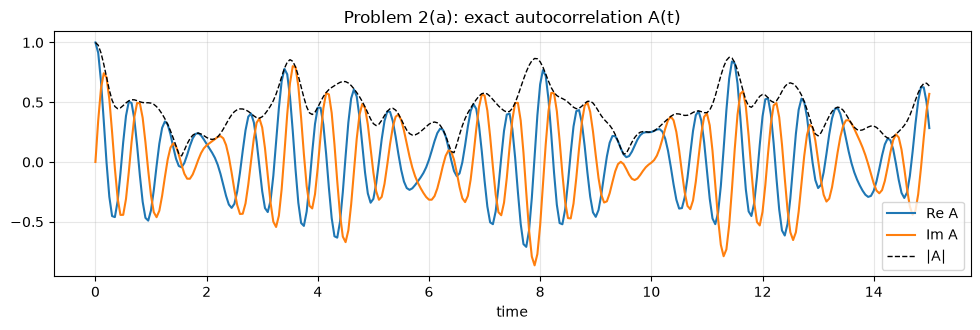

A(0) = 1.0 | max|A| = 1.0


In [67]:
A_exact = np.array([psi0.data.conj() @ exact_state(t).data for t in TIMES])
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(TIMES, A_exact.real, label="Re A"); ax.plot(TIMES, A_exact.imag, label="Im A")
ax.plot(TIMES, np.abs(A_exact), "k--", lw=1, label="|A|")
ax.set_xlabel("time"); ax.set_title("Problem 2(a): exact autocorrelation A(t)"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("A(0) =", round(A_exact[0].real, 6), "| max|A| =", round(np.max(np.abs(A_exact)), 4))

<!-- INTERPRETATION_KO:autocorr_exact -->
<div style="border-left:4px solid #6c8f3f; padding:0.65rem 0 0.65rem 1rem; margin:0.75rem 0; background:#f9fff4;">
<strong>해석.</strong>
exact autocorrelation $A(t)=\langle\psi_0|e^{-iHt}|\psi_0\rangle$은 초기상태가 시간 후 자기 자신과 얼마나 겹치는지를 보는 동역학 fingerprint이다. $A(0)=1$이고 $|A(t)|\le1$이어야 하므로, 이 plot은 exact diagonalization과 normalization을 검증하는 역할도 한다. Re/Im의 진동은 여러 eigenenergy phase $e^{-iE_nt}$가 합쳐진 결과이고, $|A(t)|$가 작아지는 구간은 초기상태 성분들이 서로 dephase된 구간으로 해석할 수 있다.
</div>


## Problem 2(b-c): Trotterized autocorrelation
$A_{PF}=\langle\psi_0|U_{PF}|\psi_0\rangle$. statevector overlap을 1차로 쓰고, Hadamard-test 회로로 교차검증.

Hadamard-test (controlled-U_PF) vs direct <psi0|U_PF|psi0>  [ST2_k3]:
    t    Re(direct)    Im(direct)      Re(HT)      Im(HT)      |err|
  0.0      1.000000      0.000000    1.000000   -0.000000    6.7e-15
  0.5      0.126247     -0.453657    0.126247   -0.453657    1.7e-15
  1.0     -0.457897     -0.051450   -0.457897   -0.051450    5.1e-15
  2.0     -0.281060     -0.170828   -0.281060   -0.170828    2.5e-15


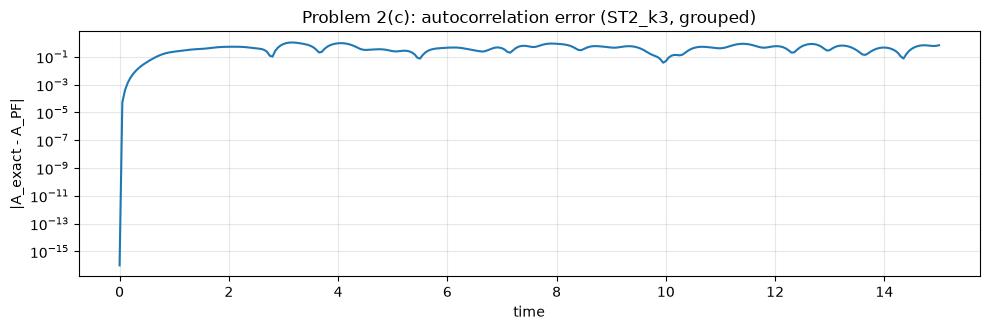

In [68]:
A_SYN = SETTINGS["ST2_k3"]          # N=6 accuracy/depth balance; matches teammate's chosen model
A_SYN_NAME = "ST2_k3"

def A_pf_overlap(t):
    return complex(psi0.data.conj() @ product_formula_state(t, A_SYN, ordering="grouped").data)

def A_pf_hadamard(t, part="real"):
    # Genuine Hadamard-test circuit: ancilla controls the product-formula gate (guide 2(b)).
    cU = PauliEvolutionGate(get_H(N, "grouped"), time=float(t), synthesis=A_SYN).control(1)
    qc = QuantumCircuit(N + 1)               # qubits 0..N-1 = system, qubit N = ancilla
    state_prep(qc); qc.h(N)
    if part == "imag": qc.sdg(N)
    qc.append(cU, [N] + list(range(N))); qc.h(N)
    p = Statevector.from_instruction(qc.decompose(reps=4)).probabilities([N])
    return p[0] - p[1]

# Verification: Hadamard-test circuit vs direct overlap (printed table)
print("Hadamard-test (controlled-U_PF) vs direct <psi0|U_PF|psi0>  [%s]:" % A_SYN_NAME)
print("%5s  %12s  %12s  %10s  %10s  %9s" % ("t", "Re(direct)", "Im(direct)", "Re(HT)", "Im(HT)", "|err|"))
for tv in [0.0, 0.5, 1.0, 2.0]:
    d = A_pf_overlap(tv); h = A_pf_hadamard(tv, "real") + 1j * A_pf_hadamard(tv, "imag")
    print("%5.1f  %12.6f  %12.6f  %10.6f  %10.6f  %9.1e" % (tv, d.real, d.imag, h.real, h.imag, abs(d - h)))

A_pf = np.array([A_pf_overlap(t) for t in TIMES])   # full series via overlap (fast, equals HT)
eps_A = np.abs(A_exact - A_pf)
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.semilogy(TIMES, np.maximum(eps_A, 1e-16)); ax.set_xlabel("time"); ax.set_ylabel("|A_exact - A_PF|")
ax.set_title("Problem 2(c): autocorrelation error (%s, grouped)" % A_SYN_NAME); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

<!-- INTERPRETATION_KO:autocorr_pf -->
<div style="border-left:4px solid #9a6a3a; padding:0.65rem 0 0.65rem 1rem; margin:0.75rem 0; background:#fffaf5;">
<strong>해석.</strong>
Trotterized autocorrelation에서는 $A_{PF}(t)=\langle\psi_0|U_{PF}(t)|\psi_0\rangle$를 exact $A(t)$와 비교한다. direct statevector overlap과 Hadamard-test 회로가 같은 값을 주는지 확인하는 이유는, 실제 양자회로에서는 autocorrelation이 controlled-$U_{PF}$ 측정으로 구현되기 때문이다. error curve $|A_{exact}-A_{PF}|$는 단일 시점의 state infidelity와 달리 시간에 따른 phase 누적을 직접 보여준다. 따라서 Problem 1에서 고른 균형형 formula가 spectral/dynamical observable에서도 충분히 안정적인지 확인하는 보조 근거가 된다.
</div>


## Problem 2(d-e): Fourier spectrum
$A(t)$의 DFT peak는 초기상태와 overlap이 nonzero인 eigenenergy 위치에 나타난다. 분해능 $\Delta E=2\pi/T_{max}$.

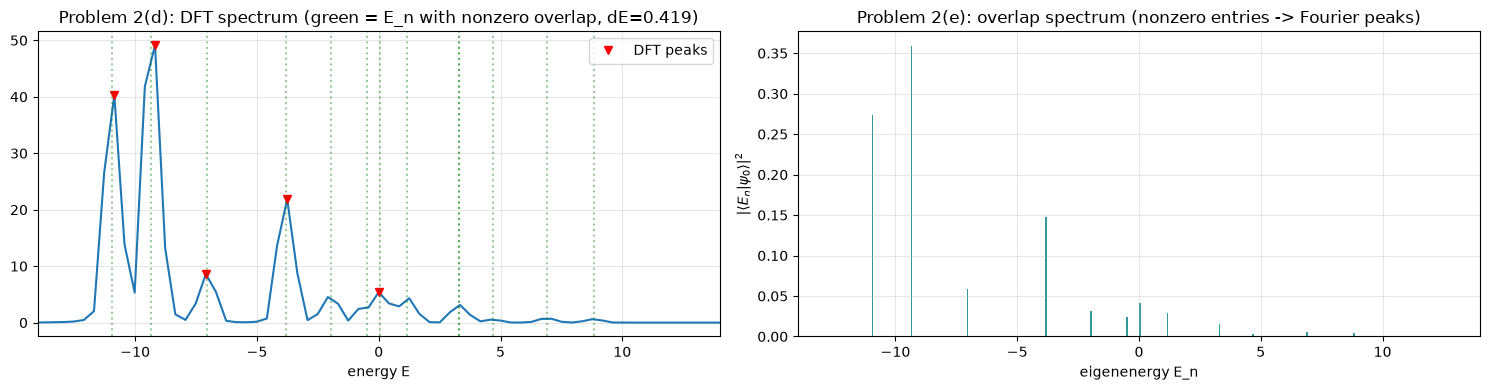

Dominant eigenenergies (|<E_n|psi0>|^2 > 1%):
       E_n    |<E_n|psi0>|^2  visible in DFT
   -9.3407            0.3591             YES
  -10.9374            0.2736             YES
   -3.8190            0.1477             YES
   -7.0314            0.0582             YES
    0.0332            0.0414             YES
   -1.9760            0.0317             YES
    1.1652            0.0295             YES
   -0.4966            0.0247             YES
    3.2976            0.0155             YES
    3.2991            0.0055             YES
    6.8991            0.0053             YES
    8.8341            0.0041             YES
    4.6726            0.0037             YES


,peak_energy,nearest_eigenvalue,overlap_weight,matched_2dE
0,-10.855,-10.937,0.274,True
1,-9.185,-9.341,0.359,True
2,-7.097,-7.031,0.058,True
3,-3.757,-3.819,0.148,True
4,-0.000,0.033,0.041,True


In [69]:
from scipy.signal import find_peaks
window = np.hanning(len(A_exact))
spectrum = fftshift(fft(A_exact * window))
energy   = -2*np.pi * fftshift(fftfreq(len(A_exact), d=DT_GRID))     # A(t)=sum |c_n|^2 e^{-i E_n t}
dE = 2*np.pi / T_MAX
order = np.argsort(energy); energy, mag = energy[order], np.abs(spectrum)[order]
pk, _ = find_peaks(mag, height=mag.max()*0.1)
top = pk[np.argsort(mag[pk])[::-1][:6]]; peakE = np.sort(energy[top])
w = np.abs(_c0)**2                        # |<E_n|psi0>|^2 overlap weights
peaks_tab = pd.DataFrame(dict(
    peak_energy=np.round(peakE, 3),
    nearest_eigenvalue=[round(float(eigvals[np.argmin(np.abs(eigvals-pe))]), 3) for pe in peakE],
    overlap_weight=[round(float(w[np.argmin(np.abs(eigvals-pe))]), 3) for pe in peakE]))
peaks_tab["matched_2dE"] = np.abs(peaks_tab.peak_energy - peaks_tab.nearest_eigenvalue) <= 2*dE

# Two panels: (left) DFT spectrum + eigenenergy markers; (right) overlap spectrum |<E_n|psi0>|^2
thr = 0.01 * w.max()
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 4))
axL.plot(energy, mag)
axL.plot(peakE, [mag[np.argmin(np.abs(energy-pe))] for pe in peakE], "rv", label="DFT peaks")
for e in eigvals[w > thr]:
    axL.axvline(e, color="g", ls=":", alpha=.4)
axL.set_xlabel("energy E"); axL.set_xlim(-14, 14)
axL.set_title("Problem 2(d): DFT spectrum (green = E_n with nonzero overlap, dE=%.3f)" % dE)
axL.legend(); axL.grid(alpha=.3)
axR.bar(eigvals, w, width=0.06, color="teal", alpha=0.8)
axR.set_xlabel("eigenenergy E_n"); axR.set_ylabel(r"$|\langle E_n|\psi_0\rangle|^2$"); axR.set_xlim(-14, 14)
axR.set_title("Problem 2(e): overlap spectrum (nonzero entries -> Fourier peaks)")
axR.grid(alpha=.3)
plt.tight_layout(); plt.show()

# Dominant eigenenergies and whether each is visible in the DFT (answers 2(e))
print("Dominant eigenenergies (|<E_n|psi0>|^2 > 1%):")
print("%10s  %16s  %14s" % ("E_n", "|<E_n|psi0>|^2", "visible in DFT"))
for ev, ov in sorted(zip(eigvals, w), key=lambda x: -x[1]):
    if ov > thr:
        print("%10.4f  %16.4f  %14s" % (ev, ov, "YES"))
peaks_tab

<!-- INTERPRETATION_KO:spectrum -->
<div style="border-left:4px solid #5661a6; padding:0.65rem 0 0.65rem 1rem; margin:0.75rem 0; background:#f7f8ff;">
<strong>해석.</strong>
DFT spectrum의 peak는 Hamiltonian의 모든 eigenvalue가 아니라, 초기상태와 overlap $|\langle E_n|\psi_0\rangle|^2$가 충분히 큰 eigenenergy에서 나타난다. 오른쪽 overlap spectrum은 왜 어떤 eigenenergy는 DFT에서 보이고 어떤 것은 보이지 않는지 설명하는 기준표이다. peak와 nearest eigenvalue가 $\Delta E=2\pi/T_{max}$ 수준 안에서 맞으면, 시간 신호가 에너지 정보를 제대로 복원했다고 볼 수 있다. Hanning window와 유한한 $T_{max}$ 때문에 peak는 완전한 delta가 아니라 폭을 가지며, 가까운 에너지들은 분해능 한계 안에서 합쳐져 보일 수 있다.
</div>


## Bonus Problem 3: simple circuit optimization + Rustiq comparison

This section merges the Rustiq analysis from `shinsolution (1).ipynb` into this notebook's Problem 3 answer.

- Representative circuit: `SuzukiTrotter(order=2, reps=3)` at `t=0.5`, using the same grouped Heisenberg Hamiltonian as Problem 1.
- Standard comparison: transpilation optimization levels `0,1,2,3`, reporting depth, total gate count, and two-qubit gate count.
- Rustiq comparison: if `synth_pauli_network_rustiq` is available, synthesize the same Pauli-network sequence and compare against the standard opt=3 circuit. If unavailable, the cell reports that explicitly, as requested by the bonus prompt.


In [ ]:
# ===== Bonus 3: standard transpilation opt-level sweep =====
from pathlib import Path
Path("tables").mkdir(exist_ok=True)

BONUS_TIME = 0.5
BONUS_SYNTH = SuzukiTrotter(order=2, reps=3)
BONUS_SETTING = "ST2_k3"
bonus_qc = evolution_circuit(BONUS_TIME, BONUS_SYNTH, ordering="grouped")

bonus_rows = []
for opt_level in [0, 1, 2, 3]:
    tqc = transpile(bonus_qc, basis_gates=BASIS_GATES, optimization_level=opt_level, seed_transpiler=42)
    res = resource_counts(tqc)
    bonus_rows.append(dict(
        setting=BONUS_SETTING,
        time=BONUS_TIME,
        optimization_level=opt_level,
        depth=res["depth"],
        total_gates=res["total_gates"],
        two_qubit_gates=res["two_qubit_gates"],
        cx_count=res["cx_count"],
        one_qubit_gates=res["one_qubit_gates"],
        two_qubit_depth=res["two_qubit_depth"],
    ))

bonus3_standard_opt_table = pd.DataFrame(bonus_rows)
display(bonus3_standard_opt_table)
bonus3_standard_opt_table.to_csv("tables/p3_bonus_standard_opt_levels.csv", index=False)


### Rustiq interpretation

Rustiq can help when a Pauli network has structure that standard transpilation does not expose. For this Heisenberg chain, the `grouped` ordering already places same-bond `XX`, `YY`, and `ZZ` rotations consecutively, so Qiskit's optimization can often realize the local KAK-style cancellation by itself. The useful question is therefore empirical: does Rustiq reduce the representative circuit's depth or two-qubit count relative to standard opt=3, in this environment?

The CSV artifacts are generated by the next two local cells (`tables/p3_bonus_standard_opt_levels.csv`, `tables/p3_bonus_rustiq_comparison.csv`). Run those local cells before final export if notebook-rendered outputs are required.


In [ ]:
# ===== Bonus 3: Rustiq availability and resource comparison =====
import importlib.util as _ilu
import qiskit as _qk
from qiskit.quantum_info import Operator

print("[Rustiq diagnostic] Qiskit", _qk.__version__)
_has_external_rustiq = _ilu.find_spec("qiskit_rustiq") is not None
try:
    from qiskit.synthesis.evolution import synth_pauli_network_rustiq
    _has_rustiq_fn = True
    _rustiq_import_error = None
except Exception as exc:
    synth_pauli_network_rustiq = None
    _has_rustiq_fn = False
    _rustiq_import_error = exc

print("  qiskit-rustiq external package:", "installed" if _has_external_rustiq else "not installed")
print("  synth_pauli_network_rustiq:", "available" if _has_rustiq_fn else "unavailable")

bonus3_rustiq_rows = []
std_opt3 = transpile(bonus_qc, basis_gates=BASIS_GATES, optimization_level=3, seed_transpiler=42)
std_res = resource_counts(std_opt3)
bonus3_rustiq_rows.append(dict(
    method="standard_ST2_k3_opt3", available=True,
    depth=std_res["depth"], total_gates=std_res["total_gates"], two_qubit_gates=std_res["two_qubit_gates"],
    cx_count=std_res["cx_count"], note="Qiskit standard transpilation, opt=3",
))

if not _has_rustiq_fn:
    bonus3_rustiq_rows.append(dict(
        method="rustiq_ST2_k3_opt3", available=False,
        depth=np.nan, total_gates=np.nan, two_qubit_gates=np.nan, cx_count=np.nan,
        note="Rustiq unavailable: %r" % (_rustiq_import_error,),
    ))
else:
    H_bonus = get_H(N, "grouped")
    # ProductFormula.expand returns the rotation angles expected by synth_pauli_network_rustiq.
    pf_sequence = BONUS_SYNTH.expand(PauliEvolutionGate(H_bonus, time=BONUS_TIME))
    pauli_network = [(op, list(indices), float(angle)) for (op, indices, angle) in pf_sequence]
    qc_rustiq = synth_pauli_network_rustiq(N, pauli_network, optimize_count=True)
    rustiq_opt3 = transpile(qc_rustiq, basis_gates=BASIS_GATES, optimization_level=3, seed_transpiler=42)
    rustiq_res = resource_counts(rustiq_opt3)
    try:
        unitary_match = bool(np.allclose(Operator(bonus_qc.decompose()).data, Operator(qc_rustiq).data, atol=1e-8))
    except Exception:
        unitary_match = np.nan
    bonus3_rustiq_rows.append(dict(
        method="rustiq_ST2_k3_opt3", available=True,
        depth=rustiq_res["depth"], total_gates=rustiq_res["total_gates"], two_qubit_gates=rustiq_res["two_qubit_gates"],
        cx_count=rustiq_res["cx_count"], unitary_match=unitary_match,
        note="synth_pauli_network_rustiq on the same ST2_k3 Pauli rotation sequence",
    ))

    # Single-bond sanity check from shinsolution: standard opt=3 already reaches 3 CX for XX+YY+ZZ.
    qc_bond = QuantumCircuit(2)
    qc_bond.rxx(2 * Jx * BONUS_TIME, 0, 1)
    qc_bond.ryy(2 * Jy * BONUS_TIME, 0, 1)
    qc_bond.rzz(2 * Jz * BONUS_TIME, 0, 1)
    bond_std = transpile(qc_bond, basis_gates=BASIS_GATES, optimization_level=3, seed_transpiler=42)
    bond_network = [("XX", [0, 1], 2 * Jx * BONUS_TIME), ("YY", [0, 1], 2 * Jy * BONUS_TIME), ("ZZ", [0, 1], 2 * Jz * BONUS_TIME)]
    bond_rustiq = transpile(synth_pauli_network_rustiq(2, bond_network, optimize_count=True),
                            basis_gates=BASIS_GATES, optimization_level=3, seed_transpiler=42)
    print("single-bond XX+YY+ZZ: standard CX=%d, Rustiq CX=%d" %
          (bond_std.count_ops().get("cx", 0), bond_rustiq.count_ops().get("cx", 0)))

bonus3_rustiq_comparison = pd.DataFrame(bonus3_rustiq_rows)
display(bonus3_rustiq_comparison)
bonus3_rustiq_comparison.to_csv("tables/p3_bonus_rustiq_comparison.csv", index=False)


## Sanity gate
모든 핵심 검증을 한 셀에서 재확인한다.

In [70]:
checks = []
def chk(name, cond): checks.append((name, "PASS" if bool(cond) else "FAIL"))
chk("S1 Hermitian, 24 terms, periodic, same-H", np.allclose(H_spo.to_matrix(), H_spo.to_matrix().conj().T)
    and len(H_spo) == 24 and same_H)
chk("S2 convention & exact(0)=psi0", BITSTRING_QISKIT == BITSTRING_Q0_FIRST[::-1]
    and np.allclose(exact_state(0).data, psi0.data))
chk("S3 exact norm=1 & <Z> in [-1,1]", abs(np.linalg.norm(exact_state(9.1).data)-1) < 1e-9
    and np.all(np.abs(exact_z1) <= 1+1e-9))
chk("S4 PF has cx>0", transpile_to_basis(evolution_circuit(0.5, SETTINGS["LT_k1"], include_stateprep=True).decompose()).count_ops().get("cx",0) > 0)
chk("S5 opt-invariance <=1e-9", max_dev <= 1e-9)
chk("S7 resource t-invariant", _res(_evo_only(N,"grouped",5.0),0) == _res(_evo_only(N,"grouped",0.5),0))
chk("S8 A(0)=1, |A|<=1, peaks matched", abs(A_exact[0]-1) < 1e-12 and np.max(np.abs(A_exact)) <= 1+1e-9
    and bool(peaks_tab.matched_2dE.all()))
chk("S9 1g budget pass, leakage~0, Z1/Z0Z1 sane", passes and leak < 1e-9
    and abs(z1_pf - z1_exact_1g) < 0.5 and abs(z0z1_pf - z0z1_exact_1g) < 0.5)
sanity = pd.DataFrame(checks, columns=["sanity check", "result"])
print("ALL PASS:", bool((sanity.result == "PASS").all()))
sanity

ALL PASS: True


,sanity check,result
0,"S1 Hermitian, 24 terms, periodic, same-H",PASS
1,S2 convention & exact(0)=psi0,PASS
2,"S3 exact norm=1 & <Z> in [-1,1]",PASS
3,S4 PF has cx>0,PASS
4,S5 opt-invariance <=1e-9,PASS
5,S7 resource t-invariant,PASS
6,"S8 A(0)=1, |A|<=1, peaks matched",PASS
7,"S9 1g budget pass, leakage~0, Z1/Z0Z1 sane",PASS
